# 02 — Recalibrate Simple Signal Grid  
## Locked 2621 bucketed Core / Secondary baseline

This notebook is the cleaned baseline for the SPX VRP simple signal grid.

### Current locked candidate

`locked_2621_win_band_25bps_conditional`

### What this notebook does

1. Loads the production feature panel.
2. Loads the completed naked ATM put outcome panel.
3. Builds the complete-date matrix representation.
4. Evaluates the locked bucketed **Core / Secondary 2621** candidate.
5. Uses the final blended tenor priority:
   - Core first.
   - Secondary only if no Core tenor qualifies.
   - Within the active layer, rank by layer-specific 2621-conditional win probability.
   - Treat tenors within 25 bps of the best conditional win probability as near-ties.
   - Use conditional average P&L/day as the tie-break inside that near-tie set.
6. Saves selected trades, summary tables, thresholds, tenor-priority metrics, and worst-trade audits.

### What was intentionally removed

The executable path no longer includes:

- broad grid sweeps
- pair 144 intermediate searches
- old P&L/day-only tenor priority logic
- conditional priority bakeoff code
- 2026 stress-diagnostic exploratory code
- line-fitting / smoothing experiments

Those steps were useful research, but this file is now meant to be a stable rerunnable baseline.


In [1]:
# Cell 1 — Setup, imports, paths, and project metadata

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
# This notebook is intended to run from either the project root or a
# notebooks/ subfolder. If neither location has a data/ directory, it falls
# back to the project path used during development.
# ---------------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
AUDIT_DIR = DATA_DIR / "audit"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PANEL_PATH = PROCESSED_DIR / "production_feature_panel_v0_1.parquet"
OUTCOME_PATH = PROCESSED_DIR / "naked_atm_put_eod_panel_v0_1.parquet"

# ---------------------------------------------------------------------
# Tenor universe and grouping
# ---------------------------------------------------------------------

PRODUCTION_TENORS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

GROUP_TENORS = {
    "front": [9, 12, 15],
    "middle": [18, 21, 24],
    "back": [27, 30, 33],
}

TENOR_GROUP_MAP = {
    tenor: group
    for group, tenors in GROUP_TENORS.items()
    for tenor in tenors
}

# ---------------------------------------------------------------------
# Locked model metadata
# ---------------------------------------------------------------------
# Current preferred research candidate:
#   locked_2621_win_band_25bps_conditional
#
# Important conventions:
#   - Thresholds are bucketed front / middle / back, not line-fitted.
#   - Core is checked before Secondary.
#   - Secondary is checked only when no Core tenor qualifies.
#   - Within the active layer, tenor priority is based on layer-specific
#     2621-conditional win probability.
#   - Tenors within 25 bps of the best conditional win probability are treated
#     as near-ties; conditional average P&L/day chooses among that near-tie set.
#   - Raw average P&L is not used for tenor priority.
# ---------------------------------------------------------------------

MODEL_LABEL = "locked_2621_win_band_25bps_conditional"
WIN_BAND = 0.0025

print("Current working directory:", cwd)
print("Project root:", PROJECT_ROOT)
print("Feature panel path:", FEATURE_PANEL_PATH)
print("Outcome path:", OUTCOME_PATH)
print("Feature panel exists:", FEATURE_PANEL_PATH.exists())
print("Outcome file exists:", OUTCOME_PATH.exists())
print("Model label:", MODEL_LABEL)
print("Win band:", WIN_BAND)


Current working directory: C:\Users\patri\vrp_project\notebooks v1
Project root: C:\Users\patri\vrp_project
Feature panel path: C:\Users\patri\vrp_project\data\processed\production_feature_panel_v0_1.parquet
Outcome path: C:\Users\patri\vrp_project\data\processed\naked_atm_put_eod_panel_v0_1.parquet
Feature panel exists: True
Outcome file exists: True
Model label: locked_2621_win_band_25bps_conditional
Win band: 0.0025


In [2]:
# Cell 2 — Small reusable data-cleaning helpers

def get_col(df: pd.DataFrame, candidates, required=True, label=None):
    """
    Return the first matching column from a candidate list.

    Matching is case-insensitive, but the original DataFrame column name is
    returned. This keeps the notebook robust to small naming changes in source
    files.
    """
    lower_map = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c in df.columns:
            return c

        c_lower = str(c).lower()
        if c_lower in lower_map:
            return lower_map[c_lower]

    if required:
        raise KeyError(
            f"Missing column for {label or candidates}. "
            f"Tried: {candidates}. Available columns: {list(df.columns)}"
        )

    return None


def parse_project_date_series(s: pd.Series) -> pd.Series:
    """
    Parse project date columns safely.

    Important:
      Numeric yyyymmdd values such as 20190805 must be parsed as calendar
      dates, not as nanoseconds since 1970.
    """
    s = s.copy()

    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s)

    s_str = s.astype("string").str.strip()
    s_str = s_str.str.replace(r"\.0$", "", regex=True)

    parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    is_yyyymmdd = s_str.str.fullmatch(r"\d{8}", na=False)

    if is_yyyymmdd.any():
        parsed.loc[is_yyyymmdd] = pd.to_datetime(
            s_str.loc[is_yyyymmdd],
            format="%Y%m%d",
            errors="coerce",
        )

    remaining = ~is_yyyymmdd

    if remaining.any():
        parsed.loc[remaining] = pd.to_datetime(
            s_str.loc[remaining],
            errors="coerce",
        )

    return parsed


def clean_binary_series(s: pd.Series) -> pd.Series:
    """
    Convert bool / numeric / string binary values into float 0/1.
    Missing or unresolved values stay NaN.
    """
    if pd.api.types.is_bool_dtype(s):
        return s.astype(float)

    numeric = pd.to_numeric(s, errors="coerce")

    if numeric.notna().mean() > 0.95:
        return numeric.astype(float)

    return (
        s.astype("string")
        .str.lower()
        .str.strip()
        .map({
            "true": 1.0,
            "false": 0.0,
            "yes": 1.0,
            "no": 0.0,
            "1": 1.0,
            "0": 0.0,
            "1.0": 1.0,
            "0.0": 0.0,
        })
    )


def require_columns(df: pd.DataFrame, required_cols, label="DataFrame"):
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"{label} is missing required columns: {missing_cols}")

In [3]:
# Cell 3 — Load and validate the production feature panel

if not FEATURE_PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing feature panel: {FEATURE_PANEL_PATH}")

features = pd.read_parquet(FEATURE_PANEL_PATH)
features["date"] = pd.to_datetime(features["date"]).dt.normalize()
features = features.sort_values(["date", "tenor"]).reset_index(drop=True)

required_feature_cols = [
    "date",
    "tenor",
    "tenor_group",
    "spx_close",
    "implied_variance",
    "forecast_variance",
    "vrp_log",
    "vrp_z_3m",
    "vrp_z_1y",
    "rv21d",
    "rsi14",
]

require_columns(features, required_feature_cols, label="Feature panel")

features = features[features["tenor"].isin(PRODUCTION_TENORS)].copy()
features["tenor"] = features["tenor"].astype(int)

eligible = features.dropna(
    subset=[
        "vrp_log",
        "vrp_z_3m",
        "vrp_z_1y",
        "rv21d",
        "rsi14",
        "implied_variance",
        "forecast_variance",
    ]
).copy()

eligible = eligible.sort_values(["date", "tenor"]).reset_index(drop=True)

dupes = eligible.duplicated(subset=["date", "tenor"]).sum()

print("Loaded feature panel")
print("  Shape:", features.shape)
print("  Date range:", features["date"].min(), "to", features["date"].max())
print("  Tenors:", sorted(features["tenor"].dropna().unique().tolist()))

print("\nEligible feature panel")
print("  Shape:", eligible.shape)
print("  Date range:", eligible["date"].min(), "to", eligible["date"].max())
print("  Tenors:", sorted(eligible["tenor"].dropna().unique().tolist()))
print("  Duplicate date/tenor rows:", dupes)

if dupes > 0:
    display(
        eligible[
            eligible.duplicated(subset=["date", "tenor"], keep=False)
        ].sort_values(["date", "tenor"]).head(30)
    )
    raise ValueError("Duplicate date/tenor rows found in eligible feature panel.")

# rv21d and rsi14 are market-level filters, so they should be identical
# across all tenors on a given date.
market_filter_counts = (
    eligible
    .groupby("date")[["rv21d", "rsi14"]]
    .nunique(dropna=False)
)

bad_market_filter_dates = market_filter_counts[
    (market_filter_counts["rv21d"] > 1) |
    (market_filter_counts["rsi14"] > 1)
]

print("  Dates with inconsistent rv21d/rsi14 across tenors:", len(bad_market_filter_dates))

if len(bad_market_filter_dates) > 0:
    display(bad_market_filter_dates.head(20))
    raise ValueError("rv21d or rsi14 differs across tenors on the same date.")

display(eligible.head(10))

Loaded feature panel
  Shape: (18099, 11)
  Date range: 2018-06-25 00:00:00 to 2026-06-25 00:00:00
  Tenors: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Eligible feature panel
  Shape: (15750, 11)
  Date range: 2019-07-10 00:00:00 to 2026-06-25 00:00:00
  Tenors: [9, 12, 15, 18, 21, 24, 27, 30, 33]
  Duplicate date/tenor rows: 0
  Dates with inconsistent rv21d/rsi14 across tenors: 0


,date,tenor,tenor_group,spx_close,implied_variance,forecast_variance,vrp_log,vrp_z_3m,vrp_z_1y,rv21d,rsi14
0,2019-07-10,9,front,"2,993.070000",0.010209,0.010971,-0.071968,-1.465831,-0.563268,7.712163,67.404430
1,2019-07-10,12,front,"2,993.070000",0.011378,0.009403,0.190606,-1.095112,-0.216897,7.712163,67.404430
2,2019-07-10,15,front,"2,993.070000",0.012079,0.010344,0.155121,-1.128973,-0.216182,7.712163,67.404430
3,2019-07-10,18,middle,"2,993.070000",0.013868,0.009403,0.388501,-0.584906,0.141210,7.712163,67.404430
4,2019-07-10,21,middle,"2,993.070000",0.015711,0.010075,0.444317,-0.401009,0.274458,7.712163,67.404430
5,2019-07-10,24,middle,"2,993.070000",0.016752,0.009991,0.516811,-0.241134,0.377281,7.712163,67.404430
6,2019-07-10,27,back,"2,993.070000",0.016953,0.009926,0.535301,-0.246532,0.381816,7.712163,67.404430
7,2019-07-10,30,back,"2,993.070000",0.017114,0.010344,0.503503,-0.342138,0.323409,7.712163,67.404430
8,2019-07-10,33,back,"2,993.070000",0.017323,0.009831,0.566508,-0.216783,0.392516,7.712163,67.404430
9,2019-07-11,9,front,"2,999.910000",0.010349,0.008859,0.155524,-0.889726,-0.180556,7.676858,68.576313


In [4]:
# Cell 4 — Load naked ATM put outcomes and build the completed research panel

if not OUTCOME_PATH.exists():
    raise FileNotFoundError(f"Missing outcome file: {OUTCOME_PATH}")

outcomes_raw = pd.read_parquet(OUTCOME_PATH)

# ---------------------------------------------------------------------
# Column mapping
# ---------------------------------------------------------------------

date_col = get_col(
    outcomes_raw,
    ["trade_dt", "trade_date", "date", "timestamp", "datetime"],
    label="date",
)

tenor_col = get_col(
    outcomes_raw,
    ["entry_tenor", "tenor", "target_tenor", "actual_dte", "dte"],
    label="tenor",
)

win_col = get_col(
    outcomes_raw,
    ["win_clean", "win", "test_win"],
    label="win",
)

expired_otm_col = get_col(
    outcomes_raw,
    ["expired_otm_clean", "expired_otm"],
    required=False,
    label="expired_otm",
)

pnl_dollars_col = get_col(
    outcomes_raw,
    ["normalized_pnl_dollars", "test_pnl", "sized_pnl"],
    required=False,
    label="normalized_pnl_dollars",
)

pnl_pct_col = get_col(
    outcomes_raw,
    ["normalized_pnl_pct"],
    required=False,
    label="normalized_pnl_pct",
)

actual_dte_col = get_col(
    outcomes_raw,
    ["actual_dte"],
    required=False,
    label="actual_dte",
)

expiry_spx_col = get_col(
    outcomes_raw,
    ["expiry_spx_close"],
    required=False,
    label="expiry_spx_close",
)

entry_credit_col = get_col(
    outcomes_raw,
    ["entry_credit_points", "atm_put_mid"],
    required=False,
    label="entry_credit_points",
)

short_pnl_points_col = get_col(
    outcomes_raw,
    ["short_option_pnl_points"],
    required=False,
    label="short_option_pnl_points",
)

print("Outcome column mapping:")
print({
    "date_col": date_col,
    "tenor_col": tenor_col,
    "win_col": win_col,
    "expired_otm_col": expired_otm_col,
    "pnl_dollars_col": pnl_dollars_col,
    "pnl_pct_col": pnl_pct_col,
    "actual_dte_col": actual_dte_col,
    "expiry_spx_col": expiry_spx_col,
    "entry_credit_col": entry_credit_col,
    "short_pnl_points_col": short_pnl_points_col,
})

# ---------------------------------------------------------------------
# Standardize outcomes
# ---------------------------------------------------------------------

outcomes = pd.DataFrame({
    "date": parse_project_date_series(outcomes_raw[date_col]).dt.normalize(),
    "tenor": pd.to_numeric(outcomes_raw[tenor_col], errors="coerce").astype("Int64"),
    "win_clean": clean_binary_series(outcomes_raw[win_col]),
})

if expired_otm_col is not None:
    outcomes["expired_otm_clean"] = clean_binary_series(outcomes_raw[expired_otm_col])
else:
    outcomes["expired_otm_clean"] = np.nan

if pnl_dollars_col is not None:
    outcomes["normalized_pnl_dollars"] = pd.to_numeric(outcomes_raw[pnl_dollars_col], errors="coerce")
else:
    outcomes["normalized_pnl_dollars"] = np.nan

if pnl_pct_col is not None:
    outcomes["normalized_pnl_pct"] = pd.to_numeric(outcomes_raw[pnl_pct_col], errors="coerce")
else:
    outcomes["normalized_pnl_pct"] = np.nan

if actual_dte_col is not None:
    outcomes["actual_dte"] = pd.to_numeric(outcomes_raw[actual_dte_col], errors="coerce")
else:
    outcomes["actual_dte"] = np.nan

if expiry_spx_col is not None:
    outcomes["expiry_spx_close"] = pd.to_numeric(outcomes_raw[expiry_spx_col], errors="coerce")
else:
    outcomes["expiry_spx_close"] = np.nan

if entry_credit_col is not None:
    outcomes["entry_credit_points"] = pd.to_numeric(outcomes_raw[entry_credit_col], errors="coerce")
else:
    outcomes["entry_credit_points"] = np.nan

if short_pnl_points_col is not None:
    outcomes["short_option_pnl_points"] = pd.to_numeric(outcomes_raw[short_pnl_points_col], errors="coerce")
else:
    outcomes["short_option_pnl_points"] = np.nan

outcomes = outcomes[outcomes["tenor"].isin(PRODUCTION_TENORS)].copy()
outcomes = outcomes.dropna(subset=["date", "tenor"]).copy()
outcomes["tenor"] = outcomes["tenor"].astype(int)

dupes = outcomes.duplicated(subset=["date", "tenor"]).sum()

print("\nStandardized outcome panel")
print("  Shape:", outcomes.shape)
print("  Date range:", outcomes["date"].min(), "to", outcomes["date"].max())
print("  Tenors:", sorted(outcomes["tenor"].dropna().unique().tolist()))
print("  Duplicate date/tenor rows:", dupes)

if dupes > 0:
    display(
        outcomes[
            outcomes.duplicated(subset=["date", "tenor"], keep=False)
        ].sort_values(["date", "tenor"]).head(30)
    )
    raise ValueError("Outcome panel has duplicate date/tenor rows.")

# ---------------------------------------------------------------------
# Join outcomes to eligible features.
# ---------------------------------------------------------------------
#
# Missing outcomes near the right edge are expected because later-dated
# longer-tenor trades may not have expired yet. Those rows are dropped.
#
# Missing outcomes before the last completed outcome date for that tenor are
# treated as a data hole and raise an error.
# ---------------------------------------------------------------------

research_panel_raw = eligible.merge(
    outcomes,
    on=["date", "tenor"],
    how="left",
)

completed_outcomes = outcomes.dropna(subset=["win_clean"]).copy()

last_completed_date_by_tenor = (
    completed_outcomes
    .groupby("tenor")["date"]
    .max()
    .rename("last_completed_outcome_date")
    .reset_index()
)

missing_outcomes = (
    research_panel_raw[research_panel_raw["win_clean"].isna()]
    [["date", "tenor", "tenor_group", "spx_close", "vrp_log", "vrp_z_3m", "vrp_z_1y", "rv21d", "rsi14"]]
    .copy()
)

missing_outcomes = missing_outcomes.merge(
    last_completed_date_by_tenor,
    on="tenor",
    how="left",
)

unexpected_missing = missing_outcomes[
    missing_outcomes["date"] <= missing_outcomes["last_completed_outcome_date"]
].copy()

print("\nResearch panel after outcome join")
print("  Shape:", research_panel_raw.shape)
print("  Rows with missing win_clean:", int(research_panel_raw["win_clean"].isna().sum()))

print("\nLast completed outcome date by tenor:")
display(last_completed_date_by_tenor)

if len(missing_outcomes) > 0:
    missing_summary = (
        missing_outcomes
        .groupby("tenor")
        .agg(
            missing_rows=("date", "size"),
            first_missing_date=("date", "min"),
            last_missing_date=("date", "max"),
            last_completed_outcome_date=("last_completed_outcome_date", "max"),
        )
        .reset_index()
    )

    print("\nMissing outcome summary by tenor:")
    display(missing_summary)

if len(unexpected_missing) > 0:
    print("\nUnexpected missing outcomes found before/equal to last completed date for that tenor:")
    display(unexpected_missing.head(30))
    raise ValueError("Unexpected non-right-edge missing outcomes found.")

print("\nRight-edge censored rows to drop:", len(missing_outcomes))

research_panel = research_panel_raw.dropna(subset=["win_clean"]).copy()
research_panel = research_panel.sort_values(["date", "tenor"]).reset_index(drop=True)

required_outcome_cols = ["win_clean", "normalized_pnl_dollars", "actual_dte"]
require_columns(research_panel, required_outcome_cols, label="Completed research panel")

if research_panel[required_outcome_cols].isna().any().any():
    display(research_panel[research_panel[required_outcome_cols].isna().any(axis=1)].head(20))
    raise ValueError("Completed research panel has missing win/P&L/actual_dte values.")

print("\nFinal completed research panel")
print("  Shape:", research_panel.shape)
print("  Date range:", research_panel["date"].min(), "to", research_panel["date"].max())
print("  Tenors:", sorted(research_panel["tenor"].dropna().unique().tolist()))
print("  Overall win rate:", research_panel["win_clean"].mean())

outcome_by_tenor = (
    research_panel
    .groupby("tenor")
    .agg(
        rows=("win_clean", "size"),
        win_rate=("win_clean", "mean"),
        avg_pnl_dollars=("normalized_pnl_dollars", "mean"),
        avg_pnl_pct=("normalized_pnl_pct", "mean"),
        avg_actual_dte=("actual_dte", "mean"),
    )
    .reset_index()
)

print("\nOutcome summary by tenor:")
display(outcome_by_tenor)

Outcome column mapping:
{'date_col': 'trade_dt', 'tenor_col': 'entry_tenor', 'win_col': 'win', 'expired_otm_col': 'expired_otm', 'pnl_dollars_col': 'normalized_pnl_dollars', 'pnl_pct_col': None, 'actual_dte_col': 'actual_dte', 'expiry_spx_col': 'expiry_spx_close', 'entry_credit_col': 'entry_credit_points', 'short_pnl_points_col': 'short_option_pnl_points'}

Standardized outcome panel
  Shape: (18099, 10)
  Date range: 2018-06-25 00:00:00 to 2026-06-25 00:00:00
  Tenors: [9, 12, 15, 18, 21, 24, 27, 30, 33]
  Duplicate date/tenor rows: 0

Research panel after outcome join
  Shape: (15750, 19)
  Rows with missing win_clean: 153

Last completed outcome date by tenor:


,tenor,last_completed_outcome_date
0,9,2026-06-12
1,12,2026-06-09
2,15,2026-06-05
3,18,2026-06-03
4,21,2026-05-29
5,24,2026-05-28
6,27,2026-05-22
7,30,2026-05-22
8,33,2026-05-19



Missing outcome summary by tenor:


,tenor,missing_rows,first_missing_date,last_missing_date,last_completed_outcome_date
0,9,8,2026-06-15,2026-06-25,2026-06-12
1,12,11,2026-06-10,2026-06-25,2026-06-09
2,15,13,2026-06-08,2026-06-25,2026-06-05
3,18,15,2026-06-04,2026-06-25,2026-06-03
4,21,18,2026-06-01,2026-06-25,2026-05-29
5,24,19,2026-05-29,2026-06-25,2026-05-28
6,27,22,2026-05-26,2026-06-25,2026-05-22
7,30,22,2026-05-26,2026-06-25,2026-05-22
8,33,25,2026-05-20,2026-06-25,2026-05-19



Right-edge censored rows to drop: 153

Final completed research panel
  Shape: (15597, 19)
  Date range: 2019-07-10 00:00:00 to 2026-06-12 00:00:00
  Tenors: [9, 12, 15, 18, 21, 24, 27, 30, 33]
  Overall win rate: 0.7633519266525614

Outcome summary by tenor:


,tenor,rows,win_rate,avg_pnl_dollars,avg_pnl_pct,avg_actual_dte
0,9,1742,0.731343,"1,123.741635",NaN,8.940299
1,12,1739,0.742381,"1,816.837565",NaN,11.848189
2,15,1737,0.748417,"2,462.510510",NaN,15.940127
3,18,1735,0.753890,"2,648.826727",NaN,17.438040
4,21,1732,0.760393,"3,264.124558",NaN,21.727483
5,24,1731,0.767187,"3,535.662513",NaN,23.038128
6,27,1728,0.785301,"4,430.317093",NaN,27.284722
7,30,1728,0.788773,"4,900.713063",NaN,29.941551
8,33,1725,0.793043,"5,573.755492",NaN,32.848116


In [5]:
# Cell 5 — Build complete-date sweep panel and matrix representation

# ---------------------------------------------------------------------
# Outcome normalization
# ---------------------------------------------------------------------
# The selected-tenor rule uses conditional P&L/day as a tie-breaker. This is
# not the same as using raw average P&L, which mechanically favors longer DTE.
# ---------------------------------------------------------------------

research_panel = research_panel.copy()

with np.errstate(divide="ignore", invalid="ignore"):
    research_panel["outcome_pnl_per_day"] = (
        research_panel["normalized_pnl_dollars"] / research_panel["actual_dte"]
    )

research_panel.loc[
    ~np.isfinite(research_panel["outcome_pnl_per_day"]),
    "outcome_pnl_per_day",
] = np.nan

# ---------------------------------------------------------------------
# Sweep panel cleaning
# ---------------------------------------------------------------------
# Keep only the columns needed for the locked signal evaluation and future
# overlay/sizing work.
# ---------------------------------------------------------------------

sweep_panel = research_panel[
    [
        "date",
        "tenor",
        "tenor_group",
        "spx_close",
        "vrp_log",
        "vrp_z_3m",
        "vrp_z_1y",
        "rv21d",
        "rsi14",
        "win_clean",
        "normalized_pnl_dollars",
        "actual_dte",
        "outcome_pnl_per_day",
    ]
].copy()

numeric_cols = [
    "tenor",
    "spx_close",
    "vrp_log",
    "vrp_z_3m",
    "vrp_z_1y",
    "rv21d",
    "rsi14",
    "win_clean",
    "normalized_pnl_dollars",
    "actual_dte",
    "outcome_pnl_per_day",
]

for col in numeric_cols:
    sweep_panel[col] = pd.to_numeric(sweep_panel[col], errors="coerce")

before_drop = len(sweep_panel)

sweep_panel = sweep_panel.dropna(
    subset=[
        "date",
        "tenor",
        "tenor_group",
        "spx_close",
        "vrp_log",
        "vrp_z_3m",
        "vrp_z_1y",
        "rv21d",
        "rsi14",
        "win_clean",
        "normalized_pnl_dollars",
        "actual_dte",
        "outcome_pnl_per_day",
    ]
).copy()

after_drop = len(sweep_panel)

print("\nSweep panel row cleaning")
print("  Rows before drop:", before_drop)
print("  Rows after drop: ", after_drop)
print("  Rows dropped:     ", before_drop - after_drop)

dupes = sweep_panel.duplicated(subset=["date", "tenor"]).sum()
print("  Duplicate date/tenor rows:", dupes)

if dupes > 0:
    display(
        sweep_panel[
            sweep_panel.duplicated(subset=["date", "tenor"], keep=False)
        ].sort_values(["date", "tenor"]).head(30)
    )
    raise ValueError("Duplicate date/tenor rows in sweep_panel.")

# ---------------------------------------------------------------------
# Complete-date filter
# ---------------------------------------------------------------------
# Keep only dates where all 9 tenors have completed outcomes. This keeps trade
# frequency comparisons clean and prevents right-edge censoring from biasing
# tenor selection.
# ---------------------------------------------------------------------

REQUIRED_TENOR_COUNT = len(PRODUCTION_TENORS)

tenor_count_by_date = (
    sweep_panel
    .groupby("date")["tenor"]
    .nunique()
    .rename("tenor_count")
)

complete_dates = tenor_count_by_date[tenor_count_by_date == REQUIRED_TENOR_COUNT].index
incomplete_dates = tenor_count_by_date[tenor_count_by_date != REQUIRED_TENOR_COUNT]

print("\nComplete-date filter")
print("  Original sweep rows:", len(sweep_panel))
print("  Original sweep dates:", sweep_panel["date"].nunique())
print("  Complete dates:", len(complete_dates))
print("  Incomplete dates:", len(incomplete_dates))

if len(incomplete_dates) > 0:
    print("\nIncomplete date summary:")
    display(
        incomplete_dates
        .reset_index()
        .sort_values("date")
    )

sweep_panel = sweep_panel[sweep_panel["date"].isin(complete_dates)].copy()
sweep_panel = sweep_panel.sort_values(["date", "tenor"]).reset_index(drop=True)

sweep_dates = pd.Index(sorted(sweep_panel["date"].unique()))
num_sweep_dates = len(sweep_dates)
TRADE_FREQUENCY_DENOMINATOR = num_sweep_dates

print("\nClean sweep panel")
print("  Rows:", len(sweep_panel))
print("  Dates:", num_sweep_dates)
print("  Date range:", sweep_dates.min(), "to", sweep_dates.max())
print("  Trade frequency denominator:", TRADE_FREQUENCY_DENOMINATOR)

clean_tenor_count_by_date = sweep_panel.groupby("date")["tenor"].nunique()

if not (clean_tenor_count_by_date == REQUIRED_TENOR_COUNT).all():
    raise ValueError("Some remaining dates do not have all 9 tenors.")

print("\nRows by tenor group after complete-date filter:")
display(
    sweep_panel
    .groupby("tenor_group")
    .agg(
        rows=("win_clean", "size"),
        win_rate=("win_clean", "mean"),
        avg_vrp=("vrp_log", "mean"),
        avg_z3m=("vrp_z_3m", "mean"),
        avg_z1y=("vrp_z_1y", "mean"),
        avg_rv21d=("rv21d", "mean"),
        avg_rsi14=("rsi14", "mean"),
        avg_pnl_per_day=("outcome_pnl_per_day", "mean"),
        total_pnl_dollars=("normalized_pnl_dollars", "sum"),
        total_actual_dte=("actual_dte", "sum"),
    )
    .assign(
        aggregate_pnl_per_day=lambda x: x["total_pnl_dollars"] / x["total_actual_dte"]
    )
    .reset_index()
)

# ---------------------------------------------------------------------
# Matrix representation
# ---------------------------------------------------------------------
# All strategy logic below uses matrix arrays:
#   rows = dates
#   columns = tenors [9, 12, ..., 33]
# ---------------------------------------------------------------------

TENOR_ARRAY = np.array(PRODUCTION_TENORS, dtype=int)
TENOR_ORDER = TENOR_ARRAY.tolist()
TENOR_TO_COL = {int(t): i for i, t in enumerate(TENOR_ARRAY)}

GROUP_COLS = {
    group: [TENOR_TO_COL[t] for t in tenors]
    for group, tenors in GROUP_TENORS.items()
}


def pivot_to_matrix(value_col):
    mat_df = (
        sweep_panel
        .pivot(index="date", columns="tenor", values=value_col)
        .reindex(index=sweep_dates, columns=PRODUCTION_TENORS)
    )

    if mat_df.isna().any().any():
        bad = mat_df[mat_df.isna().any(axis=1)].head(10)
        display(bad)
        raise ValueError(f"Matrix for {value_col} contains missing values.")

    return mat_df.to_numpy()


spx_mat = pivot_to_matrix("spx_close")
spx_close_mat = spx_mat
vrp_mat = pivot_to_matrix("vrp_log")
z3m_mat = pivot_to_matrix("vrp_z_3m")
z1y_mat = pivot_to_matrix("vrp_z_1y")
win_mat = pivot_to_matrix("win_clean")
pnl_mat = pivot_to_matrix("normalized_pnl_dollars")
actual_dte_mat = pivot_to_matrix("actual_dte")
pnl_per_day_mat = pivot_to_matrix("outcome_pnl_per_day")

rv21d_by_date = (
    sweep_panel.groupby("date")["rv21d"].first().reindex(sweep_dates).to_numpy()
)

rsi_by_date = (
    sweep_panel.groupby("date")["rsi14"].first().reindex(sweep_dates).to_numpy()
)

print("\nMatrix build complete")
print("  Matrix shape:", vrp_mat.shape)
print("  Tenor order:", TENOR_ORDER)



Sweep panel row cleaning
  Rows before drop: 15597
  Rows after drop:  15597
  Rows dropped:      0
  Duplicate date/tenor rows: 0

Complete-date filter
  Original sweep rows: 15597
  Original sweep dates: 1742
  Complete dates: 1725
  Incomplete dates: 17

Incomplete date summary:


,date,tenor_count
0,2026-05-20,8
1,2026-05-21,8
2,2026-05-22,8
3,2026-05-26,6
4,2026-05-27,6
5,2026-05-28,6
6,2026-05-29,5
7,2026-06-01,4
8,2026-06-02,4
9,2026-06-03,4



Clean sweep panel
  Rows: 15525
  Dates: 1725
  Date range: 2019-07-10 00:00:00 to 2026-05-19 00:00:00
  Trade frequency denominator: 1725

Rows by tenor group after complete-date filter:


,tenor_group,rows,win_rate,avg_vrp,avg_z3m,avg_z1y,avg_rv21d,avg_rsi14,avg_pnl_per_day,total_pnl_dollars,total_actual_dte,aggregate_pnl_per_day
0,back,5175,0.788792,0.508307,0.068748,0.076143,16.720316,55.807832,164.798276,"25,653,165.719078",155382,165.097410
1,front,5175,0.743188,0.667672,0.071348,0.087078,16.720316,55.807832,144.656581,"9,471,878.998276",63373,149.462374
2,middle,5175,0.760580,0.524071,0.068264,0.079054,16.720316,55.807832,150.822859,"16,247,873.322091",107302,151.421906



Matrix build complete
  Matrix shape: (1725, 9)
  Tenor order: [9, 12, 15, 18, 21, 24, 27, 30, 33]


## Locked model specification

### Threshold surface

The production research candidate uses **bucketed** front / middle / back thresholds. Do **not** line-fit or smooth these thresholds in this baseline notebook.

| Layer | Parameter | Front | Middle | Back |
|---|---|---:|---:|---:|
| Core | VRP | 0.60 | 0.65 | 0.70 |
| Core | z3m | 0.55 | 0.75 | 0.75 |
| Core | z1y | 0.65 | 0.65 | 0.75 |
| Core | RSI cap | 70 | 68 | 66 |
| Core | RV21D floor | 8.5 | 8.5 | 8.5 |
| Secondary | VRP | 0.60 | 0.60 | 0.70 |
| Secondary | z3m | 0.50 | 0.50 | 0.50 |
| Secondary | z1y | 0.40 | 0.50 | 0.50 |
| Secondary | RSI cap | 74 | 70 | 68 |
| Secondary | RV21D floor | 6.5 | 6.5 | 6.5 |

### Selection convention

1. Evaluate all Core tenors.
2. If any Core tenor qualifies, choose one Core tenor and ignore Secondary.
3. If no Core tenor qualifies, evaluate all Secondary tenors and choose one Secondary tenor if any qualify.
4. Maximum one selected trade per date.
5. Tenor priority is conditional on the locked 2621 qualifying universe, not unconditional tenor statistics.


In [7]:
# Cell — Final locked 2621 blended tenor-priority model
#
# Final model convention:
#   1. Thresholds are locked to 2621.
#   2. Core is checked first.
#   3. Secondary is checked only if no Core tenor qualifies.
#   4. Within the active layer:
#        a. Rank tenors by layer-specific 2621-conditional win probability.
#        b. Keep tenors within 25 bps of the best qualifying tenor's win probability.
#        c. Select the tenor with highest layer-specific 2621-conditional avg P&L/day.
#        d. Tie-break by aggregate P&L/day, then conditional win probability, then longer tenor.
#
# Why:
#   - Avoids raw P&L duration bias.
#   - Avoids unconditional tenor statistics.
#   - Avoids pure P&L/day selection taking over the model.
#   - Keeps win probability as the primary criterion.
#
# Expected tenor behavior from bakeoff:
#   - Same front/middle/back mix as win_only.
#   - Main change: inside the back bucket, 27D can beat 33D when their conditional
#     win probabilities are effectively tied and 27D has better P&L/day.

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Robust setup
# ---------------------------------------------------------------------

if "TENOR_ORDER" in globals():
    TENOR_ARRAY = np.array(TENOR_ORDER, dtype=int)

elif "sweep_panel" in globals() and "tenor" in sweep_panel.columns:
    TENOR_ARRAY = np.array(sorted(sweep_panel["tenor"].dropna().unique()), dtype=int)
    TENOR_ORDER = TENOR_ARRAY.tolist()

elif "research_panel" in globals() and "tenor" in research_panel.columns:
    TENOR_ARRAY = np.array(sorted(research_panel["tenor"].dropna().unique()), dtype=int)
    TENOR_ORDER = TENOR_ARRAY.tolist()

else:
    TENOR_ARRAY = np.array([9, 12, 15, 18, 21, 24, 27, 30, 33], dtype=int)
    TENOR_ORDER = TENOR_ARRAY.tolist()

TENOR_TO_COL = {int(t): i for i, t in enumerate(TENOR_ARRAY)}

required_objects = [
    "num_sweep_dates",
    "sweep_dates",
    "vrp_mat",
    "z3m_mat",
    "z1y_mat",
    "win_mat",
    "pnl_mat",
    "actual_dte_mat",
    "rv21d_by_date",
    "rsi_by_date",
    "TRADE_FREQUENCY_DENOMINATOR",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Run the data-loading / matrix-construction cells first. "
        f"Missing: {missing_objects}"
    )

if "pnl_per_day_mat" not in globals():
    with np.errstate(divide="ignore", invalid="ignore"):
        pnl_per_day_mat = pnl_mat / actual_dte_mat
    pnl_per_day_mat[~np.isfinite(pnl_per_day_mat)] = np.nan

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")
else:
    PROCESSED_DIR = Path(PROCESSED_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABEL = "locked_2621_win_band_25bps_conditional"
WIN_BAND = 0.0025

print("Final locked 2621 blended-priority model")
print("Model label:", MODEL_LABEL)
print("Tenors:", TENOR_ARRAY.tolist())
print("Win band:", WIN_BAND)


# ---------------------------------------------------------------------
# Locked 2621 thresholds
# ---------------------------------------------------------------------

LOCKED_2621_CORE = {
    "front": {
        "tenors": [9, 12, 15],
        "vrp": 0.60,
        "z3m": 0.55,
        "z1y": 0.65,
        "rsi_cap": 70,
        "rv21d_floor": 8.5,
    },
    "middle": {
        "tenors": [18, 21, 24],
        "vrp": 0.65,
        "z3m": 0.75,
        "z1y": 0.65,
        "rsi_cap": 68,
        "rv21d_floor": 8.5,
    },
    "back": {
        "tenors": [27, 30, 33],
        "vrp": 0.70,
        "z3m": 0.75,
        "z1y": 0.75,
        "rsi_cap": 66,
        "rv21d_floor": 8.5,
    },
}

LOCKED_2621_SECONDARY = {
    "front": {
        "tenors": [9, 12, 15],
        "vrp": 0.60,
        "z3m": 0.50,
        "z1y": 0.40,
        "rsi_cap": 74,
        "rv21d_floor": 6.5,
    },
    "middle": {
        "tenors": [18, 21, 24],
        "vrp": 0.60,
        "z3m": 0.50,
        "z1y": 0.50,
        "rsi_cap": 70,
        "rv21d_floor": 6.5,
    },
    "back": {
        "tenors": [27, 30, 33],
        "vrp": 0.70,
        "z3m": 0.50,
        "z1y": 0.50,
        "rsi_cap": 68,
        "rv21d_floor": 6.5,
    },
}


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def tenor_group_for_tenor(tenor):
    tenor = int(tenor)

    if tenor in [9, 12, 15]:
        return "front"
    elif tenor in [18, 21, 24]:
        return "middle"
    elif tenor in [27, 30, 33]:
        return "back"
    else:
        raise ValueError(f"Unexpected tenor: {tenor}")


def build_threshold_table(threshold_spec, layer):
    rows = []

    for group, params in threshold_spec.items():
        for tenor in params["tenors"]:
            rows.append({
                "layer": layer,
                "tenor_group": group,
                "selected_tenor": int(tenor),
                "vrp_threshold": float(params["vrp"]),
                "z3m_threshold": float(params["z3m"]),
                "z1y_threshold": float(params["z1y"]),
                "rsi_cap": float(params["rsi_cap"]),
                "rv21d_floor": float(params["rv21d_floor"]),
            })

    return pd.DataFrame(rows)


def build_qualifies_matrix(threshold_spec):
    """
    Builds date x tenor boolean qualification matrix for locked 2621 thresholds.
    """
    qualifies = np.zeros((num_sweep_dates, len(TENOR_ARRAY)), dtype=bool)

    for col, tenor in enumerate(TENOR_ARRAY):
        group = tenor_group_for_tenor(tenor)
        params = threshold_spec[group]

        qualifies[:, col] = (
            (vrp_mat[:, col] >= float(params["vrp"])) &
            (z3m_mat[:, col] >= float(params["z3m"])) &
            (z1y_mat[:, col] >= float(params["z1y"])) &
            (rsi_by_date <= float(params["rsi_cap"])) &
            (rv21d_by_date >= float(params["rv21d_floor"]))
        )

    return qualifies


def build_layer_conditional_tenor_metrics(layer_name, qualifies_matrix, date_mask):
    """
    Builds tenor ranking metrics conditional on the relevant 2621 candidate universe.

    Core:
      date_mask = all dates.

    Secondary:
      date_mask = dates where no Core tenor qualifies.
    """
    rows = []

    for col, tenor in enumerate(TENOR_ARRAY):
        candidate_mask = (
            date_mask &
            qualifies_matrix[:, col] &
            np.isfinite(win_mat[:, col]) &
            np.isfinite(pnl_mat[:, col]) &
            np.isfinite(actual_dte_mat[:, col]) &
            np.isfinite(pnl_per_day_mat[:, col])
        )

        candidate_count = int(candidate_mask.sum())

        if candidate_count == 0:
            rows.append({
                "layer": layer_name,
                "selected_col": int(col),
                "selected_tenor": int(tenor),
                "tenor_group": tenor_group_for_tenor(tenor),
                "conditional_win_probability": np.nan,
                "conditional_avg_pnl_per_day": np.nan,
                "conditional_median_pnl_per_day": np.nan,
                "conditional_aggregate_pnl_per_day": np.nan,
                "conditional_avg_raw_pnl": np.nan,
                "conditional_avg_actual_dte": np.nan,
                "conditional_worst_trade_pnl": np.nan,
                "conditional_worst_pnl_per_day": np.nan,
                "candidate_count": 0,
            })
            continue

        rows.append({
            "layer": layer_name,
            "selected_col": int(col),
            "selected_tenor": int(tenor),
            "tenor_group": tenor_group_for_tenor(tenor),

            "conditional_win_probability": float(np.nanmean(win_mat[candidate_mask, col])),
            "conditional_avg_pnl_per_day": float(np.nanmean(pnl_per_day_mat[candidate_mask, col])),
            "conditional_median_pnl_per_day": float(np.nanmedian(pnl_per_day_mat[candidate_mask, col])),
            "conditional_aggregate_pnl_per_day": float(
                np.nansum(pnl_mat[candidate_mask, col]) /
                np.nansum(actual_dte_mat[candidate_mask, col])
            ),
            "conditional_avg_raw_pnl": float(np.nanmean(pnl_mat[candidate_mask, col])),
            "conditional_avg_actual_dte": float(np.nanmean(actual_dte_mat[candidate_mask, col])),
            "conditional_worst_trade_pnl": float(np.nanmin(pnl_mat[candidate_mask, col])),
            "conditional_worst_pnl_per_day": float(np.nanmin(pnl_per_day_mat[candidate_mask, col])),
            "candidate_count": candidate_count,
        })

    return pd.DataFrame(rows)


def blended_priority_order(layer_name, qualifying_cols, win_band=WIN_BAND):
    """
    Final blended priority rule.

    Step 1:
      Find best conditional win probability among qualifying tenors.

    Step 2:
      Keep tenors within win_band of that best conditional win probability.

    Step 3:
      Select highest conditional avg P&L/day.
      Tie-break by aggregate P&L/day, then conditional win probability, then longer tenor.
    """
    if len(qualifying_cols) == 0:
        return pd.DataFrame()

    df = tenor_priority_metrics[
        (tenor_priority_metrics["layer"].eq(layer_name)) &
        (tenor_priority_metrics["selected_col"].isin(qualifying_cols)) &
        (tenor_priority_metrics["candidate_count"] > 0)
    ].copy()

    if df.empty:
        return df

    best_win = df["conditional_win_probability"].max()

    df["best_conditional_win_probability"] = best_win
    df["win_probability_gap_to_best"] = best_win - df["conditional_win_probability"]
    df["inside_win_band"] = df["win_probability_gap_to_best"] <= win_band

    df = df[df["inside_win_band"]].copy()

    df = df.sort_values(
        [
            "conditional_avg_pnl_per_day",
            "conditional_aggregate_pnl_per_day",
            "conditional_win_probability",
            "selected_tenor",
        ],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

    df["priority_rank_within_signal"] = np.arange(1, len(df) + 1)

    return df


def select_final_model_path():
    """
    Core-first / Secondary-second final path selection.
    """
    selected_rows = []

    core_selected = np.full(num_sweep_dates, -1, dtype=np.int8)
    secondary_selected = np.full(num_sweep_dates, -1, dtype=np.int8)
    combined_selected = np.full(num_sweep_dates, -1, dtype=np.int8)

    for row in range(num_sweep_dates):
        core_qualifying_cols = np.where(core_qualifies_matrix[row, :])[0].astype(int).tolist()

        if core_qualifying_cols:
            ordered = blended_priority_order(
                layer_name="Core",
                qualifying_cols=core_qualifying_cols,
                win_band=WIN_BAND,
            )

            if not ordered.empty:
                selected_col = int(ordered.iloc[0]["selected_col"])

                core_selected[row] = selected_col
                combined_selected[row] = selected_col

                selected_rows.append({
                    "row_idx": int(row),
                    "date": sweep_dates[row],
                    "layer": "Core",
                    "selected_col": selected_col,
                    "selected_tenor": int(TENOR_ARRAY[selected_col]),
                    "tenor_group": tenor_group_for_tenor(TENOR_ARRAY[selected_col]),
                    "num_qualifying_tenors_in_layer": int(len(core_qualifying_cols)),
                    "qualifying_tenors_in_layer": ",".join(
                        [str(int(TENOR_ARRAY[c])) for c in core_qualifying_cols]
                    ),
                    "selection_rule": "win_band_25bps_then_pnl_day",
                    "win_band": WIN_BAND,
                })

            continue

        secondary_qualifying_cols = np.where(secondary_qualifies_matrix[row, :])[0].astype(int).tolist()

        if secondary_qualifying_cols:
            ordered = blended_priority_order(
                layer_name="Secondary",
                qualifying_cols=secondary_qualifying_cols,
                win_band=WIN_BAND,
            )

            if not ordered.empty:
                selected_col = int(ordered.iloc[0]["selected_col"])

                secondary_selected[row] = selected_col
                combined_selected[row] = selected_col

                selected_rows.append({
                    "row_idx": int(row),
                    "date": sweep_dates[row],
                    "layer": "Secondary",
                    "selected_col": selected_col,
                    "selected_tenor": int(TENOR_ARRAY[selected_col]),
                    "tenor_group": tenor_group_for_tenor(TENOR_ARRAY[selected_col]),
                    "num_qualifying_tenors_in_layer": int(len(secondary_qualifying_cols)),
                    "qualifying_tenors_in_layer": ",".join(
                        [str(int(TENOR_ARRAY[c])) for c in secondary_qualifying_cols]
                    ),
                    "selection_rule": "win_band_25bps_then_pnl_day",
                    "win_band": WIN_BAND,
                })

    selected_path = pd.DataFrame(selected_rows)

    return selected_path, {
        "core_selected": core_selected,
        "secondary_selected": secondary_selected,
        "combined_selected": combined_selected,
    }


def attach_trade_outcomes(selected_path):
    """
    Adds outcomes, features, and conditional ranking metrics to selected path.
    """
    if selected_path.empty:
        return selected_path.copy()

    row_idx = selected_path["row_idx"].to_numpy(dtype=int)
    col_idx = selected_path["selected_col"].to_numpy(dtype=int)

    trades = selected_path.copy()

    trades["candidate"] = MODEL_LABEL

    trades["win"] = win_mat[row_idx, col_idx]
    trades["normalized_pnl_dollars"] = pnl_mat[row_idx, col_idx]
    trades["actual_dte"] = actual_dte_mat[row_idx, col_idx]
    trades["pnl_per_day"] = pnl_per_day_mat[row_idx, col_idx]

    trades["vrp_log"] = vrp_mat[row_idx, col_idx]
    trades["vrp_z_3m"] = z3m_mat[row_idx, col_idx]
    trades["vrp_z_1y"] = z1y_mat[row_idx, col_idx]
    trades["rv21d"] = rv21d_by_date[row_idx]
    trades["rsi14"] = rsi_by_date[row_idx]

    if "spx_close_mat" in globals():
        trades["spx_close"] = spx_close_mat[row_idx, col_idx]
    elif "spx_close_by_date" in globals():
        trades["spx_close"] = np.asarray(spx_close_by_date)[row_idx]
    else:
        trades["spx_close"] = np.nan

    trades = trades.merge(
        tenor_priority_metrics,
        on=["layer", "selected_col", "selected_tenor", "tenor_group"],
        how="left",
    )

    trades = trades.sort_values("date").reset_index(drop=True)

    trades["trade_sequence"] = np.arange(1, len(trades) + 1)
    trades["cum_pnl"] = trades["normalized_pnl_dollars"].cumsum()
    trades["running_max_cum_pnl"] = trades["cum_pnl"].cummax()
    trades["drawdown"] = trades["cum_pnl"] - trades["running_max_cum_pnl"]
    trades["rolling_20_trade_pnl"] = trades["normalized_pnl_dollars"].rolling(20).sum()

    trades["year"] = pd.to_datetime(trades["date"]).dt.year
    trades["month"] = pd.to_datetime(trades["date"]).dt.to_period("M").astype(str)

    return trades


def summarize_trade_df(df, label):
    """
    Summary for one path or subgroup.
    """
    trade_count = int(len(df))

    if trade_count == 0:
        return pd.Series({
            "label": label,
            "trade_count": 0,
            "trade_frequency": 0.0,
            "win_rate": np.nan,
            "avg_pnl_per_day": np.nan,
            "median_pnl_per_day": np.nan,
            "aggregate_pnl_per_day": np.nan,
            "total_pnl": 0.0,
            "total_actual_dte": 0.0,
            "worst_trade_pnl": np.nan,
            "worst_pnl_per_day": np.nan,
            "max_drawdown": np.nan,
            "worst_20_trade_sum": np.nan,
            "avg_selected_tenor": np.nan,
        })

    df = df.sort_values("date").copy()

    df["local_cum_pnl"] = df["normalized_pnl_dollars"].cumsum()
    df["local_running_max"] = df["local_cum_pnl"].cummax()
    df["local_drawdown"] = df["local_cum_pnl"] - df["local_running_max"]
    df["local_rolling_20_trade_pnl"] = df["normalized_pnl_dollars"].rolling(20).sum()

    total_pnl = float(df["normalized_pnl_dollars"].sum())
    total_actual_dte = float(df["actual_dte"].sum())

    return pd.Series({
        "label": label,
        "trade_count": trade_count,
        "trade_frequency": float(trade_count / TRADE_FREQUENCY_DENOMINATOR),
        "win_rate": float(df["win"].mean()),
        "avg_pnl_per_day": float(df["pnl_per_day"].mean()),
        "median_pnl_per_day": float(df["pnl_per_day"].median()),
        "aggregate_pnl_per_day": float(total_pnl / total_actual_dte) if total_actual_dte else np.nan,
        "total_pnl": total_pnl,
        "total_actual_dte": total_actual_dte,
        "worst_trade_pnl": float(df["normalized_pnl_dollars"].min()),
        "worst_pnl_per_day": float(df["pnl_per_day"].min()),
        "max_drawdown": float(df["local_drawdown"].min()),
        "worst_20_trade_sum": float(df["local_rolling_20_trade_pnl"].min()),
        "avg_selected_tenor": float(df["selected_tenor"].mean()),
    })


def summarize_by_group(df, group_cols):
    rows = []

    for keys, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {col: key for col, key in zip(group_cols, keys)}
        summary = summarize_trade_df(sub, label="group").to_dict()
        summary.pop("label", None)

        row.update(summary)
        rows.append(row)

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------
# Build qualification matrices and conditional tenor metrics
# ---------------------------------------------------------------------

core_qualifies_matrix = build_qualifies_matrix(LOCKED_2621_CORE)
secondary_qualifies_matrix = build_qualifies_matrix(LOCKED_2621_SECONDARY)

any_core_qualifies_by_date = core_qualifies_matrix.any(axis=1)
no_core_qualifies_by_date = ~any_core_qualifies_by_date

core_tenor_priority_metrics = build_layer_conditional_tenor_metrics(
    layer_name="Core",
    qualifies_matrix=core_qualifies_matrix,
    date_mask=np.ones(num_sweep_dates, dtype=bool),
)

secondary_tenor_priority_metrics = build_layer_conditional_tenor_metrics(
    layer_name="Secondary",
    qualifies_matrix=secondary_qualifies_matrix,
    date_mask=no_core_qualifies_by_date,
)

tenor_priority_metrics = pd.concat(
    [core_tenor_priority_metrics, secondary_tenor_priority_metrics],
    ignore_index=True,
)

locked_2621_threshold_table = pd.concat(
    [
        build_threshold_table(LOCKED_2621_CORE, "Core"),
        build_threshold_table(LOCKED_2621_SECONDARY, "Secondary"),
    ],
    ignore_index=True,
)

print("\nLocked 2621 qualification counts:")
print("Dates with at least one Core tenor:", int(any_core_qualifies_by_date.sum()))
print("Dates with no Core tenor:", int(no_core_qualifies_by_date.sum()))
print("Dates with at least one Secondary tenor:", int(secondary_qualifies_matrix.any(axis=1).sum()))
print(
    "Dates with at least one Secondary tenor and no Core tenor:",
    int((secondary_qualifies_matrix.any(axis=1) & no_core_qualifies_by_date).sum()),
)

print("\nCore 2621-conditional tenor priority metrics:")
display(
    core_tenor_priority_metrics.sort_values(
        ["conditional_win_probability", "conditional_avg_pnl_per_day"],
        ascending=[False, False],
    )
)

print("\nSecondary 2621-conditional tenor priority metrics:")
display(
    secondary_tenor_priority_metrics.sort_values(
        ["conditional_win_probability", "conditional_avg_pnl_per_day"],
        ascending=[False, False],
    )
)


# ---------------------------------------------------------------------
# Select final model path
# ---------------------------------------------------------------------

selected_path, selected_arrays = select_final_model_path()
locked_2621_selected_trades = attach_trade_outcomes(selected_path)

locked_2621_path_summary = pd.DataFrame(
    [summarize_trade_df(locked_2621_selected_trades, label="Combined")]
)

summary_by_layer = summarize_by_group(
    locked_2621_selected_trades,
    ["layer"],
)

summary_by_year_layer = summarize_by_group(
    locked_2621_selected_trades,
    ["year", "layer"],
)

summary_by_tenor_layer = summarize_by_group(
    locked_2621_selected_trades,
    ["selected_tenor", "layer"],
)

summary_by_group_layer = summarize_by_group(
    locked_2621_selected_trades,
    ["tenor_group", "layer"],
)

worst_trades = (
    locked_2621_selected_trades
    .sort_values("normalized_pnl_dollars", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

worst_20_trade_windows = (
    locked_2621_selected_trades
    .dropna(subset=["rolling_20_trade_pnl"])
    .sort_values("rolling_20_trade_pnl", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

print("\nFinal locked 2621 blended-priority path summary:")
display(locked_2621_path_summary)

print("\nSummary by layer:")
display(summary_by_layer)

print("\nSummary by year and layer:")
display(summary_by_year_layer)

print("\nSummary by tenor and layer:")
display(summary_by_tenor_layer)

print("\nSummary by tenor group and layer:")
display(summary_by_group_layer)

print("\nWorst 20 individual trades:")
display(worst_trades)

print("\nWorst 20-trade rolling windows:")
display(worst_20_trade_windows)


# ---------------------------------------------------------------------
# Save final model outputs
# ---------------------------------------------------------------------

SELECTED_TRADES_CSV_PATH = AUDIT_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.csv"
SELECTED_TRADES_PARQUET_PATH = PROCESSED_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.parquet"

SUMMARY_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_v0_1.csv"
SUMMARY_BY_LAYER_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_by_layer_v0_1.csv"
SUMMARY_BY_YEAR_LAYER_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_by_year_layer_v0_1.csv"
SUMMARY_BY_TENOR_LAYER_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_by_tenor_layer_v0_1.csv"
SUMMARY_BY_GROUP_LAYER_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_by_group_layer_v0_1.csv"

WORST_TRADES_PATH = AUDIT_DIR / f"{MODEL_LABEL}_worst_trades_v0_1.csv"
WORST_WINDOWS_PATH = AUDIT_DIR / f"{MODEL_LABEL}_worst_20_trade_windows_v0_1.csv"

TENOR_PRIORITY_METRICS_PATH = AUDIT_DIR / f"{MODEL_LABEL}_tenor_priority_metrics_v0_1.csv"
THRESHOLD_TABLE_PATH = AUDIT_DIR / f"{MODEL_LABEL}_thresholds_v0_1.csv"
SUMMARY_JSON_PATH = AUDIT_DIR / f"{MODEL_LABEL}_summary_v0_1.json"

locked_2621_selected_trades.to_csv(SELECTED_TRADES_CSV_PATH, index=False)
locked_2621_selected_trades.to_parquet(SELECTED_TRADES_PARQUET_PATH, index=False)

locked_2621_path_summary.to_csv(SUMMARY_PATH, index=False)
summary_by_layer.to_csv(SUMMARY_BY_LAYER_PATH, index=False)
summary_by_year_layer.to_csv(SUMMARY_BY_YEAR_LAYER_PATH, index=False)
summary_by_tenor_layer.to_csv(SUMMARY_BY_TENOR_LAYER_PATH, index=False)
summary_by_group_layer.to_csv(SUMMARY_BY_GROUP_LAYER_PATH, index=False)

worst_trades.to_csv(WORST_TRADES_PATH, index=False)
worst_20_trade_windows.to_csv(WORST_WINDOWS_PATH, index=False)

tenor_priority_metrics.to_csv(TENOR_PRIORITY_METRICS_PATH, index=False)
locked_2621_threshold_table.to_csv(THRESHOLD_TABLE_PATH, index=False)

summary_json = {
    "model_label": MODEL_LABEL,
    "thresholds": "locked_2621",
    "priority_rule": "layer-specific 2621-conditional win probability within 25 bps, then conditional avg P&L/day",
    "win_band": WIN_BAND,
    "trade_count": int(locked_2621_path_summary.iloc[0]["trade_count"]),
    "trade_frequency": float(locked_2621_path_summary.iloc[0]["trade_frequency"]),
    "win_rate": float(locked_2621_path_summary.iloc[0]["win_rate"]),
    "avg_pnl_per_day": float(locked_2621_path_summary.iloc[0]["avg_pnl_per_day"]),
    "aggregate_pnl_per_day": float(locked_2621_path_summary.iloc[0]["aggregate_pnl_per_day"]),
    "total_pnl": float(locked_2621_path_summary.iloc[0]["total_pnl"]),
    "max_drawdown": float(locked_2621_path_summary.iloc[0]["max_drawdown"]),
    "worst_20_trade_sum": float(locked_2621_path_summary.iloc[0]["worst_20_trade_sum"]),
    "avg_selected_tenor": float(locked_2621_path_summary.iloc[0]["avg_selected_tenor"]),
    "selected_trades_csv": str(SELECTED_TRADES_CSV_PATH),
    "selected_trades_parquet": str(SELECTED_TRADES_PARQUET_PATH),
}

with open(SUMMARY_JSON_PATH, "w") as f:
    json.dump(summary_json, f, indent=2)

print("\nSaved final locked 2621 blended-priority outputs:")
print(SELECTED_TRADES_CSV_PATH)
print(SELECTED_TRADES_PARQUET_PATH)
print(SUMMARY_PATH)
print(SUMMARY_BY_LAYER_PATH)
print(SUMMARY_BY_YEAR_LAYER_PATH)
print(SUMMARY_BY_TENOR_LAYER_PATH)
print(SUMMARY_BY_GROUP_LAYER_PATH)
print(WORST_TRADES_PATH)
print(WORST_WINDOWS_PATH)
print(TENOR_PRIORITY_METRICS_PATH)
print(THRESHOLD_TABLE_PATH)
print(SUMMARY_JSON_PATH)

print("\nFinal locked 2621 blended-priority model complete.")

Final locked 2621 blended-priority model
Model label: locked_2621_win_band_25bps_conditional
Tenors: [9, 12, 15, 18, 21, 24, 27, 30, 33]
Win band: 0.0025

Locked 2621 qualification counts:
Dates with at least one Core tenor: 386
Dates with no Core tenor: 1339
Dates with at least one Secondary tenor: 577
Dates with at least one Secondary tenor and no Core tenor: 191

Core 2621-conditional tenor priority metrics:


,layer,selected_col,selected_tenor,tenor_group,conditional_win_probability,conditional_avg_pnl_per_day,conditional_median_pnl_per_day,conditional_aggregate_pnl_per_day,conditional_avg_raw_pnl,conditional_avg_actual_dte,conditional_worst_trade_pnl,conditional_worst_pnl_per_day,candidate_count
8,Core,8,33,back,0.895522,431.999112,499.797363,430.069297,"14,063.907900",32.701493,"-114,955.549452","-3,193.209707",201
6,Core,6,27,back,0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208
7,Core,7,30,back,0.880000,440.960597,529.383338,440.761991,"13,156.745421",29.850000,"-57,036.901356","-2,037.032191",200
5,Core,5,24,middle,0.851240,426.816292,589.114564,430.610667,"9,886.251501",22.958678,"-57,319.352129","-2,469.960158",242
4,Core,4,21,middle,0.834783,451.823181,613.672423,450.613423,"9,811.617490",21.773913,"-56,809.083631","-2,487.128419",230
3,Core,3,18,middle,0.799213,445.583034,683.385498,451.521041,"7,805.625564",17.287402,"-45,195.769858","-2,716.007704",254
2,Core,2,15,front,0.771523,409.251409,706.225901,413.442202,"6,584.956923",15.927152,"-46,130.619927","-3,295.044280",302
0,Core,0,9,front,0.749164,459.029727,989.749243,454.055688,"3,924.013040",8.642140,"-60,891.722904","-6,576.872609",299
1,Core,1,12,front,0.745763,402.590954,843.753027,389.340289,"4,612.692582",11.847458,"-56,963.300165","-4,926.141041",295



Secondary 2621-conditional tenor priority metrics:


,layer,selected_col,selected_tenor,tenor_group,conditional_win_probability,conditional_avg_pnl_per_day,conditional_median_pnl_per_day,conditional_aggregate_pnl_per_day,conditional_avg_raw_pnl,conditional_avg_actual_dte,conditional_worst_trade_pnl,conditional_worst_pnl_per_day,candidate_count
8,Secondary,8,33,back,0.772152,184.108263,409.122134,182.709066,"6,003.958689",32.860759,"-87,932.829005","-2,512.366543",79
7,Secondary,7,30,back,0.739726,164.877502,409.122134,165.283628,"4,924.546456",29.794521,"-33,497.150782","-1,046.785962",73
2,Secondary,2,15,front,0.730435,168.629531,491.896754,164.934882,"2,650.431838",16.069565,"-42,928.530585","-2,384.918366",115
6,Secondary,6,27,back,0.710145,105.979093,395.526250,114.435826,"3,134.546532",27.391304,"-44,003.345303","-1,833.472721",69
3,Secondary,3,18,middle,0.703704,154.582398,490.623102,159.492943,"2,725.163367",17.086420,"-37,360.735722","-2,197.690337",81
5,Secondary,5,24,middle,0.703704,152.966157,444.563191,147.733099,"3,365.031706",22.777778,"-44,003.345303","-1,833.472721",81
0,Secondary,0,9,front,0.683333,107.213381,656.402509,71.258978,614.014859,8.616667,"-27,346.824178","-3,755.720924",120
4,Secondary,4,21,middle,0.662162,104.292259,448.669768,87.565238,"1,894.485762",21.635135,"-44,003.345303","-1,833.472721",74
1,Secondary,1,12,front,0.658120,-1.777573,515.605288,26.556819,304.155017,11.452991,"-29,580.217937","-3,038.536020",117



Final locked 2621 blended-priority path summary:


...


Worst 20 individual trades:


,row_idx,date,layer,selected_col,selected_tenor,tenor_group,num_qualifying_tenors_in_layer,qualifying_tenors_in_layer,selection_rule,win_band,candidate,win,normalized_pnl_dollars,actual_dte,pnl_per_day,vrp_log,vrp_z_3m,vrp_z_1y,rv21d,rsi14,spx_close,conditional_win_probability,conditional_avg_pnl_per_day,conditional_median_pnl_per_day,conditional_aggregate_pnl_per_day,conditional_avg_raw_pnl,conditional_avg_actual_dte,conditional_worst_trade_pnl,conditional_worst_pnl_per_day,candidate_count,trade_sequence,cum_pnl,running_max_cum_pnl,drawdown,rolling_20_trade_pnl,year,month
0,137,2020-01-24,Secondary,8,33,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-87,932.829005",35,"-2,512.366543",1.300539,1.061030,1.738160,7.866687,61.573549,"3,295.470000",0.772152,184.108263,409.122134,182.709066,"6,003.958689",32.860759,"-87,932.829005","-2,512.366543",79,54,"111,267.485524","199,200.314529","-87,932.829005","101,620.934570",2020,2020-01
1,157,2020-02-24,Core,0,9,front,1,9,win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-60,891.722904",11,"-5,535.611173",1.425272,0.638828,1.491332,18.033963,36.699503,"3,225.890000",0.749164,459.029727,989.749243,454.055688,"3,924.013040",8.642140,"-60,891.722904","-6,576.872609",299,60,"110,753.000943","199,200.314529","-88,447.313586","35,879.032276",2020,2020-02
2,1669,2026-03-02,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-57,319.352129",25,"-2,292.774085",1.222648,1.671398,1.140005,12.896987,48.647576,"6,881.620000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,557,"4,618,965.009047","4,840,074.986348","-221,109.977301","-182,593.574628",2026,2026-03
3,1668,2026-02-27,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-57,036.901356",28,"-2,037.032191",1.001127,0.847920,0.778522,12.893787,48.384049,"6,878.880000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,556,"4,676,284.361177","4,840,074.986348","-163,790.625172","-117,677.729809",2026,2026-02
4,1662,2026-02-19,Core,8,33,back,8,"9,12,15,18,21,24,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-52,092.062100",36,"-1,447.001725",1.045459,0.772548,0.800369,12.300219,46.444609,"6,861.890000",0.895522,431.999112,499.797363,430.069297,"14,063.907900",32.701493,"-114,955.549452","-3,193.209707",201,552,"4,787,982.924249","4,840,074.986348","-52,092.062100","32,019.152907",2026,2026-02
5,1413,2025-02-21,Core,5,24,middle,3,"9,15,24",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-49,418.522467",21,"-2,353.262975",0.741002,0.996426,0.660997,11.880124,46.090761,"6,013.130000",0.851240,426.816292,589.114564,430.610667,"9,886.251501",22.958678,"-57,319.352129","-2,469.960158",242,457,"4,164,457.294878","4,213,875.817345","-49,418.522467","150,375.347720",2025,2025-02
6,1416,2025-02-26,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-47,172.123854",30,"-1,572.404128",0.946285,1.605369,1.141095,10.753467,41.127776,"5,956.060000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,460,"4,046,285.657359","4,213,875.817345","-167,590.159986","-11,658.747642",2025,2025-02
7,161,2020-02-28,Core,2,15,front,3,"9,12,15",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-46,130.619927",14,"-3,295.044280",1.440955,0.832745,1.691735,24.483900,19.164013,"2,954.220000",0.771523,409.251409,706.225901,413.442202,"6,584.956923",15.927152,"-46,130.619927","-3,295.044280",302,62,"90,059.139936","199,200.314529","-109,141.174593","3,520.7


Worst 20-trade rolling windows:


,row_idx,date,layer,selected_col,selected_tenor,tenor_group,num_qualifying_tenors_in_layer,qualifying_tenors_in_layer,selection_rule,win_band,candidate,win,normalized_pnl_dollars,actual_dte,pnl_per_day,vrp_log,vrp_z_3m,vrp_z_1y,rv21d,rsi14,spx_close,conditional_win_probability,conditional_avg_pnl_per_day,conditional_median_pnl_per_day,conditional_aggregate_pnl_per_day,conditional_avg_raw_pnl,conditional_avg_actual_dte,conditional_worst_trade_pnl,conditional_worst_pnl_per_day,candidate_count,trade_sequence,cum_pnl,running_max_cum_pnl,drawdown,rolling_20_trade_pnl,year,month
0,1673,2026-03-06,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,1.000000,339.761603,27,12.583763,1.733877,3.386581,1.941130,13.851073,38.453183,"6,740.020000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,561,"4,565,500.729820","4,840,074.986348","-274,574.256528","-247,740.016788",2026,2026-03
1,1674,2026-03-09,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-12,685.421844",24,-528.559244,1.436394,2.039998,1.442139,13.563080,43.879944,"6,795.990000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,562,"4,552,815.307976","4,840,074.986348","-287,259.678373","-243,668.395666",2026,2026-03
2,1672,2026-03-05,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-17,217.829479",28,-614.922481,1.379605,2.120608,1.376651,13.201215,45.000430,"6,830.710000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,560,"4,565,160.968217","4,840,074.986348","-274,914.018132","-232,396.065618",2026,2026-03
3,1424,2025-03-10,Core,2,15,front,3,"9,12,15",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,1.000000,"15,449.118007",18,858.284334,0.935211,1.005079,0.791598,17.789582,29.915345,"5,614.560000",0.771523,409.251409,706.225901,413.442202,"6,584.956923",15.927152,"-46,130.619927","-3,295.044280",302,468,"3,959,245.856490","4,213,875.817345","-254,629.960854","-227,955.728566",2025,2025-03
4,1675,2026-03-10,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,1.000000,"22,148.557542",31,714.469598,1.530865,2.298511,1.583290,11.562767,42.825712,"6,781.480000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,563,"4,574,963.865518","4,840,074.986348","-265,111.120831","-227,324.684046",2026,2026-03
5,1423,2025-03-07,Core,2,15,front,2,"9,15",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-1,826.626460",14,-130.473319,0.903200,0.923910,0.714830,15.747961,36.833340,"5,770.200000",0.771523,409.251409,706.225901,413.442202,"6,584.956923",15.927152,"-46,130.619927","-3,295.044280",302,467,"3,943,796.738483","4,213,875.817345","-270,079.078862","-226,530.134310",2025,2025-03
6,1425,2025-03-11,Core,2,15,front,3,"9,12,15",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,1.000000,"21,051.422541",17,"1,238.318973",0.890234,0.837298,0.674164,17.724709,28.349890,"5,572.070000",0.771523,409.251409,706.225901,413.442202,"6,584.956923",15.927152,"-46,130.619927","-3,295.044280",302,469,"3,980,297.279032","4,213,875.817345","-233,578.538313","-222,433.223013",2025,2025-03
7,1671,2026-03-04,Core,6,27,back,9,"9,12,15,18,21,24,27,30,33",win_band_25bps_then_pnl_day,0.002500,locked_2621_win_band_25bps_conditional,0.000000,"-23,176.359269",29,-799.184802,1.164994,1.328891,1.033053,13.369281,48.264262,"6,869.500000",0.894231,490.191037,554.917740,488.341492,"13,262.697550",27.158654,"-57,319.352129","-2,292.774085",208,559,"4,582,378.797696","4,840,074.986348","-257,696.188653","-217,343.93907


Saved final locked 2621 blended-priority outputs:
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_selected_trades_v0_1.csv
C:\Users\patri\vrp_project\data\processed\locked_2621_win_band_25bps_conditional_selected_trades_v0_1.parquet
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_summary_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_summary_by_layer_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_summary_by_year_layer_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_summary_by_tenor_layer_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_summary_by_group_layer_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_worst_trades_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_worst_20_trade_windows_v0_1.csv
C:\Use

In [21]:
# Cell 9 — Fractional Kelly sizing estimates by Core/Secondary × tenor bucket
#
# Purpose:
#   Estimate fractional-Kelly max-risk sizing by:
#
#       layer × tenor_group
#
# Key sizing convention:
#
#   return_on_max_risk =
#       normalized_pnl_dollars / UNIT_MAX_RISK_DOLLARS
#
#   Kelly risk fraction =
#       fraction of NAV to put at max risk on one trade
#
# Single-trade hard cap:
#
#   MAX_SINGLE_TRADE_RISK_FRACTION = 5% of NAV
#
# This version includes practical fractional Kelly levels:
#
#   1/100 Kelly
#   1/50 Kelly
#   1/25 Kelly
#   1/20 Kelly
#   1/10 Kelly
#
# If full Kelly is pinned at the 50% search cap:
#
#   1/100 = 0.50% max risk
#   1/50  = 1.00% max risk
#   1/25  = 2.00% max risk
#   1/20  = 2.50% max risk
#   1/10  = 5.00% max risk cap

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Inputs and config
# ---------------------------------------------------------------------

if "MODEL_LABEL" not in globals():
    MODEL_LABEL = "locked_2621_win_band_25bps_conditional"

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")
else:
    PROCESSED_DIR = Path(PROCESSED_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SIZING_LABEL = f"{MODEL_LABEL}_fractional_kelly_max_risk"

# ---------------------------------------------------------------------
# User sizing assumptions
# ---------------------------------------------------------------------

# This must represent the maximum possible loss for one normalized model unit.
#
# Example:
#   If normalized_pnl_dollars is the P&L for a trade whose max possible loss
#   at inception is $100,000, keep this at 100_000.
#
# For put spreads:
#   UNIT_MAX_RISK_DOLLARS should equal spread width × contracts × 100.
#
# For naked puts:
#   true max risk is stock-to-zero style, so this should eventually be replaced
#   with a stress-risk unit rather than literal max loss.
UNIT_MAX_RISK_DOLLARS = 100_000.0

# Maximum one trade can risk at inception.
MAX_SINGLE_TRADE_RISK_FRACTION = 0.05

# Minimum prior observations before trusting bucket-specific Kelly.
MIN_BUCKET_OBS = 30

# Search range for unconstrained full Kelly as a max-risk fraction of NAV.
# Keeping this at 50% lets 1/20 Kelly map to 2.5% if full Kelly pins at the cap.
KELLY_SEARCH_MAX_RISK_FRACTION = 1

# Grid resolution for discrete Kelly optimization.
KELLY_GRID_SIZE = 5001

# Practical fractional Kelly variants.
FRACTIONAL_KELLY_MULTIPLIERS = {
    "one_hundredth": 0.01,
    "one_fiftieth": 0.02,
    "one_twenty_fifth": 0.04,
    "one_twentieth": 0.05,
    "one_tenth": 0.10,
}

print("Sizing label:", SIZING_LABEL)
print("Unit max-risk dollars:", UNIT_MAX_RISK_DOLLARS)
print("Max single-trade risk fraction:", MAX_SINGLE_TRADE_RISK_FRACTION)
print("Min bucket observations:", MIN_BUCKET_OBS)
print("Kelly search max risk fraction:", KELLY_SEARCH_MAX_RISK_FRACTION)
print("Fractional Kelly multipliers:", FRACTIONAL_KELLY_MULTIPLIERS)


# ---------------------------------------------------------------------
# Load selected trades
# ---------------------------------------------------------------------

if "locked_2621_selected_trades" in globals():
    selected_trades_source = "locked_2621_selected_trades in memory"
    selected_trades_raw = locked_2621_selected_trades.copy()

else:
    selected_trades_path_candidates = [
        PROCESSED_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.parquet",
        AUDIT_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.csv",
        PROCESSED_DIR / "locked_2621_win_band_25bps_conditional_selected_trades_v0_1.parquet",
        AUDIT_DIR / "locked_2621_win_band_25bps_conditional_selected_trades_v0_1.csv",
    ]

    existing_selected_trade_paths = [
        path for path in selected_trades_path_candidates
        if Path(path).exists()
    ]

    if not existing_selected_trade_paths:
        raise FileNotFoundError(
            "Could not find selected trades in memory or on disk. "
            "Run the locked 2621 selected-trades cell first. Checked paths: "
            + "; ".join(str(path) for path in selected_trades_path_candidates)
        )

    selected_trades_path = existing_selected_trade_paths[0]
    selected_trades_source = str(selected_trades_path)

    if selected_trades_path.suffix.lower() == ".parquet":
        selected_trades_raw = pd.read_parquet(selected_trades_path)
    elif selected_trades_path.suffix.lower() == ".csv":
        selected_trades_raw = pd.read_csv(selected_trades_path)
    else:
        raise ValueError(f"Unsupported selected-trades file type: {selected_trades_path}")

locked_2621_selected_trades = selected_trades_raw.copy()

print("\nSelected trades source:", selected_trades_source)
print("Selected trades loaded:", len(locked_2621_selected_trades))


# ---------------------------------------------------------------------
# Prepare selected trades
# ---------------------------------------------------------------------

sizing_trades = locked_2621_selected_trades.copy()

# Defensive cleanup if this cell is re-run after a failed merge.
sizing_trades = sizing_trades.loc[:, ~sizing_trades.columns.duplicated()].copy()

sizing_trades["date"] = pd.to_datetime(sizing_trades["date"])
sizing_trades = sizing_trades.sort_values("date").reset_index(drop=True)

required_cols = [
    "date",
    "layer",
    "tenor_group",
    "selected_tenor",
    "win",
    "normalized_pnl_dollars",
    "actual_dte",
]

missing_cols = [c for c in required_cols if c not in sizing_trades.columns]

if missing_cols:
    raise ValueError(f"Selected trades missing required sizing columns: {missing_cols}")

sizing_trades["actual_dte"] = sizing_trades["actual_dte"].astype(float)

if (sizing_trades["actual_dte"] <= 0).any():
    bad_rows = sizing_trades[sizing_trades["actual_dte"] <= 0][
        ["date", "selected_tenor", "actual_dte"]
    ].head(10)

    raise ValueError(
        "Some trades have non-positive actual_dte. Examples:\n"
        + bad_rows.to_string(index=False)
    )

sizing_trades["sizing_bucket"] = (
    sizing_trades["layer"].astype(str) + "_" + sizing_trades["tenor_group"].astype(str)
)

# Kelly input:
# Return on one max-risk unit.
sizing_trades["return_on_max_risk"] = (
    sizing_trades["normalized_pnl_dollars"].astype(float) / UNIT_MAX_RISK_DOLLARS
)

# Duration-normalized audit metrics.
# These are not the direct Kelly input, but remain useful diagnostics.
sizing_trades["pnl_per_day"] = (
    sizing_trades["normalized_pnl_dollars"].astype(float) / sizing_trades["actual_dte"]
)

sizing_trades["return_on_max_risk_per_day"] = (
    sizing_trades["return_on_max_risk"] / sizing_trades["actual_dte"]
)

sizing_trades["year"] = sizing_trades["date"].dt.year
sizing_trades["month"] = sizing_trades["date"].dt.to_period("M").astype(str)

# Exit-date approximation for overlap accounting.
if "expiration_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["expiration_date"])

elif "expiry_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["expiry_date"])

elif "exit_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["exit_date"])

else:
    sizing_trades["exit_date"] = (
        sizing_trades["date"] +
        pd.to_timedelta(np.ceil(sizing_trades["actual_dte"]).astype(int), unit="D")
    )

sizing_trades["holding_days_estimate"] = (
    sizing_trades["exit_date"] - sizing_trades["date"]
).dt.days

if (sizing_trades["holding_days_estimate"] <= 0).any():
    bad_rows = sizing_trades[sizing_trades["holding_days_estimate"] <= 0][
        ["date", "exit_date", "actual_dte", "holding_days_estimate"]
    ].head(10)

    raise ValueError(
        "Some trades have non-positive holding_days_estimate. "
        "Check date / exit_date construction. Examples:\n"
        + bad_rows.to_string(index=False)
    )

# If a trade loss is worse than -100% of max-risk unit, UNIT_MAX_RISK_DOLLARS is too small.
min_return_on_max_risk = sizing_trades["return_on_max_risk"].min()

if min_return_on_max_risk < -1.000001:
    raise ValueError(
        "At least one trade lost more than 100% of UNIT_MAX_RISK_DOLLARS. "
        "UNIT_MAX_RISK_DOLLARS is too small for the normalized_pnl_dollars convention. "
        f"Minimum return_on_max_risk: {min_return_on_max_risk:.4f}. "
        f"Current UNIT_MAX_RISK_DOLLARS: {UNIT_MAX_RISK_DOLLARS:,.2f}"
    )

print("\nSelected trades for sizing:", len(sizing_trades))
print("Date range:", sizing_trades["date"].min(), "to", sizing_trades["date"].max())
print("Sizing buckets:", sorted(sizing_trades["sizing_bucket"].unique()))
print("Worst return_on_max_risk:", min_return_on_max_risk)


# ---------------------------------------------------------------------
# Discrete Kelly estimator
# ---------------------------------------------------------------------
# For a candidate max-risk fraction f:
#
#   wealth multiple after one trade =
#       1 + f × return_on_max_risk
#
# Kelly chooses f that maximizes:
#
#   average log(1 + f × return_on_max_risk)
#
# This uses the empirical distribution directly.
# ---------------------------------------------------------------------

def estimate_discrete_kelly(
    returns_on_max_risk,
    min_obs=MIN_BUCKET_OBS,
    search_max=KELLY_SEARCH_MAX_RISK_FRACTION,
    grid_size=KELLY_GRID_SIZE,
):
    x = pd.Series(returns_on_max_risk).dropna().astype(float)

    result = {
        "obs": int(len(x)),
        "mean_return_on_max_risk": np.nan,
        "std_return_on_max_risk": np.nan,
        "median_return_on_max_risk": np.nan,
        "min_return_on_max_risk": np.nan,
        "max_return_on_max_risk": np.nan,
        "full_kelly_risk_fraction": 0.0,
        "full_kelly_expected_log_growth": 0.0,
        "kelly_search_upper_bound": 0.0,
    }

    if len(x) == 0:
        return result

    result["mean_return_on_max_risk"] = float(x.mean())
    result["std_return_on_max_risk"] = float(x.std(ddof=1)) if len(x) > 1 else np.nan
    result["median_return_on_max_risk"] = float(x.median())
    result["min_return_on_max_risk"] = float(x.min())
    result["max_return_on_max_risk"] = float(x.max())

    if len(x) < min_obs:
        return result

    if result["mean_return_on_max_risk"] <= 0:
        return result

    min_r = result["min_return_on_max_risk"]

    # Keep log argument positive for the worst observed return.
    if min_r < 0:
        feasible_upper = min(float(search_max), 0.999999 / abs(min_r))
    else:
        feasible_upper = float(search_max)

    feasible_upper = max(0.0, feasible_upper)
    result["kelly_search_upper_bound"] = float(feasible_upper)

    if feasible_upper <= 0:
        return result

    f_grid = np.linspace(0.0, feasible_upper, int(grid_size))

    log_terms = np.log1p(np.outer(f_grid, x.values))
    avg_log_growth = log_terms.mean(axis=1)

    best_idx = int(np.nanargmax(avg_log_growth))

    result["full_kelly_risk_fraction"] = float(f_grid[best_idx])
    result["full_kelly_expected_log_growth"] = float(avg_log_growth[best_idx])

    return result


def add_fractional_kelly_columns(row):
    full_kelly = float(row["full_kelly_risk_fraction"])

    for name, multiplier in FRACTIONAL_KELLY_MULTIPLIERS.items():
        raw_col = f"{name}_kelly_risk_fraction"
        capped_col = f"{name}_kelly_risk_fraction_capped"

        row[raw_col] = float(full_kelly * multiplier)
        row[capped_col] = float(
            min(
                row[raw_col],
                MAX_SINGLE_TRADE_RISK_FRACTION,
            )
        )

    return row


# ---------------------------------------------------------------------
# Static full-sample bucket Kelly estimates
# ---------------------------------------------------------------------

bucket_rows = []

for bucket, sub in sizing_trades.groupby("sizing_bucket", dropna=False):
    est = estimate_discrete_kelly(sub["return_on_max_risk"])

    row = {
        "sizing_bucket": bucket,
        "layer": sub["layer"].iloc[0],
        "tenor_group": sub["tenor_group"].iloc[0],
        "trade_count": int(len(sub)),
        "win_rate": float(sub["win"].mean()),

        # Max-risk normalized return diagnostics.
        "avg_return_on_max_risk": float(sub["return_on_max_risk"].mean()),
        "median_return_on_max_risk": float(sub["return_on_max_risk"].median()),
        "std_return_on_max_risk": float(sub["return_on_max_risk"].std(ddof=1)),
        "worst_return_on_max_risk": float(sub["return_on_max_risk"].min()),

        # Dollar P&L audit.
        "avg_raw_pnl_dollars": float(sub["normalized_pnl_dollars"].mean()),
        "median_raw_pnl_dollars": float(sub["normalized_pnl_dollars"].median()),
        "total_raw_pnl_dollars": float(sub["normalized_pnl_dollars"].sum()),
        "worst_raw_trade_pnl_dollars": float(sub["normalized_pnl_dollars"].min()),

        # Duration-normalized audit.
        "avg_actual_dte": float(sub["actual_dte"].mean()),
        "avg_pnl_per_day": float(sub["pnl_per_day"].mean()),
        "median_pnl_per_day": float(sub["pnl_per_day"].median()),
        "worst_pnl_per_day": float(sub["pnl_per_day"].min()),
        "avg_return_on_max_risk_per_day": float(sub["return_on_max_risk_per_day"].mean()),
    }

    row.update(est)
    row = add_fractional_kelly_columns(row)

    bucket_rows.append(row)

bucket_kelly_static = pd.DataFrame(bucket_rows).sort_values(
    ["layer", "tenor_group"]
).reset_index(drop=True)

bucket_kelly_static = bucket_kelly_static.loc[
    :, ~bucket_kelly_static.columns.duplicated()
].copy()

print("\nStatic bucket Kelly estimates:")
display(bucket_kelly_static)


# ---------------------------------------------------------------------
# Walk-forward prior-only Kelly estimates
# ---------------------------------------------------------------------

sizing_trades["bucket_prior_obs"] = 0
sizing_trades["full_kelly_wf_risk_fraction"] = 0.0
sizing_trades["full_kelly_wf_expected_log_growth"] = 0.0
sizing_trades["bucket_prior_mean_return_on_max_risk"] = np.nan
sizing_trades["bucket_prior_std_return_on_max_risk"] = np.nan
sizing_trades["bucket_prior_worst_return_on_max_risk"] = np.nan

for name in FRACTIONAL_KELLY_MULTIPLIERS.keys():
    sizing_trades[f"{name}_kelly_wf_risk_fraction"] = 0.0
    sizing_trades[f"{name}_kelly_wf_risk_fraction_capped"] = 0.0

for bucket, idx in sizing_trades.groupby("sizing_bucket", sort=False).groups.items():
    idx = list(idx)
    prior_returns = []

    for row_idx in idx:
        est = estimate_discrete_kelly(prior_returns)

        sizing_trades.loc[row_idx, "bucket_prior_obs"] = est["obs"]
        sizing_trades.loc[row_idx, "full_kelly_wf_risk_fraction"] = est["full_kelly_risk_fraction"]
        sizing_trades.loc[row_idx, "full_kelly_wf_expected_log_growth"] = est["full_kelly_expected_log_growth"]
        sizing_trades.loc[row_idx, "bucket_prior_mean_return_on_max_risk"] = est["mean_return_on_max_risk"]
        sizing_trades.loc[row_idx, "bucket_prior_std_return_on_max_risk"] = est["std_return_on_max_risk"]
        sizing_trades.loc[row_idx, "bucket_prior_worst_return_on_max_risk"] = est["min_return_on_max_risk"]

        for name, multiplier in FRACTIONAL_KELLY_MULTIPLIERS.items():
            raw_size = float(est["full_kelly_risk_fraction"] * multiplier)
            capped_size = float(min(raw_size, MAX_SINGLE_TRADE_RISK_FRACTION))

            sizing_trades.loc[row_idx, f"{name}_kelly_wf_risk_fraction"] = raw_size
            sizing_trades.loc[row_idx, f"{name}_kelly_wf_risk_fraction_capped"] = capped_size

        prior_returns.append(float(sizing_trades.loc[row_idx, "return_on_max_risk"]))


# ---------------------------------------------------------------------
# Attach static bucket Kelly estimates to every trade.
# ---------------------------------------------------------------------

source_static_cols = [
    "full_kelly_risk_fraction",
    "full_kelly_expected_log_growth",
]

for name in FRACTIONAL_KELLY_MULTIPLIERS.keys():
    source_static_cols.extend(
        [
            f"{name}_kelly_risk_fraction",
            f"{name}_kelly_risk_fraction_capped",
        ]
    )

# Remove duplicates while preserving order.
source_static_cols_unique = []

for col in source_static_cols:
    if col not in source_static_cols_unique:
        source_static_cols_unique.append(col)

static_cols_to_attach = ["sizing_bucket"] + source_static_cols_unique

rename_map = {
    "full_kelly_risk_fraction": "full_kelly_static_risk_fraction",
    "full_kelly_expected_log_growth": "full_kelly_static_expected_log_growth",
}

for name in FRACTIONAL_KELLY_MULTIPLIERS.keys():
    rename_map[f"{name}_kelly_risk_fraction"] = f"{name}_kelly_static_risk_fraction"
    rename_map[f"{name}_kelly_risk_fraction_capped"] = f"{name}_kelly_static_risk_fraction_capped"

static_attach = (
    bucket_kelly_static[static_cols_to_attach]
    .rename(columns=rename_map)
    .copy()
)

duplicate_static_cols = static_attach.columns[static_attach.columns.duplicated()].tolist()

if duplicate_static_cols:
    raise ValueError(f"Duplicate columns in static_attach before merge: {duplicate_static_cols}")

sizing_trades = sizing_trades.merge(
    static_attach,
    on="sizing_bucket",
    how="left",
)

sizing_trades = sizing_trades.loc[:, ~sizing_trades.columns.duplicated()].copy()

duplicate_sizing_cols = sizing_trades.columns[sizing_trades.columns.duplicated()].tolist()

if duplicate_sizing_cols:
    raise ValueError(f"Duplicate columns in sizing_trades after merge: {duplicate_sizing_cols}")


# ---------------------------------------------------------------------
# Display summaries
# ---------------------------------------------------------------------

print("\nWalk-forward Kelly availability by bucket:")

wf_kelly_availability = (
    sizing_trades
    .groupby("sizing_bucket", as_index=False)
    .agg(
        trades=("date", "count"),
        final_prior_obs=("bucket_prior_obs", "max"),

        avg_full_kelly_wf=("full_kelly_wf_risk_fraction", "mean"),
        max_full_kelly_wf=("full_kelly_wf_risk_fraction", "max"),

        avg_one_hundredth_kelly_wf_capped=("one_hundredth_kelly_wf_risk_fraction_capped", "mean"),
        max_one_hundredth_kelly_wf_capped=("one_hundredth_kelly_wf_risk_fraction_capped", "max"),

        avg_one_fiftieth_kelly_wf_capped=("one_fiftieth_kelly_wf_risk_fraction_capped", "mean"),
        max_one_fiftieth_kelly_wf_capped=("one_fiftieth_kelly_wf_risk_fraction_capped", "max"),

        avg_one_twenty_fifth_kelly_wf_capped=("one_twenty_fifth_kelly_wf_risk_fraction_capped", "mean"),
        max_one_twenty_fifth_kelly_wf_capped=("one_twenty_fifth_kelly_wf_risk_fraction_capped", "max"),

        avg_one_twentieth_kelly_wf_capped=("one_twentieth_kelly_wf_risk_fraction_capped", "mean"),
        max_one_twentieth_kelly_wf_capped=("one_twentieth_kelly_wf_risk_fraction_capped", "max"),

        avg_one_tenth_kelly_wf_capped=("one_tenth_kelly_wf_risk_fraction_capped", "mean"),
        max_one_tenth_kelly_wf_capped=("one_tenth_kelly_wf_risk_fraction_capped", "max"),

        static_full_kelly=("full_kelly_static_risk_fraction", "first"),
        static_one_hundredth_kelly_capped=("one_hundredth_kelly_static_risk_fraction_capped", "first"),
        static_one_fiftieth_kelly_capped=("one_fiftieth_kelly_static_risk_fraction_capped", "first"),
        static_one_twenty_fifth_kelly_capped=("one_twenty_fifth_kelly_static_risk_fraction_capped", "first"),
        static_one_twentieth_kelly_capped=("one_twentieth_kelly_static_risk_fraction_capped", "first"),
        static_one_tenth_kelly_capped=("one_tenth_kelly_static_risk_fraction_capped", "first"),
    )
)

display(wf_kelly_availability)

print("\nBucket audit:")
display(
    bucket_kelly_static[
        [
            "sizing_bucket",
            "trade_count",
            "win_rate",
            "avg_return_on_max_risk",
            "worst_return_on_max_risk",
            "avg_pnl_per_day",
            "worst_pnl_per_day",
            "full_kelly_risk_fraction",
            "one_hundredth_kelly_risk_fraction_capped",
            "one_fiftieth_kelly_risk_fraction_capped",
            "one_twenty_fifth_kelly_risk_fraction_capped",
            "one_twentieth_kelly_risk_fraction_capped",
            "one_tenth_kelly_risk_fraction_capped",
        ]
    ]
)


# ---------------------------------------------------------------------
# Save sizing inputs
# ---------------------------------------------------------------------

SIZING_TRADES_PATH = PROCESSED_DIR / f"{SIZING_LABEL}_sizing_trades_v0_1.parquet"
SIZING_TRADES_CSV_PATH = AUDIT_DIR / f"{SIZING_LABEL}_sizing_trades_v0_1.csv"
BUCKET_KELLY_PATH = AUDIT_DIR / f"{SIZING_LABEL}_bucket_kelly_static_v0_1.csv"
WF_KELLY_PATH = AUDIT_DIR / f"{SIZING_LABEL}_walk_forward_availability_v0_1.csv"
SIZING_CONFIG_PATH = AUDIT_DIR / f"{SIZING_LABEL}_config_v0_1.json"

sizing_trades.to_parquet(SIZING_TRADES_PATH, index=False)
sizing_trades.to_csv(SIZING_TRADES_CSV_PATH, index=False)
bucket_kelly_static.to_csv(BUCKET_KELLY_PATH, index=False)
wf_kelly_availability.to_csv(WF_KELLY_PATH, index=False)

sizing_config = {
    "sizing_label": SIZING_LABEL,
    "unit_max_risk_dollars": UNIT_MAX_RISK_DOLLARS,
    "max_single_trade_risk_fraction": MAX_SINGLE_TRADE_RISK_FRACTION,
    "min_bucket_obs": MIN_BUCKET_OBS,
    "kelly_search_max_risk_fraction": KELLY_SEARCH_MAX_RISK_FRACTION,
    "kelly_grid_size": KELLY_GRID_SIZE,
    "fractional_kelly_multipliers": FRACTIONAL_KELLY_MULTIPLIERS,
    "notes": [
        "Sizing is estimated in max-risk units, not notional units.",
        "return_on_max_risk = normalized_pnl_dollars / UNIT_MAX_RISK_DOLLARS.",
        "Kelly risk fraction is the fraction of NAV put at max risk on one trade.",
        "Final single-trade max-risk cap is 5% of NAV.",
        "1/20 Kelly is included as one_twentieth_kelly_* columns.",
        "Overlapping-book portfolio sizing must be tested in the next cell.",
    ],
}

with open(SIZING_CONFIG_PATH, "w") as f:
    json.dump(sizing_config, f, indent=2)

print("\nSaved sizing inputs:")
print(SIZING_TRADES_PATH)
print(SIZING_TRADES_CSV_PATH)
print(BUCKET_KELLY_PATH)
print(WF_KELLY_PATH)
print(SIZING_CONFIG_PATH)

print("\nCell 9 complete.")

Sizing label: locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk
Unit max-risk dollars: 100000.0
Max single-trade risk fraction: 0.05
Min bucket observations: 30
Kelly search max risk fraction: 1
Fractional Kelly multipliers: {'one_hundredth': 0.01, 'one_fiftieth': 0.02, 'one_twenty_fifth': 0.04, 'one_twentieth': 0.05, 'one_tenth': 0.1}

Selected trades source: locked_2621_selected_trades in memory
Selected trades loaded: 577

Selected trades for sizing: 577
Date range: 2019-07-17 00:00:00 to 2026-03-30 00:00:00
Sizing buckets: ['Core_back', 'Core_front', 'Core_middle', 'Secondary_back', 'Secondary_front', 'Secondary_middle']
Worst return_on_max_risk: -0.8793282900466405

Static bucket Kelly estimates:


,sizing_bucket,layer,tenor_group,trade_count,win_rate,avg_return_on_max_risk,median_return_on_max_risk,std_return_on_max_risk,worst_return_on_max_risk,avg_raw_pnl_dollars,median_raw_pnl_dollars,total_raw_pnl_dollars,worst_raw_trade_pnl_dollars,avg_actual_dte,avg_pnl_per_day,median_pnl_per_day,worst_pnl_per_day,avg_return_on_max_risk_per_day,obs,mean_return_on_max_risk,min_return_on_max_risk,max_return_on_max_risk,full_kelly_risk_fraction,full_kelly_expected_log_growth,kelly_search_upper_bound,one_hundredth_kelly_risk_fraction,one_hundredth_kelly_risk_fraction_capped,one_fiftieth_kelly_risk_fraction,one_fiftieth_kelly_risk_fraction_capped,one_twenty_fifth_kelly_risk_fraction,one_twenty_fifth_kelly_risk_fraction_capped,one_twentieth_kelly_risk_fraction,one_twentieth_kelly_risk_fraction_capped,one_tenth_kelly_risk_fraction,one_tenth_kelly_risk_fraction_capped
0,Core_back,Core,back,224,0.888393,0.127499,0.149206,0.143137,-0.573194,"12,749.893043","14,920.556559","2,855,976.041525","-57,319.352129",27.491071,470.134603,542.674085,"-2,292.774085",0.004701,224,0.127499,-0.573194,0.429881,1.000000,0.108995,1.000000,0.010000,0.010000,0.020000,0.020000,0.040000,0.040000,0.050000,0.050000,0.100000,0.050000
1,Core_front,Core,front,97,0.793814,0.051228,0.099753,0.148766,-0.608917,"5,122.757411","9,975.257195","496,907.468877","-60,891.722904",11.567010,436.098263,836.833456,"-5,535.611173",0.004361,97,0.051228,-0.608917,0.313160,1.000000,0.036737,1.000000,0.010000,0.010000,0.020000,0.020000,0.040000,0.040000,0.050000,0.050000,0.100000,0.050000
2,Core_middle,Core,middle,65,0.861538,0.094861,0.113935,0.119710,-0.494185,"9,486.099812","11,393.514461","616,596.487804","-49,418.522467",19.984615,495.014139,545.792576,"-2,353.262975",0.004950,65,0.094861,-0.494185,0.362487,1.000000,0.083216,1.000000,0.010000,0.010000,0.020000,0.020000,0.040000,0.040000,0.050000,0.050000,0.100000,0.050000
3,Secondary_back,Secondary,back,82,0.780488,0.063774,0.131809,0.175712,-0.879328,"6,377.404268","13,180.898999","522,947.149951","-87,932.829005",32.743902,197.148408,410.958827,"-2,512.366543",0.001971,82,0.063774,-0.879328,0.224687,0.899400,0.037653,1.000000,0.008994,0.008994,0.017988,0.017988,0.035976,0.035976,0.044970,0.044970,0.089940,0.050000
4,Secondary_front,Secondary,front,99,0.767677,0.035649,0.073262,0.133692,-0.429285,"3,564.870355","7,326.158513","352,922.165176","-42,928.530585",12.979798,328.228215,542.818908,"-2,958.021794",0.003282,99,0.035649,-0.429285,0.262409,1.000000,0.025364,1.000000,0.010000,0.010000,0.020000,0.020000,0.040000,0.040000,0.050000,0.050000,0.100000,0.050000
5,Secondary_middle,Secondary,middle,10,0.800000,0.047290,0.076922,0.142080,-0.257135,"4,729.001671","7,692.210457","47,290.016706","-25,713.459764",16.600000,239.418403,512.814030,"-1,714.230651",0.002394,10,0.047290,-0.257135,0.220161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Walk-forward Kelly availability by bucket:


,sizing_bucket,trades,final_prior_obs,avg_full_kelly_wf,max_full_kelly_wf,avg_one_hundredth_kelly_wf_capped,max_one_hundredth_kelly_wf_capped,avg_one_fiftieth_kelly_wf_capped,max_one_fiftieth_kelly_wf_capped,avg_one_twenty_fifth_kelly_wf_capped,max_one_twenty_fifth_kelly_wf_capped,avg_one_twentieth_kelly_wf_capped,max_one_twentieth_kelly_wf_capped,avg_one_tenth_kelly_wf_capped,max_one_tenth_kelly_wf_capped,static_full_kelly,static_one_hundredth_kelly_capped,static_one_fiftieth_kelly_capped,static_one_twenty_fifth_kelly_capped,static_one_twentieth_kelly_capped,static_one_tenth_kelly_capped
0,Core_back,224,223,0.866071,1.000000,0.008661,0.010000,0.017321,0.020000,0.034643,0.040000,0.043304,0.050000,0.043304,0.050000,1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
1,Core_front,97,96,0.687101,1.000000,0.006871,0.010000,0.013742,0.020000,0.027484,0.040000,0.034355,0.050000,0.034536,0.050000,1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
2,Core_middle,65,64,0.538462,1.000000,0.005385,0.010000,0.010769,0.020000,0.021538,0.040000,0.026923,0.050000,0.026923,0.050000,1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
3,Secondary_back,82,81,0.486641,0.893400,0.004866,0.008934,0.009733,0.017868,0.019466,0.035736,0.024332,0.044670,0.031707,0.050000,0.899400,0.008994,0.017988,0.035976,0.044970,0.050000
4,Secondary_front,99,98,0.696970,1.000000,0.006970,0.010000,0.013939,0.020000,0.027879,0.040000,0.034848,0.050000,0.034848,0.050000,1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
5,Secondary_middle,10,9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Bucket audit:


,sizing_bucket,trade_count,win_rate,avg_return_on_max_risk,worst_return_on_max_risk,avg_pnl_per_day,worst_pnl_per_day,full_kelly_risk_fraction,one_hundredth_kelly_risk_fraction_capped,one_fiftieth_kelly_risk_fraction_capped,one_twenty_fifth_kelly_risk_fraction_capped,one_twentieth_kelly_risk_fraction_capped,one_tenth_kelly_risk_fraction_capped
0,Core_back,224,0.888393,0.127499,-0.573194,470.134603,"-2,292.774085",1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
1,Core_front,97,0.793814,0.051228,-0.608917,436.098263,"-5,535.611173",1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
2,Core_middle,65,0.861538,0.094861,-0.494185,495.014139,"-2,353.262975",1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
3,Secondary_back,82,0.780488,0.063774,-0.879328,197.148408,"-2,512.366543",0.899400,0.008994,0.017988,0.035976,0.044970,0.050000
4,Secondary_front,99,0.767677,0.035649,-0.429285,328.228215,"-2,958.021794",1.000000,0.010000,0.020000,0.040000,0.050000,0.050000
5,Secondary_middle,10,0.800000,0.047290,-0.257135,239.418403,"-1,714.230651",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Saved sizing inputs:
C:\Users\patri\vrp_project\data\processed\locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk_sizing_trades_v0_1.parquet
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk_sizing_trades_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk_bucket_kelly_static_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk_walk_forward_availability_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_fractional_kelly_max_risk_config_v0_1.json

Cell 9 complete.


In [25]:
# Cell 9 — Constrained group sizing optimizer
#
# Goal:
#   Optimize per-trade max-risk sizing across four explainable groups:
#
#       Core_back
#       Core_middle
#       Core_front
#       Secondary_all
#
# Constraints:
#   - No single trade > 5% max risk
#   - Secondary trades are grouped together
#   - Core keeps tenor distinction
#   - Core_back > Core_middle > Core_front
#
# Baseline schedule:
#
#       Core_back       = 5.00%
#       Core_middle     = 4.00%
#       Core_front      = 2.50%
#       Secondary_all   = 2.50%
#
# Optimization:
#   Grid-search candidate schedules and score them using:
#
#       tail-adjusted P&L/day objective
#
#   Reward:
#       higher average sized P&L/day
#       aggressive use of risk budget
#
#   Penalize:
#       downside deviation
#       left-tail CVaR
#       worst P&L/day observation
#       worst 20-trade cluster
#
# Final Cell 10 size column:
#
#       optimized_group_risk_fraction_capped

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Inputs and config
# ---------------------------------------------------------------------

if "MODEL_LABEL" not in globals():
    MODEL_LABEL = "locked_2621_win_band_25bps_conditional"

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")
else:
    PROCESSED_DIR = Path(PROCESSED_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SIZING_LABEL = f"{MODEL_LABEL}_constrained_group_sizing_optimizer"

UNIT_MAX_RISK_DOLLARS = 100_000.0
MAX_SINGLE_TRADE_RISK_FRACTION = 0.05
AUDIT_NAV = 1_000_000.0

# Grid step = 25 bps of NAV max risk.
GRID_STEP = 0.0025

# Manual baseline from the current intuition.
MANUAL_BASELINE_SIZE_MAP = {
    "Core_back": 0.050,
    "Core_middle": 0.040,
    "Core_front": 0.025,
    "Secondary_all": 0.025,
}

# Search bounds.
# Wide enough to let the optimizer challenge the manual schedule,
# but still anchored in an aggressive per-trade sizing regime.
SIZE_BOUNDS = {
    "Core_back": (0.025, 0.050),
    "Core_middle": (0.015, 0.050),
    "Core_front": (0.005, 0.050),
    "Secondary_all": (0.005, 0.050),
}

# Objective weights.
# These are deliberately transparent.
DOWNSIDE_DEV_WEIGHT = 1.00
CVAR20_WEIGHT = 0.75
WORST_DAY_WEIGHT = 0.10
WORST_20_TRADE_WEIGHT = 0.05

# Aggression term breaks pure scale-invariance.
# Higher value favors using more of the allowed 5% cap.
AGGRESSION_POWER = 0.35

# Penalizes schedules where the worst 20-trade cluster is large relative to total edge.
CLUSTER_PENALTY_DENOMINATOR = 20.0

EPS = 1e-12

print("Sizing label:", SIZING_LABEL)
print("Unit max-risk dollars:", UNIT_MAX_RISK_DOLLARS)
print("Max single-trade risk fraction:", MAX_SINGLE_TRADE_RISK_FRACTION)
print("Audit NAV:", AUDIT_NAV)
print("Grid step:", GRID_STEP)
print("Manual baseline size map:", MANUAL_BASELINE_SIZE_MAP)
print("Size bounds:", SIZE_BOUNDS)


# ---------------------------------------------------------------------
# Load selected trades
# ---------------------------------------------------------------------

if "locked_2621_selected_trades" in globals():
    selected_trades_source = "locked_2621_selected_trades in memory"
    selected_trades_raw = locked_2621_selected_trades.copy()

else:
    selected_trades_path_candidates = [
        PROCESSED_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.parquet",
        AUDIT_DIR / f"{MODEL_LABEL}_selected_trades_v0_1.csv",
        PROCESSED_DIR / "locked_2621_win_band_25bps_conditional_selected_trades_v0_1.parquet",
        AUDIT_DIR / "locked_2621_win_band_25bps_conditional_selected_trades_v0_1.csv",
    ]

    existing_selected_trade_paths = [
        path for path in selected_trades_path_candidates
        if Path(path).exists()
    ]

    if not existing_selected_trade_paths:
        raise FileNotFoundError(
            "Could not find selected trades in memory or on disk. "
            "Run the locked selected-trades cell first. Checked paths: "
            + "; ".join(str(path) for path in selected_trades_path_candidates)
        )

    selected_trades_path = existing_selected_trade_paths[0]
    selected_trades_source = str(selected_trades_path)

    if selected_trades_path.suffix.lower() == ".parquet":
        selected_trades_raw = pd.read_parquet(selected_trades_path)
    elif selected_trades_path.suffix.lower() == ".csv":
        selected_trades_raw = pd.read_csv(selected_trades_path)
    else:
        raise ValueError(f"Unsupported selected-trades file type: {selected_trades_path}")

locked_2621_selected_trades = selected_trades_raw.copy()

print("\nSelected trades source:", selected_trades_source)
print("Selected trades loaded:", len(locked_2621_selected_trades))


# ---------------------------------------------------------------------
# Prepare selected trades
# ---------------------------------------------------------------------

sizing_trades = locked_2621_selected_trades.copy()
sizing_trades = sizing_trades.loc[:, ~sizing_trades.columns.duplicated()].copy()

required_cols = [
    "date",
    "layer",
    "tenor_group",
    "selected_tenor",
    "win",
    "normalized_pnl_dollars",
    "actual_dte",
]

missing_cols = [c for c in required_cols if c not in sizing_trades.columns]

if missing_cols:
    raise ValueError(f"Selected trades missing required sizing columns: {missing_cols}")

sizing_trades["date"] = pd.to_datetime(sizing_trades["date"])
sizing_trades["actual_dte"] = sizing_trades["actual_dte"].astype(float)

if (sizing_trades["actual_dte"] <= 0).any():
    bad_rows = sizing_trades[sizing_trades["actual_dte"] <= 0][
        ["date", "selected_tenor", "actual_dte"]
    ].head(10)

    raise ValueError(
        "Some trades have non-positive actual_dte. Examples:\n"
        + bad_rows.to_string(index=False)
    )

sizing_trades = sizing_trades.sort_values(["date", "selected_tenor"]).reset_index(drop=True)

if "trade_sequence" not in sizing_trades.columns:
    sizing_trades["trade_sequence"] = np.arange(1, len(sizing_trades) + 1)

sizing_trades["original_sizing_bucket"] = (
    sizing_trades["layer"].astype(str) + "_" + sizing_trades["tenor_group"].astype(str)
)

def assign_optimizer_group(row):
    layer = str(row["layer"])
    tenor_group = str(row["tenor_group"])

    if layer == "Secondary":
        return "Secondary_all"

    if layer == "Core":
        return f"Core_{tenor_group}"

    raise ValueError(f"Unexpected layer: {layer}")

sizing_trades["sizing_group"] = sizing_trades.apply(assign_optimizer_group, axis=1)
sizing_trades["sizing_bucket"] = sizing_trades["sizing_group"]

EXPECTED_GROUPS = ["Core_back", "Core_middle", "Core_front", "Secondary_all"]

unknown_groups = sorted(set(sizing_trades["sizing_group"]) - set(EXPECTED_GROUPS))

if unknown_groups:
    raise ValueError(f"Unexpected sizing groups: {unknown_groups}")

sizing_trades["return_on_max_risk"] = (
    sizing_trades["normalized_pnl_dollars"].astype(float) / UNIT_MAX_RISK_DOLLARS
)

sizing_trades["pnl_per_day"] = (
    sizing_trades["normalized_pnl_dollars"].astype(float) / sizing_trades["actual_dte"]
)

sizing_trades["return_on_max_risk_per_day"] = (
    sizing_trades["return_on_max_risk"] / sizing_trades["actual_dte"]
)

sizing_trades["year"] = sizing_trades["date"].dt.year
sizing_trades["month"] = sizing_trades["date"].dt.to_period("M").astype(str)

# Exit-date approximation for later Cell 10 portfolio backtests.
if "expiration_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["expiration_date"])

elif "expiry_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["expiry_date"])

elif "exit_date" in sizing_trades.columns:
    sizing_trades["exit_date"] = pd.to_datetime(sizing_trades["exit_date"])

else:
    sizing_trades["exit_date"] = (
        sizing_trades["date"]
        + pd.to_timedelta(np.ceil(sizing_trades["actual_dte"]).astype(int), unit="D")
    )

sizing_trades["holding_days_estimate"] = (
    sizing_trades["exit_date"] - sizing_trades["date"]
).dt.days

if (sizing_trades["holding_days_estimate"] <= 0).any():
    bad_rows = sizing_trades[sizing_trades["holding_days_estimate"] <= 0][
        ["date", "exit_date", "actual_dte", "holding_days_estimate"]
    ].head(10)

    raise ValueError(
        "Some trades have non-positive holding_days_estimate. "
        "Check date / exit_date construction. Examples:\n"
        + bad_rows.to_string(index=False)
    )

min_return_on_max_risk = sizing_trades["return_on_max_risk"].min()

if min_return_on_max_risk < -1.000001:
    raise ValueError(
        "At least one trade lost more than 100% of UNIT_MAX_RISK_DOLLARS. "
        "UNIT_MAX_RISK_DOLLARS is too small for the normalized_pnl_dollars convention. "
        f"Minimum return_on_max_risk: {min_return_on_max_risk:.4f}. "
        f"Current UNIT_MAX_RISK_DOLLARS: {UNIT_MAX_RISK_DOLLARS:,.2f}"
    )

print("\nSelected trades for sizing:", len(sizing_trades))
print("Date range:", sizing_trades["date"].min(), "to", sizing_trades["date"].max())
print("Original buckets:", sorted(sizing_trades["original_sizing_bucket"].unique()))
print("Optimizer groups:", sorted(sizing_trades["sizing_group"].unique()))
print("Worst return_on_max_risk:", min_return_on_max_risk)


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def make_size_grid(low, high, step):
    values = np.arange(low, high + step / 2.0, step)
    values = np.round(values, 6)
    values = values[(values >= low - 1e-12) & (values <= high + 1e-12)]
    return values


def downside_deviation_np(values, target=0.0):
    x = np.asarray(values, dtype=float)

    if x.size == 0:
        return np.nan

    downside = np.minimum(x - target, 0.0)

    return float(np.sqrt(np.mean(downside ** 2)))


def cvar_np(values, q=0.20):
    x = np.asarray(values, dtype=float)

    if x.size == 0:
        return np.nan

    cutoff = np.quantile(x, q)

    return float(x[x <= cutoff].mean())


def worst_rolling_sum_np(values, window=20):
    x = np.asarray(values, dtype=float)

    if x.size < window:
        return np.nan

    kernel = np.ones(window)

    return float(np.convolve(x, kernel, mode="valid").min())


def max_drawdown_from_pnl(pnl_values):
    x = np.asarray(pnl_values, dtype=float)

    if x.size == 0:
        return np.nan

    nav = AUDIT_NAV + np.cumsum(x)
    running_max = np.maximum.accumulate(nav)
    drawdown = nav - running_max

    return float(drawdown.min())


def schedule_to_array(size_map, group_array):
    return np.array([size_map[g] for g in group_array], dtype=float)


def evaluate_schedule(size_map, include_drawdown=False):
    risk_fraction = schedule_to_array(size_map, group_array)

    unit_count = (AUDIT_NAV * risk_fraction) / UNIT_MAX_RISK_DOLLARS

    sized_pnl = normalized_pnl_array * unit_count
    sized_pnl_per_day = pnl_per_day_array * unit_count

    avg_risk_fraction = float(np.mean(risk_fraction))
    max_risk_fraction = float(np.max(risk_fraction))

    total_sized_pnl = float(np.sum(sized_pnl))
    avg_sized_pnl_per_day = float(np.mean(sized_pnl_per_day))
    median_sized_pnl_per_day = float(np.median(sized_pnl_per_day))
    std_sized_pnl_per_day = float(np.std(sized_pnl_per_day, ddof=1))

    downside_dev = downside_deviation_np(sized_pnl_per_day)
    cvar20_day = cvar_np(sized_pnl_per_day, q=0.20)
    worst_day = float(np.min(sized_pnl_per_day))

    worst_trade = float(np.min(sized_pnl))
    worst_20_trade_sum = worst_rolling_sum_np(sized_pnl, window=20)

    # Convert the worst 20-trade cluster to an approximate per-trade penalty unit.
    worst_20_trade_penalty_unit = (
        abs(worst_20_trade_sum) / CLUSTER_PENALTY_DENOMINATOR
        if not pd.isna(worst_20_trade_sum)
        else 0.0
    )

    tail_denominator = (
        DOWNSIDE_DEV_WEIGHT * downside_dev
        + CVAR20_WEIGHT * abs(min(0.0, cvar20_day))
        + WORST_DAY_WEIGHT * abs(min(0.0, worst_day))
        + WORST_20_TRADE_WEIGHT * worst_20_trade_penalty_unit
    )

    tail_ratio = avg_sized_pnl_per_day / max(tail_denominator, EPS)

    aggression_ratio = avg_risk_fraction / MAX_SINGLE_TRADE_RISK_FRACTION
    aggression_ratio = max(0.0, min(aggression_ratio, 1.0))

    aggression_multiplier = aggression_ratio ** AGGRESSION_POWER

    objective_score = tail_ratio * aggression_multiplier

    result = {
        "Core_back_size": float(size_map["Core_back"]),
        "Core_middle_size": float(size_map["Core_middle"]),
        "Core_front_size": float(size_map["Core_front"]),
        "Secondary_all_size": float(size_map["Secondary_all"]),

        "avg_risk_fraction": avg_risk_fraction,
        "max_risk_fraction": max_risk_fraction,

        "total_sized_pnl": total_sized_pnl,
        "avg_sized_pnl_per_day": avg_sized_pnl_per_day,
        "median_sized_pnl_per_day": median_sized_pnl_per_day,
        "std_sized_pnl_per_day": std_sized_pnl_per_day,
        "downside_dev_sized_pnl_per_day": downside_dev,
        "cvar20_sized_pnl_per_day": cvar20_day,
        "worst_sized_pnl_per_day": worst_day,

        "worst_sized_trade": worst_trade,
        "worst_20_trade_sum": worst_20_trade_sum,

        "tail_denominator": float(tail_denominator),
        "tail_ratio": float(tail_ratio),
        "aggression_multiplier": float(aggression_multiplier),
        "objective_score": float(objective_score),
    }

    if include_drawdown:
        exit_order_sized_pnl = sized_pnl[exit_order_indices]
        result["max_drawdown_dollars_audit"] = max_drawdown_from_pnl(exit_order_sized_pnl)
        result["max_drawdown_pct_audit"] = result["max_drawdown_dollars_audit"] / AUDIT_NAV

    return result


# ---------------------------------------------------------------------
# Precompute arrays for optimization
# ---------------------------------------------------------------------

group_array = sizing_trades["sizing_group"].astype(str).values
normalized_pnl_array = sizing_trades["normalized_pnl_dollars"].astype(float).values
pnl_per_day_array = sizing_trades["pnl_per_day"].astype(float).values

exit_order_indices = (
    sizing_trades
    .sort_values(["exit_date", "trade_sequence"])
    .index
    .to_numpy()
)

# ---------------------------------------------------------------------
# Build candidate grid
# ---------------------------------------------------------------------

core_back_grid = make_size_grid(*SIZE_BOUNDS["Core_back"], GRID_STEP)
core_middle_grid = make_size_grid(*SIZE_BOUNDS["Core_middle"], GRID_STEP)
core_front_grid = make_size_grid(*SIZE_BOUNDS["Core_front"], GRID_STEP)
secondary_grid = make_size_grid(*SIZE_BOUNDS["Secondary_all"], GRID_STEP)

candidate_rows = []

for core_back_size in core_back_grid:
    for core_middle_size in core_middle_grid:
        for core_front_size in core_front_grid:

            # Enforce user's desired Core ordering.
            if not (core_back_size > core_middle_size > core_front_size):
                continue

            for secondary_size in secondary_grid:
                size_map = {
                    "Core_back": float(core_back_size),
                    "Core_middle": float(core_middle_size),
                    "Core_front": float(core_front_size),
                    "Secondary_all": float(secondary_size),
                }

                candidate_rows.append(evaluate_schedule(size_map, include_drawdown=False))

optimizer_results = pd.DataFrame(candidate_rows)

optimizer_results = optimizer_results.sort_values(
    "objective_score",
    ascending=False,
).reset_index(drop=True)

optimizer_results["rank"] = np.arange(1, len(optimizer_results) + 1)

print("\nCandidate schedules evaluated:", len(optimizer_results))


# ---------------------------------------------------------------------
# Full diagnostics for top schedules and manual baseline
# ---------------------------------------------------------------------

TOP_N_FULL_DIAGNOSTICS = 100

top_schedule_rows = []

for _, row in optimizer_results.head(TOP_N_FULL_DIAGNOSTICS).iterrows():
    size_map = {
        "Core_back": float(row["Core_back_size"]),
        "Core_middle": float(row["Core_middle_size"]),
        "Core_front": float(row["Core_front_size"]),
        "Secondary_all": float(row["Secondary_all_size"]),
    }

    full_result = evaluate_schedule(size_map, include_drawdown=True)
    full_result["source"] = "optimizer_top"
    top_schedule_rows.append(full_result)

manual_result = evaluate_schedule(MANUAL_BASELINE_SIZE_MAP, include_drawdown=True)
manual_result["source"] = "manual_baseline"
top_schedule_rows.append(manual_result)

top_schedules_full = pd.DataFrame(top_schedule_rows)

top_schedules_full = top_schedules_full.sort_values(
    ["objective_score", "total_sized_pnl"],
    ascending=[False, False],
).reset_index(drop=True)

top_schedules_full["full_diagnostic_rank"] = np.arange(1, len(top_schedules_full) + 1)


# ---------------------------------------------------------------------
# Select recommended optimized schedule
# ---------------------------------------------------------------------

recommended_row = optimizer_results.iloc[0].copy()

OPTIMIZED_SIZE_MAP = {
    "Core_back": float(recommended_row["Core_back_size"]),
    "Core_middle": float(recommended_row["Core_middle_size"]),
    "Core_front": float(recommended_row["Core_front_size"]),
    "Secondary_all": float(recommended_row["Secondary_all_size"]),
}

print("\nRecommended optimized size map:")
print(OPTIMIZED_SIZE_MAP)

print("\nManual baseline size map:")
print(MANUAL_BASELINE_SIZE_MAP)


# ---------------------------------------------------------------------
# Attach manual and optimized sizes to every trade
# ---------------------------------------------------------------------

sizing_trades["manual_group_risk_fraction_raw"] = sizing_trades["sizing_group"].map(
    MANUAL_BASELINE_SIZE_MAP
)

sizing_trades["manual_group_risk_fraction_capped"] = sizing_trades[
    "manual_group_risk_fraction_raw"
].clip(lower=0.0, upper=MAX_SINGLE_TRADE_RISK_FRACTION)

sizing_trades["optimized_group_risk_fraction_raw"] = sizing_trades["sizing_group"].map(
    OPTIMIZED_SIZE_MAP
)

sizing_trades["optimized_group_risk_fraction_capped"] = sizing_trades[
    "optimized_group_risk_fraction_raw"
].clip(lower=0.0, upper=MAX_SINGLE_TRADE_RISK_FRACTION)

# Generic final size alias.
sizing_trades["final_trade_risk_fraction"] = sizing_trades[
    "optimized_group_risk_fraction_capped"
]

# Keep the previous simple column name too, but tie it to the manual baseline.
sizing_trades["simple_group_risk_fraction_capped"] = sizing_trades[
    "manual_group_risk_fraction_capped"
]


# ---------------------------------------------------------------------
# Group summaries for recommended schedule
# ---------------------------------------------------------------------

def summarize_group_sizing(df, size_col):
    x = df.copy()

    x["audit_trade_max_risk_dollars"] = AUDIT_NAV * x[size_col]
    x["audit_unit_count"] = x["audit_trade_max_risk_dollars"] / UNIT_MAX_RISK_DOLLARS
    x["audit_sized_pnl_dollars"] = x["audit_unit_count"] * x["normalized_pnl_dollars"]
    x["audit_sized_pnl_per_day"] = x["audit_sized_pnl_dollars"] / x["actual_dte"]

    summary = (
        x
        .groupby("sizing_group", as_index=False)
        .agg(
            trades=("date", "count"),
            size=(size_col, "first"),
            win_rate=("win", "mean"),

            avg_pnl_per_day=("pnl_per_day", "mean"),
            median_pnl_per_day=("pnl_per_day", "median"),
            worst_pnl_per_day=("pnl_per_day", "min"),

            avg_return_on_max_risk=("return_on_max_risk", "mean"),
            worst_return_on_max_risk=("return_on_max_risk", "min"),

            audit_total_sized_pnl_dollars=("audit_sized_pnl_dollars", "sum"),
            audit_avg_sized_pnl_dollars=("audit_sized_pnl_dollars", "mean"),
            audit_worst_sized_trade=("audit_sized_pnl_dollars", "min"),

            audit_avg_sized_pnl_per_day=("audit_sized_pnl_per_day", "mean"),
            audit_downside_dev_sized_pnl_per_day=("audit_sized_pnl_per_day", downside_deviation_np),
            audit_cvar20_sized_pnl_per_day=("audit_sized_pnl_per_day", lambda s: cvar_np(s, q=0.20)),
            audit_worst_sized_pnl_per_day=("audit_sized_pnl_per_day", "min"),
        )
    )

    display_order = {
        "Core_back": 1,
        "Core_middle": 2,
        "Core_front": 3,
        "Secondary_all": 4,
    }

    summary["display_order"] = summary["sizing_group"].map(display_order)

    return summary.sort_values("display_order").reset_index(drop=True)


optimized_group_summary = summarize_group_sizing(
    sizing_trades,
    "optimized_group_risk_fraction_capped",
)

manual_group_summary = summarize_group_sizing(
    sizing_trades,
    "manual_group_risk_fraction_capped",
)


# ---------------------------------------------------------------------
# Displays
# ---------------------------------------------------------------------

print("\nTop optimized schedules:")
display(
    top_schedules_full[
        [
            "full_diagnostic_rank",
            "source",
            "Core_back_size",
            "Core_middle_size",
            "Core_front_size",
            "Secondary_all_size",

            "objective_score",
            "tail_ratio",
            "aggression_multiplier",

            "avg_risk_fraction",
            "total_sized_pnl",
            "avg_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "worst_sized_trade",
            "worst_20_trade_sum",
            "max_drawdown_dollars_audit",
            "max_drawdown_pct_audit",
        ]
    ]
    .head(25)
)

print("\nManual baseline vs optimized recommendation:")
comparison_rows = []

for label, size_map in [
    ("manual_baseline", MANUAL_BASELINE_SIZE_MAP),
    ("optimized_recommended", OPTIMIZED_SIZE_MAP),
]:
    result = evaluate_schedule(size_map, include_drawdown=True)
    result["schedule"] = label
    comparison_rows.append(result)

manual_vs_optimized = pd.DataFrame(comparison_rows)

display(
    manual_vs_optimized[
        [
            "schedule",
            "Core_back_size",
            "Core_middle_size",
            "Core_front_size",
            "Secondary_all_size",

            "objective_score",
            "tail_ratio",
            "aggression_multiplier",

            "avg_risk_fraction",
            "total_sized_pnl",
            "avg_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "worst_sized_trade",
            "worst_20_trade_sum",
            "max_drawdown_dollars_audit",
            "max_drawdown_pct_audit",
        ]
    ]
)

print("\nOptimized group summary:")
display(
    optimized_group_summary[
        [
            "sizing_group",
            "trades",
            "size",
            "win_rate",
            "avg_pnl_per_day",
            "median_pnl_per_day",
            "worst_pnl_per_day",
            "audit_total_sized_pnl_dollars",
            "audit_avg_sized_pnl_per_day",
            "audit_downside_dev_sized_pnl_per_day",
            "audit_cvar20_sized_pnl_per_day",
            "audit_worst_sized_pnl_per_day",
            "audit_worst_sized_trade",
        ]
    ]
)

print("\nManual baseline group summary:")
display(
    manual_group_summary[
        [
            "sizing_group",
            "trades",
            "size",
            "win_rate",
            "avg_pnl_per_day",
            "median_pnl_per_day",
            "worst_pnl_per_day",
            "audit_total_sized_pnl_dollars",
            "audit_avg_sized_pnl_per_day",
            "audit_downside_dev_sized_pnl_per_day",
            "audit_cvar20_sized_pnl_per_day",
            "audit_worst_sized_pnl_per_day",
            "audit_worst_sized_trade",
        ]
    ]
)

print("\nOriginal bucket composition inside simplified groups:")
display(
    sizing_trades
    .groupby(["sizing_group", "original_sizing_bucket"], as_index=False)
    .agg(
        trades=("date", "count"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("pnl_per_day", "mean"),
        worst_pnl_per_day=("pnl_per_day", "min"),
        avg_return_on_max_risk=("return_on_max_risk", "mean"),
        worst_return_on_max_risk=("return_on_max_risk", "min"),
    )
    .sort_values(["sizing_group", "original_sizing_bucket"])
)

print("\nFinal recommended Cell 10 size column:")
print("SIZE_COLUMN = 'optimized_group_risk_fraction_capped'")

print("\nManual baseline Cell 10 size column, if you want to compare:")
print("SIZE_COLUMN = 'manual_group_risk_fraction_capped'")


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

SIZING_TRADES_PATH = PROCESSED_DIR / f"{SIZING_LABEL}_sizing_trades_v0_1.parquet"
SIZING_TRADES_CSV_PATH = AUDIT_DIR / f"{SIZING_LABEL}_sizing_trades_v0_1.csv"
OPTIMIZER_RESULTS_PATH = AUDIT_DIR / f"{SIZING_LABEL}_optimizer_results_v0_1.csv"
TOP_SCHEDULES_PATH = AUDIT_DIR / f"{SIZING_LABEL}_top_schedules_full_v0_1.csv"
MANUAL_VS_OPTIMIZED_PATH = AUDIT_DIR / f"{SIZING_LABEL}_manual_vs_optimized_v0_1.csv"
OPTIMIZED_GROUP_SUMMARY_PATH = AUDIT_DIR / f"{SIZING_LABEL}_optimized_group_summary_v0_1.csv"
MANUAL_GROUP_SUMMARY_PATH = AUDIT_DIR / f"{SIZING_LABEL}_manual_group_summary_v0_1.csv"
SIZING_CONFIG_PATH = AUDIT_DIR / f"{SIZING_LABEL}_config_v0_1.json"

sizing_trades.to_parquet(SIZING_TRADES_PATH, index=False)
sizing_trades.to_csv(SIZING_TRADES_CSV_PATH, index=False)
optimizer_results.to_csv(OPTIMIZER_RESULTS_PATH, index=False)
top_schedules_full.to_csv(TOP_SCHEDULES_PATH, index=False)
manual_vs_optimized.to_csv(MANUAL_VS_OPTIMIZED_PATH, index=False)
optimized_group_summary.to_csv(OPTIMIZED_GROUP_SUMMARY_PATH, index=False)
manual_group_summary.to_csv(MANUAL_GROUP_SUMMARY_PATH, index=False)

sizing_config = {
    "sizing_label": SIZING_LABEL,
    "unit_max_risk_dollars": UNIT_MAX_RISK_DOLLARS,
    "max_single_trade_risk_fraction": MAX_SINGLE_TRADE_RISK_FRACTION,
    "audit_nav": AUDIT_NAV,
    "grid_step": GRID_STEP,
    "manual_baseline_size_map": MANUAL_BASELINE_SIZE_MAP,
    "optimized_size_map": OPTIMIZED_SIZE_MAP,
    "size_bounds": SIZE_BOUNDS,
    "constraints": [
        "Core_back > Core_middle > Core_front",
        "Secondary_all is one grouped secondary size",
        "all sizes <= 5%",
    ],
    "objective": {
        "downside_dev_weight": DOWNSIDE_DEV_WEIGHT,
        "cvar20_weight": CVAR20_WEIGHT,
        "worst_day_weight": WORST_DAY_WEIGHT,
        "worst_20_trade_weight": WORST_20_TRADE_WEIGHT,
        "cluster_penalty_denominator": CLUSTER_PENALTY_DENOMINATOR,
        "aggression_power": AGGRESSION_POWER,
    },
    "final_size_column": "optimized_group_risk_fraction_capped",
    "manual_baseline_size_column": "manual_group_risk_fraction_capped",
    "notes": [
        "This cell optimizes per-trade sizing only.",
        "It does not impose a rolling 21-day portfolio exposure cap.",
        "Secondary trades are grouped together.",
        "Core trades retain tenor distinction.",
        "The objective rewards average sized P&L/day and aggressive risk use.",
        "The objective penalizes downside deviation, 20% CVaR, worst P&L/day, and worst 20-trade cluster.",
        "Use optimized_group_risk_fraction_capped in Cell 10 for the optimized schedule.",
        "Use manual_group_risk_fraction_capped in Cell 10 to compare against the manual baseline.",
    ],
}

with open(SIZING_CONFIG_PATH, "w") as f:
    json.dump(sizing_config, f, indent=2)

print("\nSaved sizing optimizer outputs:")
print(SIZING_TRADES_PATH)
print(SIZING_TRADES_CSV_PATH)
print(OPTIMIZER_RESULTS_PATH)
print(TOP_SCHEDULES_PATH)
print(MANUAL_VS_OPTIMIZED_PATH)
print(OPTIMIZED_GROUP_SUMMARY_PATH)
print(MANUAL_GROUP_SUMMARY_PATH)
print(SIZING_CONFIG_PATH)

print("\nCell 9 complete.")

Sizing label: locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer
Unit max-risk dollars: 100000.0
Max single-trade risk fraction: 0.05
Audit NAV: 1000000.0
Grid step: 0.0025
Manual baseline size map: {'Core_back': 0.05, 'Core_middle': 0.04, 'Core_front': 0.025, 'Secondary_all': 0.025}
Size bounds: {'Core_back': (0.025, 0.05), 'Core_middle': (0.015, 0.05), 'Core_front': (0.005, 0.05), 'Secondary_all': (0.005, 0.05)}

Selected trades source: locked_2621_selected_trades in memory
Selected trades loaded: 577

Selected trades for sizing: 577
Date range: 2019-07-17 00:00:00 to 2026-03-30 00:00:00
Original buckets: ['Core_back', 'Core_front', 'Core_middle', 'Secondary_back', 'Secondary_front', 'Secondary_middle']
Optimizer groups: ['Core_back', 'Core_front', 'Core_middle', 'Secondary_all']
Worst return_on_max_risk: -0.8793282900466405

Candidate schedules evaluated: 16093

Recommended optimized size map:
{'Core_back': 0.05, 'Core_middle': 0.0475, 'Core_front': 0.02, 'Sec

,full_diagnostic_rank,source,Core_back_size,Core_middle_size,Core_front_size,Secondary_all_size,objective_score,tail_ratio,aggression_multiplier,avg_risk_fraction,total_sized_pnl,avg_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,worst_sized_trade,worst_20_trade_sum,max_drawdown_dollars_audit,max_drawdown_pct_audit
0,1,optimizer_top,0.050000,0.047500,0.020000,0.037500,0.182673,0.196591,0.929201,0.040537,"2,166,437.595682",165.588472,198.601421,-306.273065,"-1,146.387043","-32,974.810877","-119,741.070980","-140,592.709941",-0.140593
1,2,optimizer_top,0.050000,0.047500,0.020000,0.040000,0.182651,0.195182,0.935796,0.041365,"2,189,516.578978",167.800558,204.854383,-316.246475,"-1,183.208717","-35,173.131602","-119,741.070980","-140,592.709941",-0.140593
2,3,optimizer_top,0.050000,0.047500,0.017500,0.037500,0.182553,0.197181,0.925818,0.040117,"2,154,014.908960",163.755650,193.660034,-298.356868,"-1,146.387043","-32,974.810877","-119,367.504137","-139,969.263351",-0.139969
3,4,optimizer_top,0.050000,0.047500,0.017500,0.040000,0.182486,0.195704,0.932458,0.040945,"2,177,093.892256",165.967736,200.067495,-308.330278,"-1,183.208717","-35,173.131602","-119,367.504137","-139,969.263351",-0.139969
4,5,optimizer_top,0.050000,0.047500,0.015000,0.037500,0.182307,0.197641,0.922411,0.039697,"2,141,592.222238",161.922828,189.273176,-290.506011,"-1,146.387043","-32,974.810877","-118,993.937295","-139,345.816762",-0.139346
5,6,optimizer_top,0.050000,0.047500,0.015000,0.040000,0.182197,0.196102,0.929096,0.040524,"2,164,671.205534",164.134914,195.824230,-300.479421,"-1,183.208717","-35,173.131602","-118,993.937295","-139,345.816762",-0.139346
6,7,optimizer_top,0.050000,0.047500,0.022500,0.042500,0.181954,0.192426,0.945582,0.042613,"2,225,018.248996",171.845466,216.443135,-334.136081,"-1,257.159262","-37,371.452327","-120,114.637822","-141,216.156530",-0.141216
7,8,optimizer_top,0.050000,0.047500,0.012500,0.037500,0.181901,0.197938,0.918981,0.039276,"2,129,169.535516",160.090006,185.480197,-282.827513,"-1,146.387043","-32,974.810877","-118,620.370452","-138,722.370172",-0.138722
8,9,optimizer_top,0.050000,0.047500,0.020000,0.035000,0.181854,0.197128,0.922517,0.039710,"2,143,358.612386",163.376386,192.568147,-296.299655,"-1,146.387043","-30,776.490152","-119,741.070980","-140,592.709941",-0.140593
9,10,optimizer_top,0.050000,0.047500,0.020000,0.042500,0.181835,0.192968,0.942307,0.042192,"2,212,595.562274",170.012644,211.307531,-326.219884,"-1,257.159262","-37,371.452327","-119,741.070980","-140,592.709941",-0.140593



Manual baseline vs optimized recommendation:


,schedule,Core_back_size,Core_middle_size,Core_front_size,Secondary_all_size,objective_score,tail_ratio,aggression_multiplier,avg_risk_fraction,total_sized_pnl,avg_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,worst_sized_trade,worst_20_trade_sum,max_drawdown_dollars_audit,max_drawdown_pct_audit
0,manual_baseline,0.050000,0.040000,0.025000,0.025000,0.166807,0.186418,0.894799,0.036395,"2,029,643.316062",154.011374,181.888361,-269.344751,"-1,383.902793","-28,659.676065","-121,549.798758","-141,951.727306",-0.141952
1,optimized_recommended,0.050000,0.047500,0.020000,0.037500,0.182673,0.196591,0.929201,0.040537,"2,166,437.595682",165.588472,198.601421,-306.273065,"-1,146.387043","-32,974.810877","-119,741.070980","-140,592.709941",-0.140593



Optimized group summary:


...


Manual baseline group summary:


,sizing_group,trades,size,win_rate,avg_pnl_per_day,median_pnl_per_day,worst_pnl_per_day,audit_total_sized_pnl_dollars,audit_avg_sized_pnl_per_day,audit_downside_dev_sized_pnl_per_day,audit_cvar20_sized_pnl_per_day,audit_worst_sized_pnl_per_day,audit_worst_sized_trade
0,Core_back,224,0.050000,0.888393,470.134603,542.674085,"-2,292.774085","1,427,988.020762",235.067301,160.325361,-137.844715,"-1,146.387043","-28,659.676065"
1,Core_middle,65,0.040000,0.861538,495.014139,545.792576,"-2,353.262975","246,638.595122",198.005656,134.716587,-153.706779,-941.305190,"-19,767.408987"
2,Core_front,97,0.025000,0.793814,436.098263,836.833456,"-5,535.611173","124,226.867219",109.024566,277.248153,-473.819266,"-1,383.902793","-15,222.930726"
3,Secondary_all,191,0.025000,0.774869,267.303386,456.181243,"-2,958.021794","230,789.832958",66.825847,156.794656,-295.350799,-739.505448,"-21,983.207251"



Original bucket composition inside simplified groups:


,sizing_group,original_sizing_bucket,trades,win_rate,avg_pnl_per_day,worst_pnl_per_day,avg_return_on_max_risk,worst_return_on_max_risk
0,Core_back,Core_back,224,0.888393,470.134603,"-2,292.774085",0.127499,-0.573194
1,Core_front,Core_front,97,0.793814,436.098263,"-5,535.611173",0.051228,-0.608917
2,Core_middle,Core_middle,65,0.861538,495.014139,"-2,353.262975",0.094861,-0.494185
3,Secondary_all,Secondary_back,82,0.780488,197.148408,"-2,512.366543",0.063774,-0.879328
4,Secondary_all,Secondary_front,99,0.767677,328.228215,"-2,958.021794",0.035649,-0.429285
5,Secondary_all,Secondary_middle,10,0.800000,239.418403,"-1,714.230651",0.047290,-0.257135



Final recommended Cell 10 size column:
SIZE_COLUMN = 'optimized_group_risk_fraction_capped'

Manual baseline Cell 10 size column, if you want to compare:
SIZE_COLUMN = 'manual_group_risk_fraction_capped'

Saved sizing optimizer outputs:
C:\Users\patri\vrp_project\data\processed\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_sizing_trades_v0_1.parquet
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_sizing_trades_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_optimizer_results_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_top_schedules_full_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_manual_vs_optimized_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps

In [26]:
# Cell 10 — Portfolio backtest for optimized vs manual group sizing
#
# Purpose:
#   Evaluate the overlapping portfolio path using the Cell 9 sizing schedules:
#
#       optimized_group_risk_fraction_capped
#       manual_group_risk_fraction_capped
#
# This cell compares:
#   - total P&L
#   - total return
#   - max drawdown
#   - worst 20 closed-trade sum
#   - rolling 21-day max-risk deployment
#   - worst rolling 21-day P&L
#   - max open max-risk
#   - year / group contributions
#   - worst trades
#
# This cell does NOT impose a rolling portfolio exposure cap yet.
# It only evaluates the path produced by each per-trade sizing schedule.

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------

INITIAL_NAV = 1_000_000.0
ROLLING_WINDOW_DAYS = 21

SIZE_COLUMNS_TO_TEST = [
    "optimized_group_risk_fraction_capped",
    "manual_group_risk_fraction_capped",
]

if "SIZING_LABEL" not in globals():
    SIZING_LABEL = "locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer"

CELL10_LABEL = f"{SIZING_LABEL}_portfolio_comparison"

print("Cell 10 label:", CELL10_LABEL)
print("Initial NAV:", INITIAL_NAV)
print("Rolling window days:", ROLLING_WINDOW_DAYS)
print("Size columns to test:", SIZE_COLUMNS_TO_TEST)
print("Unit max-risk dollars:", UNIT_MAX_RISK_DOLLARS)


# ---------------------------------------------------------------------
# Validate inputs
# ---------------------------------------------------------------------

if "sizing_trades" not in globals():
    raise ValueError("sizing_trades not found. Run Cell 9 first.")

sizing_trades_bt = sizing_trades.copy()
sizing_trades_bt = sizing_trades_bt.loc[:, ~sizing_trades_bt.columns.duplicated()].copy()

required_base_cols = [
    "date",
    "exit_date",
    "layer",
    "tenor_group",
    "sizing_group",
    "sizing_bucket",
    "selected_tenor",
    "actual_dte",
    "win",
    "normalized_pnl_dollars",
    "return_on_max_risk",
]

missing_base_cols = [c for c in required_base_cols if c not in sizing_trades_bt.columns]

if missing_base_cols:
    raise ValueError(
        "sizing_trades is missing required base columns. "
        "Re-run Cell 9 first. Missing columns: "
        + str(missing_base_cols)
    )

missing_size_cols = [c for c in SIZE_COLUMNS_TO_TEST if c not in sizing_trades_bt.columns]

if missing_size_cols:
    raise ValueError(
        "sizing_trades is missing required size columns. "
        "Re-run the constrained optimizer Cell 9. Missing columns: "
        + str(missing_size_cols)
    )

sizing_trades_bt["date"] = pd.to_datetime(sizing_trades_bt["date"])
sizing_trades_bt["exit_date"] = pd.to_datetime(sizing_trades_bt["exit_date"])

sizing_trades_bt = sizing_trades_bt.sort_values(["date", "selected_tenor"]).reset_index(drop=True)

if "trade_sequence" not in sizing_trades_bt.columns:
    sizing_trades_bt["trade_sequence"] = np.arange(1, len(sizing_trades_bt) + 1)

for size_col in SIZE_COLUMNS_TO_TEST:
    if (sizing_trades_bt[size_col] < -1e-12).any():
        raise ValueError(f"{size_col} has negative values.")

    if (sizing_trades_bt[size_col] > MAX_SINGLE_TRADE_RISK_FRACTION + 1e-12).any():
        bad = sizing_trades_bt[
            sizing_trades_bt[size_col] > MAX_SINGLE_TRADE_RISK_FRACTION + 1e-12
        ][
            ["date", "sizing_group", size_col]
        ].head(10)

        raise ValueError(
            f"{size_col} exceeds MAX_SINGLE_TRADE_RISK_FRACTION. Examples:\n"
            + bad.to_string(index=False)
        )

print("\nTrades available for Cell 10:", len(sizing_trades_bt))
print("Date range:", sizing_trades_bt["date"].min(), "to", sizing_trades_bt["date"].max())


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def summarize_open_positions(open_positions, current_nav):
    open_max_risk_dollars = sum(pos["trade_max_risk_dollars"] for pos in open_positions)

    by_group = {}
    by_layer = {}

    for pos in open_positions:
        group = pos["sizing_group"]
        layer = pos["layer"]

        by_group[group] = by_group.get(group, 0.0) + pos["trade_max_risk_dollars"]
        by_layer[layer] = by_layer.get(layer, 0.0) + pos["trade_max_risk_dollars"]

    if current_nav > 0:
        open_max_risk_fraction = open_max_risk_dollars / current_nav
        group_fraction = {k: v / current_nav for k, v in by_group.items()}
        layer_fraction = {k: v / current_nav for k, v in by_layer.items()}
    else:
        open_max_risk_fraction = np.nan
        group_fraction = {}
        layer_fraction = {}

    return {
        "open_count": int(len(open_positions)),
        "open_max_risk_dollars": float(open_max_risk_dollars),
        "open_max_risk_fraction": float(open_max_risk_fraction),
        "group_max_risk_dollars": by_group,
        "layer_max_risk_dollars": by_layer,
        "group_max_risk_fraction": group_fraction,
        "layer_max_risk_fraction": layer_fraction,
    }


def run_sized_portfolio_backtest(
    trades,
    size_column,
    schedule_name,
    initial_nav=INITIAL_NAV,
):
    current_nav = float(initial_nav)

    open_positions = []
    entry_rows = []
    close_rows = []

    trades = trades.copy().sort_values(["date", "trade_sequence"]).reset_index(drop=True)

    for _, trade in trades.iterrows():
        trade_date = pd.to_datetime(trade["date"])

        # Close positions expiring on or before this trade date.
        still_open = []

        for pos in open_positions:
            if pd.to_datetime(pos["exit_date"]) <= trade_date:
                current_nav += pos["sized_pnl_dollars"]

                close_row = pos.copy()
                close_row["close_date"] = pd.to_datetime(pos["exit_date"])
                close_row["nav_after_close"] = float(current_nav)
                close_rows.append(close_row)
            else:
                still_open.append(pos)

        open_positions = still_open

        open_before = summarize_open_positions(open_positions, current_nav)

        risk_fraction = float(trade[size_column])
        risk_fraction = max(0.0, min(risk_fraction, MAX_SINGLE_TRADE_RISK_FRACTION))

        trade_max_risk_dollars = current_nav * risk_fraction
        unit_count = trade_max_risk_dollars / UNIT_MAX_RISK_DOLLARS
        sized_pnl_dollars = unit_count * float(trade["normalized_pnl_dollars"])

        entered_trade = bool(risk_fraction > 0)

        position = {
            "schedule_name": schedule_name,
            "size_column": size_column,

            "trade_sequence": int(trade["trade_sequence"]),
            "date": trade_date,
            "exit_date": pd.to_datetime(trade["exit_date"]),

            "layer": trade["layer"],
            "tenor_group": trade["tenor_group"],
            "sizing_group": trade["sizing_group"],
            "sizing_bucket": trade["sizing_bucket"],
            "selected_tenor": int(trade["selected_tenor"]),
            "actual_dte": float(trade["actual_dte"]),
            "win": float(trade["win"]),

            "normalized_pnl_dollars": float(trade["normalized_pnl_dollars"]),
            "return_on_max_risk": float(trade["return_on_max_risk"]),

            "risk_fraction": float(risk_fraction),
            "trade_max_risk_dollars": float(trade_max_risk_dollars),
            "unit_count": float(unit_count),
            "sized_pnl_dollars": float(sized_pnl_dollars),

            "nav_at_entry": float(current_nav),
            "entered_trade": entered_trade,

            "open_count_before_entry": int(open_before["open_count"]),
            "open_max_risk_dollars_before_entry": float(open_before["open_max_risk_dollars"]),
            "open_max_risk_fraction_before_entry": float(open_before["open_max_risk_fraction"]),
        }

        if entered_trade:
            open_positions.append(position)

        open_after = summarize_open_positions(open_positions, current_nav)

        entry_row = position.copy()
        entry_row["open_count_after_entry"] = int(open_after["open_count"])
        entry_row["open_max_risk_dollars_after_entry"] = float(open_after["open_max_risk_dollars"])
        entry_row["open_max_risk_fraction_after_entry"] = float(open_after["open_max_risk_fraction"])
        entry_row["nav_after_entry"] = float(current_nav)

        entry_rows.append(entry_row)

    # Close remaining positions.
    for pos in sorted(open_positions, key=lambda p: pd.to_datetime(p["exit_date"])):
        current_nav += pos["sized_pnl_dollars"]

        close_row = pos.copy()
        close_row["close_date"] = pd.to_datetime(pos["exit_date"])
        close_row["nav_after_close"] = float(current_nav)
        close_rows.append(close_row)

    entries = pd.DataFrame(entry_rows)
    closes = pd.DataFrame(close_rows)

    if closes.empty:
        equity_curve = pd.DataFrame()
    else:
        equity_curve = (
            closes
            .sort_values(["close_date", "trade_sequence"])
            .reset_index(drop=True)
        )

        equity_curve["cum_sized_pnl"] = equity_curve["sized_pnl_dollars"].cumsum()
        equity_curve["nav"] = initial_nav + equity_curve["cum_sized_pnl"]
        equity_curve["running_max_nav"] = equity_curve["nav"].cummax()
        equity_curve["drawdown_dollars"] = equity_curve["nav"] - equity_curve["running_max_nav"]
        equity_curve["drawdown_pct"] = equity_curve["drawdown_dollars"] / equity_curve["running_max_nav"]
        equity_curve["rolling_20_closed_trade_pnl"] = equity_curve["sized_pnl_dollars"].rolling(20).sum()

    return entries, closes, equity_curve


def build_rolling_entry_windows(entries, window_days=ROLLING_WINDOW_DAYS):
    entered = entries[entries["entered_trade"].eq(True)].copy()

    if entered.empty:
        return pd.DataFrame()

    entered["date"] = pd.to_datetime(entered["date"])

    window_rows = []

    for end_date in sorted(entered["date"].unique()):
        end_date = pd.to_datetime(end_date)
        start_date = end_date - pd.Timedelta(days=window_days - 1)

        window = entered[
            (entered["date"] >= start_date)
            & (entered["date"] <= end_date)
        ].copy()

        nav_reference = float(
            entries.loc[entries["date"].eq(end_date), "nav_at_entry"].iloc[-1]
        )

        total_max_risk = float(window["trade_max_risk_dollars"].sum())
        total_pnl = float(window["sized_pnl_dollars"].sum())

        return_on_window_max_risk = (
            total_pnl / total_max_risk
            if total_max_risk > 0
            else np.nan
        )

        total_max_risk_fraction_of_nav = (
            total_max_risk / nav_reference
            if nav_reference > 0
            else np.nan
        )

        total_pnl_fraction_of_nav = (
            total_pnl / nav_reference
            if nav_reference > 0
            else np.nan
        )

        row = {
            "schedule_name": window["schedule_name"].iloc[0],
            "size_column": window["size_column"].iloc[0],

            "window_start_date": start_date,
            "window_end_date": end_date,
            "window_days": int(window_days),

            "nav_reference": nav_reference,
            "entered_trades": int(len(window)),

            "total_max_risk_dollars": total_max_risk,
            "total_max_risk_fraction_of_nav": float(total_max_risk_fraction_of_nav),

            "total_sized_pnl_dollars": total_pnl,
            "total_sized_pnl_fraction_of_nav": float(total_pnl_fraction_of_nav),
            "return_on_window_max_risk": float(return_on_window_max_risk),

            "avg_trade_risk_fraction": float(window["risk_fraction"].mean()),
            "max_trade_risk_fraction": float(window["risk_fraction"].max()),

            "core_trades": int(window["layer"].eq("Core").sum()),
            "secondary_trades": int(window["layer"].eq("Secondary").sum()),

            "core_max_risk_dollars": float(window.loc[window["layer"].eq("Core"), "trade_max_risk_dollars"].sum()),
            "secondary_max_risk_dollars": float(window.loc[window["layer"].eq("Secondary"), "trade_max_risk_dollars"].sum()),

            "core_sized_pnl_dollars": float(window.loc[window["layer"].eq("Core"), "sized_pnl_dollars"].sum()),
            "secondary_sized_pnl_dollars": float(window.loc[window["layer"].eq("Secondary"), "sized_pnl_dollars"].sum()),
        }

        for group in sorted(window["sizing_group"].unique()):
            group_window = window[window["sizing_group"].eq(group)]

            row[f"{group}_trades"] = int(len(group_window))
            row[f"{group}_max_risk_dollars"] = float(group_window["trade_max_risk_dollars"].sum())
            row[f"{group}_sized_pnl_dollars"] = float(group_window["sized_pnl_dollars"].sum())

        window_rows.append(row)

    return pd.DataFrame(window_rows)


def summarize_schedule(entries, closes, equity_curve, rolling_windows, schedule_name):
    entered_entries = entries[entries["entered_trade"].eq(True)].copy()

    if equity_curve.empty:
        final_nav = INITIAL_NAV
        total_sized_pnl = 0.0
        total_return = 0.0
        max_drawdown_dollars = np.nan
        max_drawdown_pct = np.nan
        worst_20_closed_trade_pnl = np.nan
    else:
        final_nav = float(equity_curve["nav"].iloc[-1])
        total_sized_pnl = final_nav - INITIAL_NAV
        total_return = total_sized_pnl / INITIAL_NAV
        max_drawdown_dollars = float(equity_curve["drawdown_dollars"].min())
        max_drawdown_pct = float(equity_curve["drawdown_pct"].min())
        worst_20_closed_trade_pnl = float(equity_curve["rolling_20_closed_trade_pnl"].min())

    summary = {
        "schedule_name": schedule_name,

        "initial_nav": INITIAL_NAV,
        "final_nav": final_nav,
        "total_sized_pnl": total_sized_pnl,
        "total_return": total_return,

        "trade_signals": int(len(entries)),
        "entered_trades": int(len(entered_entries)),
        "zero_sized_trades": int((~entries["entered_trade"]).sum()),

        "avg_signal_risk_fraction_including_zeros": float(entries["risk_fraction"].mean()) if len(entries) else np.nan,
        "avg_entered_trade_risk_fraction": float(entered_entries["risk_fraction"].mean()) if len(entered_entries) else np.nan,
        "median_entered_trade_risk_fraction": float(entered_entries["risk_fraction"].median()) if len(entered_entries) else np.nan,
        "max_entered_trade_risk_fraction": float(entered_entries["risk_fraction"].max()) if len(entered_entries) else np.nan,

        "avg_open_max_risk_fraction_after_entry": float(entries["open_max_risk_fraction_after_entry"].mean()) if len(entries) else np.nan,
        "max_open_max_risk_fraction_after_entry": float(entries["open_max_risk_fraction_after_entry"].max()) if len(entries) else np.nan,
        "avg_open_count_after_entry": float(entries["open_count_after_entry"].mean()) if len(entries) else np.nan,
        "max_open_count_after_entry": int(entries["open_count_after_entry"].max()) if len(entries) else 0,

        "max_drawdown_dollars": max_drawdown_dollars,
        "max_drawdown_pct": max_drawdown_pct,
        "worst_20_closed_trade_pnl": worst_20_closed_trade_pnl,

        "rolling_window_days": ROLLING_WINDOW_DAYS,
        "max_rolling_21d_max_risk_fraction_of_nav": float(rolling_windows["total_max_risk_fraction_of_nav"].max()) if not rolling_windows.empty else np.nan,
        "avg_rolling_21d_max_risk_fraction_of_nav": float(rolling_windows["total_max_risk_fraction_of_nav"].mean()) if not rolling_windows.empty else np.nan,
        "worst_rolling_21d_sized_pnl_fraction_of_nav": float(rolling_windows["total_sized_pnl_fraction_of_nav"].min()) if not rolling_windows.empty else np.nan,
        "worst_rolling_21d_return_on_window_max_risk": float(rolling_windows["return_on_window_max_risk"].min()) if not rolling_windows.empty else np.nan,
    }

    return summary


# ---------------------------------------------------------------------
# Run backtests
# ---------------------------------------------------------------------

schedule_specs = [
    {
        "schedule_name": "optimized",
        "size_column": "optimized_group_risk_fraction_capped",
    },
    {
        "schedule_name": "manual_baseline",
        "size_column": "manual_group_risk_fraction_capped",
    },
]

all_entries = []
all_closes = []
all_equity = []
all_rolling_windows = []
summary_rows = []

for spec in schedule_specs:
    schedule_name = spec["schedule_name"]
    size_column = spec["size_column"]

    print(f"\nRunning schedule: {schedule_name}")
    print(f"Size column: {size_column}")

    entries, closes, equity_curve = run_sized_portfolio_backtest(
        trades=sizing_trades_bt,
        size_column=size_column,
        schedule_name=schedule_name,
        initial_nav=INITIAL_NAV,
    )

    rolling_windows = build_rolling_entry_windows(
        entries=entries,
        window_days=ROLLING_WINDOW_DAYS,
    )

    summary = summarize_schedule(
        entries=entries,
        closes=closes,
        equity_curve=equity_curve,
        rolling_windows=rolling_windows,
        schedule_name=schedule_name,
    )

    all_entries.append(entries)
    all_closes.append(closes)
    all_equity.append(equity_curve)
    all_rolling_windows.append(rolling_windows)
    summary_rows.append(summary)

entries_all = pd.concat(all_entries, ignore_index=True)
closes_all = pd.concat(all_closes, ignore_index=True)
equity_all = pd.concat(all_equity, ignore_index=True)
rolling_windows_all = pd.concat(all_rolling_windows, ignore_index=True)

summary_df = pd.DataFrame(summary_rows)


# ---------------------------------------------------------------------
# Display summaries
# ---------------------------------------------------------------------

print("\nPortfolio comparison summary:")
display(
    summary_df[
        [
            "schedule_name",
            "initial_nav",
            "final_nav",
            "total_sized_pnl",
            "total_return",

            "trade_signals",
            "entered_trades",
            "zero_sized_trades",

            "avg_signal_risk_fraction_including_zeros",
            "avg_entered_trade_risk_fraction",
            "median_entered_trade_risk_fraction",
            "max_entered_trade_risk_fraction",

            "avg_open_max_risk_fraction_after_entry",
            "max_open_max_risk_fraction_after_entry",
            "avg_open_count_after_entry",
            "max_open_count_after_entry",

            "max_drawdown_dollars",
            "max_drawdown_pct",
            "worst_20_closed_trade_pnl",

            "avg_rolling_21d_max_risk_fraction_of_nav",
            "max_rolling_21d_max_risk_fraction_of_nav",
            "worst_rolling_21d_sized_pnl_fraction_of_nav",
            "worst_rolling_21d_return_on_window_max_risk",
        ]
    ]
)


print("\nSized P&L by schedule / group:")
display(
    entries_all[entries_all["entered_trade"].eq(True)]
    .groupby(["schedule_name", "sizing_group"], as_index=False)
    .agg(
        entered_trades=("date", "count"),
        size=("risk_fraction", "first"),
        avg_risk_fraction=("risk_fraction", "mean"),
        total_trade_max_risk_dollars=("trade_max_risk_dollars", "sum"),
        total_sized_pnl_dollars=("sized_pnl_dollars", "sum"),
        win_rate=("sized_pnl_dollars", lambda x: float((x > 0).mean())),
        avg_sized_pnl_dollars=("sized_pnl_dollars", "mean"),
        worst_sized_trade=("sized_pnl_dollars", "min"),
        avg_return_on_max_risk=("return_on_max_risk", "mean"),
        worst_return_on_max_risk=("return_on_max_risk", "min"),
    )
    .sort_values(["schedule_name", "sizing_group"])
)


print("\nSized P&L by schedule / year:")
display(
    entries_all[entries_all["entered_trade"].eq(True)]
    .assign(year=lambda x: pd.to_datetime(x["date"]).dt.year)
    .groupby(["schedule_name", "year"], as_index=False)
    .agg(
        entered_trades=("date", "count"),
        avg_risk_fraction=("risk_fraction", "mean"),
        max_risk_fraction=("risk_fraction", "max"),
        total_trade_max_risk_dollars=("trade_max_risk_dollars", "sum"),
        total_sized_pnl_dollars=("sized_pnl_dollars", "sum"),
        win_rate=("sized_pnl_dollars", lambda x: float((x > 0).mean())),
        worst_sized_trade=("sized_pnl_dollars", "min"),
    )
    .sort_values(["schedule_name", "year"])
)


print("\nRolling 21-day window summary by schedule:")
display(
    rolling_windows_all
    .groupby("schedule_name")
    .agg(
        avg_entered_trades=("entered_trades", "mean"),
        median_entered_trades=("entered_trades", "median"),
        max_entered_trades=("entered_trades", "max"),

        avg_total_max_risk_fraction_of_nav=("total_max_risk_fraction_of_nav", "mean"),
        median_total_max_risk_fraction_of_nav=("total_max_risk_fraction_of_nav", "median"),
        max_total_max_risk_fraction_of_nav=("total_max_risk_fraction_of_nav", "max"),

        avg_total_sized_pnl_fraction_of_nav=("total_sized_pnl_fraction_of_nav", "mean"),
        median_total_sized_pnl_fraction_of_nav=("total_sized_pnl_fraction_of_nav", "median"),
        worst_total_sized_pnl_fraction_of_nav=("total_sized_pnl_fraction_of_nav", "min"),
        best_total_sized_pnl_fraction_of_nav=("total_sized_pnl_fraction_of_nav", "max"),

        avg_return_on_window_max_risk=("return_on_window_max_risk", "mean"),
        median_return_on_window_max_risk=("return_on_window_max_risk", "median"),
        worst_return_on_window_max_risk=("return_on_window_max_risk", "min"),
        best_return_on_window_max_risk=("return_on_window_max_risk", "max"),
    )
    .reset_index()
)


print("\nWorst rolling 21-day windows by schedule:")
display(
    rolling_windows_all
    .sort_values(["schedule_name", "total_sized_pnl_fraction_of_nav"], ascending=[True, True])
    .groupby("schedule_name", group_keys=False)
    .head(15)
)


print("\nHighest rolling 21-day max-risk windows by schedule:")
display(
    rolling_windows_all
    .sort_values(["schedule_name", "total_max_risk_fraction_of_nav"], ascending=[True, False])
    .groupby("schedule_name", group_keys=False)
    .head(15)
)


print("\nWorst sized trades by schedule:")
display(
    entries_all[entries_all["entered_trade"].eq(True)]
    .sort_values(["schedule_name", "sized_pnl_dollars"], ascending=[True, True])
    .groupby("schedule_name", group_keys=False)
    .head(20)
    [
        [
            "schedule_name",
            "trade_sequence",
            "date",
            "exit_date",
            "layer",
            "tenor_group",
            "sizing_group",
            "selected_tenor",
            "actual_dte",
            "risk_fraction",
            "trade_max_risk_dollars",
            "normalized_pnl_dollars",
            "return_on_max_risk",
            "sized_pnl_dollars",
            "nav_at_entry",
            "open_count_after_entry",
            "open_max_risk_fraction_after_entry",
        ]
    ]
)


print("\nHighest open max-risk dates by schedule:")
display(
    entries_all
    .sort_values(["schedule_name", "open_max_risk_fraction_after_entry"], ascending=[True, False])
    .groupby("schedule_name", group_keys=False)
    .head(20)
    [
        [
            "schedule_name",
            "date",
            "layer",
            "tenor_group",
            "sizing_group",
            "selected_tenor",
            "risk_fraction",
            "trade_max_risk_dollars",
            "open_count_after_entry",
            "open_max_risk_fraction_after_entry",
            "nav_after_entry",
        ]
    ]
)


# ---------------------------------------------------------------------
# Focused cluster diagnostics: 2025 and 2026 stress windows
# ---------------------------------------------------------------------

stress_window_specs = [
    {
        "label": "2025_Feb_Mar_cluster",
        "start": "2025-02-01",
        "end": "2025-03-31",
    },
    {
        "label": "2026_Feb_Mar_cluster",
        "start": "2026-02-01",
        "end": "2026-03-31",
    },
]

stress_rows = []

for spec in stress_window_specs:
    start = pd.to_datetime(spec["start"])
    end = pd.to_datetime(spec["end"])

    for schedule_name, sub in entries_all[entries_all["entered_trade"].eq(True)].groupby("schedule_name"):
        window = sub[(sub["date"] >= start) & (sub["date"] <= end)].copy()

        if len(window) == 0:
            continue

        stress_rows.append(
            {
                "stress_window": spec["label"],
                "schedule_name": schedule_name,
                "start": start,
                "end": end,
                "entered_trades": int(len(window)),
                "avg_risk_fraction": float(window["risk_fraction"].mean()),
                "max_risk_fraction": float(window["risk_fraction"].max()),
                "total_trade_max_risk_dollars": float(window["trade_max_risk_dollars"].sum()),
                "total_sized_pnl_dollars": float(window["sized_pnl_dollars"].sum()),
                "worst_sized_trade": float(window["sized_pnl_dollars"].min()),
                "win_rate": float((window["sized_pnl_dollars"] > 0).mean()),
                "core_trades": int(window["layer"].eq("Core").sum()),
                "secondary_trades": int(window["layer"].eq("Secondary").sum()),
                "core_sized_pnl_dollars": float(window.loc[window["layer"].eq("Core"), "sized_pnl_dollars"].sum()),
                "secondary_sized_pnl_dollars": float(window.loc[window["layer"].eq("Secondary"), "sized_pnl_dollars"].sum()),
            }
        )

stress_summary = pd.DataFrame(stress_rows)

print("\nFocused 2025 / 2026 cluster diagnostics:")
display(stress_summary)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

CELL10_ENTRIES_PATH = AUDIT_DIR / f"{CELL10_LABEL}_entries_v0_1.csv"
CELL10_CLOSES_PATH = AUDIT_DIR / f"{CELL10_LABEL}_closes_v0_1.csv"
CELL10_EQUITY_PATH = AUDIT_DIR / f"{CELL10_LABEL}_equity_curve_v0_1.csv"
CELL10_ROLLING_21D_PATH = AUDIT_DIR / f"{CELL10_LABEL}_rolling_21d_windows_v0_1.csv"
CELL10_SUMMARY_PATH = AUDIT_DIR / f"{CELL10_LABEL}_summary_v0_1.csv"
CELL10_STRESS_PATH = AUDIT_DIR / f"{CELL10_LABEL}_stress_windows_v0_1.csv"
CELL10_JSON_PATH = AUDIT_DIR / f"{CELL10_LABEL}_summary_v0_1.json"

entries_all.to_csv(CELL10_ENTRIES_PATH, index=False)
closes_all.to_csv(CELL10_CLOSES_PATH, index=False)
equity_all.to_csv(CELL10_EQUITY_PATH, index=False)
rolling_windows_all.to_csv(CELL10_ROLLING_21D_PATH, index=False)
summary_df.to_csv(CELL10_SUMMARY_PATH, index=False)
stress_summary.to_csv(CELL10_STRESS_PATH, index=False)

json_payload = {
    "cell10_label": CELL10_LABEL,
    "initial_nav": INITIAL_NAV,
    "rolling_window_days": ROLLING_WINDOW_DAYS,
    "unit_max_risk_dollars": UNIT_MAX_RISK_DOLLARS,
    "max_single_trade_risk_fraction": MAX_SINGLE_TRADE_RISK_FRACTION,
    "size_columns_tested": SIZE_COLUMNS_TO_TEST,
    "summary": summary_df.to_dict(orient="records"),
}

with open(CELL10_JSON_PATH, "w") as f:
    json.dump(json_payload, f, indent=2, default=str)

print("\nSaved Cell 10 outputs:")
print(CELL10_ENTRIES_PATH)
print(CELL10_CLOSES_PATH)
print(CELL10_EQUITY_PATH)
print(CELL10_ROLLING_21D_PATH)
print(CELL10_SUMMARY_PATH)
print(CELL10_STRESS_PATH)
print(CELL10_JSON_PATH)

print("\nCell 10 complete.")

Cell 10 label: locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison
Initial NAV: 1000000.0
Rolling window days: 21
Size columns to test: ['optimized_group_risk_fraction_capped', 'manual_group_risk_fraction_capped']
Unit max-risk dollars: 100000.0

Trades available for Cell 10: 577
Date range: 2019-07-17 00:00:00 to 2026-03-30 00:00:00

Running schedule: optimized
Size column: optimized_group_risk_fraction_capped

Running schedule: manual_baseline
Size column: manual_group_risk_fraction_capped

Portfolio comparison summary:


,schedule_name,initial_nav,final_nav,total_sized_pnl,total_return,trade_signals,entered_trades,zero_sized_trades,avg_signal_risk_fraction_including_zeros,avg_entered_trade_risk_fraction,median_entered_trade_risk_fraction,max_entered_trade_risk_fraction,avg_open_max_risk_fraction_after_entry,max_open_max_risk_fraction_after_entry,avg_open_count_after_entry,max_open_count_after_entry,max_drawdown_dollars,max_drawdown_pct,worst_20_closed_trade_pnl,avg_rolling_21d_max_risk_fraction_of_nav,max_rolling_21d_max_risk_fraction_of_nav,worst_rolling_21d_sized_pnl_fraction_of_nav,worst_rolling_21d_return_on_window_max_risk
0,optimized,"1,000,000.000000","7,636,758.267543","6,636,758.267543",6.636758,577,577,0,0.040537,0.040537,0.047500,0.050000,0.364992,1.095875,8.577123,22,"-1,040,602.393844",-0.139704,"-956,314.422493",0.338405,0.822484,-0.135019,-0.608917
1,manual_baseline,"1,000,000.000000","6,777,641.604999","5,777,641.604999",5.777642,577,577,0,0.036395,0.036395,0.040000,0.050000,0.326520,1.096266,8.577123,22,"-933,981.033443",-0.141065,"-861,892.470724",0.302882,0.822608,-0.135958,-0.608917



Sized P&L by schedule / group:


,schedule_name,sizing_group,entered_trades,size,avg_risk_fraction,total_trade_max_risk_dollars,total_sized_pnl_dollars,win_rate,avg_sized_pnl_dollars,worst_sized_trade,avg_return_on_max_risk,worst_return_on_max_risk
0,manual_baseline,Core_back,224,0.050000,0.050000,"41,697,001.853298","4,174,979.892837",0.888393,"18,638.303093","-189,754.246442",0.127499,-0.573194
1,manual_baseline,Core_front,97,0.025000,0.025000,"7,815,178.349605","386,299.111673",0.793814,"3,982.465069","-33,957.784601",0.051228,-0.608917
2,manual_baseline,Core_middle,65,0.040000,0.040000,"8,073,235.693753","594,305.160955",0.861538,"9,143.156322","-106,809.919843",0.094861,-0.494185
3,manual_baseline,Secondary_all,191,0.025000,0.025000,"13,057,232.243420","622,057.439535",0.774869,"3,256.845233","-47,528.736079",0.048333,-0.879328
4,optimized,Core_back,224,0.050000,0.050000,"45,923,619.196337","4,543,578.841493",0.888393,"20,283.834114","-213,475.213209",0.127499,-0.573194
5,optimized,Core_front,97,0.020000,0.020000,"6,831,997.887180","336,599.537105",0.793814,"3,470.098321","-29,914.837337",0.051228,-0.608917
6,optimized,Core_middle,65,0.047500,0.047500,"10,451,490.243824","758,992.738801",0.861538,"11,676.811366","-140,636.079315",0.094861,-0.494185
7,optimized,Secondary_all,191,0.037500,0.037500,"21,189,869.945015","997,587.150144",0.774869,"5,222.969372","-80,195.950483",0.048333,-0.879328



Sized P&L by schedule / year:


...


Highest open max-risk dates by schedule:


,schedule_name,date,layer,tenor_group,sizing_group,selected_tenor,risk_fraction,trade_max_risk_dollars,open_count_after_entry,open_max_risk_fraction_after_entry,nav_after_entry
1153,manual_baseline,2026-03-30,Core,back,Core_back,27,0.050000,"295,276.939089",20,1.096266,"5,905,538.781775"
1022,manual_baseline,2024-10-31,Core,back,Core_back,27,0.050000,"226,325.541704",22,1.084324,"4,526,510.834074"
1151,manual_baseline,2026-03-26,Core,back,Core_back,27,0.050000,"322,710.129654",21,1.064748,"6,454,202.593071"
1152,manual_baseline,2026-03-27,Core,back,Core_back,27,0.050000,"295,276.939089",19,1.046266,"5,905,538.781775"
1021,manual_baseline,2024-10-30,Core,back,Core_back,27,0.050000,"226,325.541704",21,1.034324,"4,526,510.834074"
1150,manual_baseline,2026-03-25,Core,back,Core_back,27,0.050000,"322,710.129654",20,1.014748,"6,454,202.593071"
1020,manual_baseline,2024-10-29,Core,back,Core_back,27,0.050000,"226,325.541704",20,0.984324,"4,526,510.834074"
1149,manual_baseline,2026-03-24,Core,back,Core_back,27,0.050000,"322,710.129654",19,0.964748,"6,454,202.593071"
1025,manual_baseline,2024-11-05,Core,back,Core_back,27,0.050000,"233,320.705999",20,0.961068,"4,666,414.119975"
704,manual_baseline,2021-01-07,Core,front,Core_front,15,0.025000,"34,051.388893",21,0.940000,"1,362,055.555729"



Focused 2025 / 2026 cluster diagnostics:


,stress_window,schedule_name,start,end,entered_trades,avg_risk_fraction,max_risk_fraction,total_trade_max_risk_dollars,total_sized_pnl_dollars,worst_sized_trade,win_rate,core_trades,secondary_trades,core_sized_pnl_dollars,secondary_sized_pnl_dollars
0,2025_Feb_Mar_cluster,manual_baseline,2025-02-01,2025-03-31,15,0.035667,0.050000,"2,887,477.466581","-550,154.144508","-127,443.378417",0.266667,12,3,"-565,892.986855","15,738.842348"
1,2025_Feb_Mar_cluster,optimized,2025-02-01,2025-03-31,15,0.038833,0.050000,"3,486,341.486976","-643,231.302678","-141,308.673254",0.266667,12,3,"-669,398.679076","26,167.376399"
2,2026_Feb_Mar_cluster,manual_baseline,2026-02-01,2026-03-31,34,0.046471,0.050000,"10,236,889.392845","282,141.627418","-189,754.246442",0.617647,34,0,"282,141.627418",0.000000
3,2026_Feb_Mar_cluster,optimized,2026-02-01,2026-03-31,34,0.046324,0.050000,"11,484,384.020617","332,330.099972","-213,475.213209",0.617647,34,0,"332,330.099972",0.000000



Saved Cell 10 outputs:
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_entries_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_closes_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_equity_curve_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_rolling_21d_windows_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_summary_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_portfolio_comparison_stress_windows_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win

In [27]:
# Cell 9B — Validate whether optimized per-trade sizing is robustly optimal
#
# Purpose:
#   Test whether the current optimized sizing schedule is really optimal
#   under per-trade distribution objectives.
#
# This cell does NOT optimize portfolio overlap, drawdown, open risk, or rolling 21D risk.
# Those are separate portfolio/hedging layers.
#
# It focuses only on:
#   - average P&L/day
#   - median P&L/day
#   - downside deviation
#   - CVaR / left-tail P&L/day
#   - Q1 tail behavior
#   - worst P&L/day
#   - robustness across objective definitions
#   - robustness across leave-one-year-out samples
#   - robustness across month bootstrap samples
#
# It answers:
#   1. Is the optimized schedule still top-ranked under pure per-trade objectives?
#   2. Is it only optimal because of one specific objective weighting?
#   3. Do nearby schedules perform almost the same?
#   4. Which group sizes are stable across robust tests?

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------

if "sizing_trades" not in globals():
    raise ValueError("sizing_trades not found. Run Cell 9 first.")

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")
else:
    PROCESSED_DIR = Path(PROCESSED_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if "SIZING_LABEL" not in globals():
    SIZING_LABEL = "locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer"

VALIDATION_LABEL = f"{SIZING_LABEL}_per_trade_optimality_validation"

AUDIT_NAV = 1_000_000.0

# Keep same normalized unit from Cell 9.
if "UNIT_MAX_RISK_DOLLARS" not in globals():
    UNIT_MAX_RISK_DOLLARS = 100_000.0

if "MAX_SINGLE_TRADE_RISK_FRACTION" not in globals():
    MAX_SINGLE_TRADE_RISK_FRACTION = 0.05

# Candidate schedule from the current optimized Cell 9.
# If OPTIMIZED_SIZE_MAP is in memory, use it.
# Otherwise infer from sizing_trades.
if "OPTIMIZED_SIZE_MAP" in globals():
    CURRENT_OPTIMIZED_SIZE_MAP = dict(OPTIMIZED_SIZE_MAP)
else:
    CURRENT_OPTIMIZED_SIZE_MAP = (
        sizing_trades
        .groupby("sizing_group")["optimized_group_risk_fraction_capped"]
        .first()
        .to_dict()
    )

if "MANUAL_BASELINE_SIZE_MAP" in globals():
    CURRENT_MANUAL_SIZE_MAP = dict(MANUAL_BASELINE_SIZE_MAP)
else:
    CURRENT_MANUAL_SIZE_MAP = (
        sizing_trades
        .groupby("sizing_group")["manual_group_risk_fraction_capped"]
        .first()
        .to_dict()
    )

GROUPS = ["Core_back", "Core_middle", "Core_front", "Secondary_all"]

# Coarse global grid.
GLOBAL_GRID_STEP = 0.0025

# Fine local grid around current optimized schedule.
LOCAL_GRID_STEP = 0.0010
LOCAL_RADIUS = 0.0100

# Chunking avoids large memory spikes.
CHUNK_SIZE = 5000

# Bootstrap settings.
BOOTSTRAP_ITERATIONS = 500
BOOTSTRAP_RANDOM_SEED = 2621

# For candidate-pool robustness, include this many top schedules from each objective.
TOP_N_PER_OBJECTIVE_FOR_POOL = 250

# Search bounds.
SIZE_BOUNDS = {
    "Core_back": (0.025, 0.050),
    "Core_middle": (0.015, 0.050),
    "Core_front": (0.005, 0.050),
    "Secondary_all": (0.005, 0.050),
}

print("Validation label:", VALIDATION_LABEL)
print("Current optimized size map:", CURRENT_OPTIMIZED_SIZE_MAP)
print("Current manual size map:", CURRENT_MANUAL_SIZE_MAP)
print("Global grid step:", GLOBAL_GRID_STEP)
print("Local grid step:", LOCAL_GRID_STEP)
print("Local radius:", LOCAL_RADIUS)
print("Bootstrap iterations:", BOOTSTRAP_ITERATIONS)


# ---------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------

validation_trades = sizing_trades.copy()
validation_trades = validation_trades.loc[:, ~validation_trades.columns.duplicated()].copy()

required_cols = [
    "date",
    "sizing_group",
    "normalized_pnl_dollars",
    "actual_dte",
    "win",
]

missing_cols = [c for c in required_cols if c not in validation_trades.columns]

if missing_cols:
    raise ValueError(f"sizing_trades missing required validation columns: {missing_cols}")

validation_trades["date"] = pd.to_datetime(validation_trades["date"])
validation_trades["actual_dte"] = validation_trades["actual_dte"].astype(float)

if "pnl_per_day" not in validation_trades.columns:
    validation_trades["pnl_per_day"] = (
        validation_trades["normalized_pnl_dollars"].astype(float)
        / validation_trades["actual_dte"]
    )

if "return_on_max_risk" not in validation_trades.columns:
    validation_trades["return_on_max_risk"] = (
        validation_trades["normalized_pnl_dollars"].astype(float)
        / UNIT_MAX_RISK_DOLLARS
    )

if "return_on_max_risk_per_day" not in validation_trades.columns:
    validation_trades["return_on_max_risk_per_day"] = (
        validation_trades["return_on_max_risk"]
        / validation_trades["actual_dte"]
    )

validation_trades["year"] = validation_trades["date"].dt.year
validation_trades["month"] = validation_trades["date"].dt.to_period("M").astype(str)

unknown_groups = sorted(set(validation_trades["sizing_group"]) - set(GROUPS))

if unknown_groups:
    raise ValueError(f"Unexpected sizing groups in validation_trades: {unknown_groups}")

group_code_map = {g: i for i, g in enumerate(GROUPS)}

group_codes_all = validation_trades["sizing_group"].map(group_code_map).astype(int).to_numpy()
pnl_per_day_all = validation_trades["pnl_per_day"].astype(float).to_numpy()
win_all = validation_trades["win"].astype(float).to_numpy()
month_all = validation_trades["month"].astype(str).to_numpy()
year_all = validation_trades["year"].astype(int).to_numpy()

print("\nValidation trades:", len(validation_trades))
print("Date range:", validation_trades["date"].min(), "to", validation_trades["date"].max())
print("Groups:", GROUPS)


# ---------------------------------------------------------------------
# Grid construction
# ---------------------------------------------------------------------

def make_grid_values(low, high, step):
    values = np.arange(low, high + step / 2.0, step)
    values = np.round(values, 6)
    values = values[(values >= low - 1e-12) & (values <= high + 1e-12)]
    return values


def build_candidate_grid(size_bounds, grid_step):
    cb_values = make_grid_values(*size_bounds["Core_back"], grid_step)
    cm_values = make_grid_values(*size_bounds["Core_middle"], grid_step)
    cf_values = make_grid_values(*size_bounds["Core_front"], grid_step)
    sec_values = make_grid_values(*size_bounds["Secondary_all"], grid_step)

    rows = []

    for cb in cb_values:
        for cm in cm_values:
            for cf in cf_values:

                # User constraint: Core_back > Core_middle > Core_front
                if not (cb > cm > cf):
                    continue

                for sec in sec_values:
                    rows.append(
                        {
                            "Core_back_size": float(cb),
                            "Core_middle_size": float(cm),
                            "Core_front_size": float(cf),
                            "Secondary_all_size": float(sec),
                        }
                    )

    return pd.DataFrame(rows)


def build_local_grid(center_map, bounds, radius, step):
    local_bounds = {}

    for group in GROUPS:
        low, high = bounds[group]
        center = float(center_map[group])

        local_bounds[group] = (
            max(low, center - radius),
            min(high, center + radius),
        )

    return build_candidate_grid(local_bounds, step)


global_grid = build_candidate_grid(SIZE_BOUNDS, GLOBAL_GRID_STEP)
local_grid = build_local_grid(
    CURRENT_OPTIMIZED_SIZE_MAP,
    SIZE_BOUNDS,
    LOCAL_RADIUS,
    LOCAL_GRID_STEP,
)

manual_row = pd.DataFrame(
    [
        {
            "Core_back_size": CURRENT_MANUAL_SIZE_MAP["Core_back"],
            "Core_middle_size": CURRENT_MANUAL_SIZE_MAP["Core_middle"],
            "Core_front_size": CURRENT_MANUAL_SIZE_MAP["Core_front"],
            "Secondary_all_size": CURRENT_MANUAL_SIZE_MAP["Secondary_all"],
        }
    ]
)

optimized_row = pd.DataFrame(
    [
        {
            "Core_back_size": CURRENT_OPTIMIZED_SIZE_MAP["Core_back"],
            "Core_middle_size": CURRENT_OPTIMIZED_SIZE_MAP["Core_middle"],
            "Core_front_size": CURRENT_OPTIMIZED_SIZE_MAP["Core_front"],
            "Secondary_all_size": CURRENT_OPTIMIZED_SIZE_MAP["Secondary_all"],
        }
    ]
)

candidate_grid = (
    pd.concat([global_grid, local_grid, manual_row, optimized_row], ignore_index=True)
    .drop_duplicates()
    .reset_index(drop=True)
)

candidate_grid["schedule_id"] = np.arange(len(candidate_grid))

print("\nGlobal grid schedules:", len(global_grid))
print("Local fine-grid schedules:", len(local_grid))
print("Combined unique candidate schedules:", len(candidate_grid))


# ---------------------------------------------------------------------
# Objective evaluation
# ---------------------------------------------------------------------

OBJECTIVE_SPECS = {
    "base_tail_adjusted": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 0.75,
        "q1_weight": 0.50,
        "worst_weight": 0.25,
        "aggression_power": 0.35,
    },
    "cvar_heavy": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 1.25,
        "q1_weight": 0.75,
        "worst_weight": 0.35,
        "aggression_power": 0.35,
    },
    "robust_edge": {
        "edge_type": "robust",
        "downside_weight": 1.00,
        "cvar20_weight": 0.75,
        "q1_weight": 0.50,
        "worst_weight": 0.25,
        "aggression_power": 0.35,
    },
    "sortino_like": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 0.00,
        "q1_weight": 0.00,
        "worst_weight": 0.00,
        "aggression_power": 0.35,
    },
    "left_tail_strict": {
        "edge_type": "robust",
        "downside_weight": 1.00,
        "cvar20_weight": 1.50,
        "q1_weight": 1.00,
        "worst_weight": 0.50,
        "aggression_power": 0.35,
    },
}

SIZE_COLS = [
    "Core_back_size",
    "Core_middle_size",
    "Core_front_size",
    "Secondary_all_size",
]


def evaluate_candidate_chunk(
    schedules_chunk,
    trade_indices=None,
    objective_specs=OBJECTIVE_SPECS,
):
    if trade_indices is None:
        trade_indices = np.arange(len(pnl_per_day_all))

    trade_indices = np.asarray(trade_indices, dtype=int)

    group_codes = group_codes_all[trade_indices]
    pnl_per_day = pnl_per_day_all[trade_indices]
    wins = win_all[trade_indices]

    size_matrix = schedules_chunk[SIZE_COLS].to_numpy(dtype=float)

    # Shape: schedules × trades.
    risk_fraction_matrix = size_matrix[:, group_codes]

    multiplier_matrix = (AUDIT_NAV * risk_fraction_matrix) / UNIT_MAX_RISK_DOLLARS

    sized_pnl_per_day = pnl_per_day[None, :] * multiplier_matrix

    avg_risk_fraction = risk_fraction_matrix.mean(axis=1)
    max_risk_fraction = risk_fraction_matrix.max(axis=1)

    mean_day = sized_pnl_per_day.mean(axis=1)
    median_day = np.median(sized_pnl_per_day, axis=1)
    q20_cutoff = np.quantile(sized_pnl_per_day, 0.20, axis=1)
    q25_day = np.quantile(sized_pnl_per_day, 0.25, axis=1)
    q75_day = np.quantile(sized_pnl_per_day, 0.75, axis=1)
    worst_day = sized_pnl_per_day.min(axis=1)

    downside = np.minimum(sized_pnl_per_day, 0.0)
    downside_dev = np.sqrt(np.mean(downside ** 2, axis=1))

    cvar_mask = sized_pnl_per_day <= q20_cutoff[:, None]
    cvar20_day = np.sum(
        np.where(cvar_mask, sized_pnl_per_day, 0.0),
        axis=1,
    ) / np.maximum(cvar_mask.sum(axis=1), 1)

    win_rate = np.mean(wins > 0, axis=0)

    base = schedules_chunk.copy()

    base["avg_risk_fraction"] = avg_risk_fraction
    base["max_risk_fraction"] = max_risk_fraction

    base["mean_sized_pnl_per_day"] = mean_day
    base["median_sized_pnl_per_day"] = median_day
    base["q25_sized_pnl_per_day"] = q25_day
    base["q75_sized_pnl_per_day"] = q75_day
    base["cvar20_sized_pnl_per_day"] = cvar20_day
    base["worst_sized_pnl_per_day"] = worst_day
    base["downside_dev_sized_pnl_per_day"] = downside_dev

    # Aggression adjustment prevents scale-invariant objectives from choosing tiny sizes.
    aggression_ratio = np.clip(avg_risk_fraction / MAX_SINGLE_TRADE_RISK_FRACTION, 0.0, 1.0)

    for objective_name, spec in objective_specs.items():

        if spec["edge_type"] == "mean":
            edge = mean_day

        elif spec["edge_type"] == "robust":
            edge = (
                0.60 * mean_day
                + 0.25 * median_day
                + 0.15 * q75_day
            )

        else:
            raise ValueError(f"Unknown edge_type: {spec['edge_type']}")

        denominator = (
            spec["downside_weight"] * downside_dev
            + spec["cvar20_weight"] * np.abs(np.minimum(cvar20_day, 0.0))
            + spec["q1_weight"] * np.abs(np.minimum(q25_day, 0.0))
            + spec["worst_weight"] * np.abs(np.minimum(worst_day, 0.0))
        )

        raw_ratio = edge / np.maximum(denominator, 1e-12)
        aggression_multiplier = aggression_ratio ** spec["aggression_power"]

        score = raw_ratio * aggression_multiplier

        base[f"{objective_name}_score"] = score
        base[f"{objective_name}_raw_ratio"] = raw_ratio

    return base


def evaluate_all_candidates(
    candidate_df,
    trade_indices=None,
    objective_specs=OBJECTIVE_SPECS,
    chunk_size=CHUNK_SIZE,
):
    chunks = []

    for start in range(0, len(candidate_df), chunk_size):
        stop = min(start + chunk_size, len(candidate_df))
        chunk = candidate_df.iloc[start:stop].copy()

        evaluated_chunk = evaluate_candidate_chunk(
            chunk,
            trade_indices=trade_indices,
            objective_specs=objective_specs,
        )

        chunks.append(evaluated_chunk)

    return pd.concat(chunks, ignore_index=True)


# ---------------------------------------------------------------------
# Full-sample objective rankings
# ---------------------------------------------------------------------

full_results = evaluate_all_candidates(candidate_grid)

# Identify manual and current optimized schedules.
def mark_schedule(row):
    row_map = {
        "Core_back": row["Core_back_size"],
        "Core_middle": row["Core_middle_size"],
        "Core_front": row["Core_front_size"],
        "Secondary_all": row["Secondary_all_size"],
    }

    is_optimized = all(
        abs(row_map[g] - CURRENT_OPTIMIZED_SIZE_MAP[g]) < 1e-12
        for g in GROUPS
    )

    is_manual = all(
        abs(row_map[g] - CURRENT_MANUAL_SIZE_MAP[g]) < 1e-12
        for g in GROUPS
    )

    if is_optimized:
        return "current_optimized"
    if is_manual:
        return "manual_baseline"

    return "candidate"

full_results["schedule_label"] = full_results.apply(mark_schedule, axis=1)

rank_cols = []

for objective_name in OBJECTIVE_SPECS.keys():
    rank_col = f"{objective_name}_rank"
    rank_cols.append(rank_col)

    full_results[rank_col] = full_results[f"{objective_name}_score"].rank(
        ascending=False,
        method="min",
    )

# Combined rank across objectives.
full_results["avg_objective_rank"] = full_results[rank_cols].mean(axis=1)

full_results["avg_objective_score_z"] = 0.0

for objective_name in OBJECTIVE_SPECS.keys():
    score_col = f"{objective_name}_score"
    score_mean = full_results[score_col].mean()
    score_std = full_results[score_col].std(ddof=1)

    if score_std > 0:
        full_results["avg_objective_score_z"] += (
            (full_results[score_col] - score_mean) / score_std
        )

full_results["avg_objective_score_z"] = (
    full_results["avg_objective_score_z"] / len(OBJECTIVE_SPECS)
)

full_results = full_results.sort_values(
    ["avg_objective_rank", "avg_objective_score_z"],
    ascending=[True, False],
).reset_index(drop=True)

full_results["combined_rank"] = np.arange(1, len(full_results) + 1)

current_optimized_full = full_results[
    full_results["schedule_label"].eq("current_optimized")
].copy()

manual_full = full_results[
    full_results["schedule_label"].eq("manual_baseline")
].copy()

print("\nCurrent optimized full-sample validation:")
display(
    current_optimized_full[
        [
            "combined_rank",
            "schedule_label",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
)

print("\nManual baseline full-sample validation:")
display(
    manual_full[
        [
            "combined_rank",
            "schedule_label",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
)

print("\nTop schedules by combined per-trade distribution rank:")
display(
    full_results[
        [
            "combined_rank",
            "schedule_label",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
    .head(50)
)


# ---------------------------------------------------------------------
# Build robustness candidate pool
# ---------------------------------------------------------------------

pool_ids = set()

for objective_name in OBJECTIVE_SPECS.keys():
    top_ids = (
        full_results
        .sort_values(f"{objective_name}_score", ascending=False)
        .head(TOP_N_PER_OBJECTIVE_FOR_POOL)["schedule_id"]
        .tolist()
    )

    pool_ids.update(top_ids)

# Always include current optimized and manual baseline.
pool_ids.update(
    full_results[
        full_results["schedule_label"].isin(["current_optimized", "manual_baseline"])
    ]["schedule_id"].tolist()
)

candidate_pool = (
    candidate_grid[candidate_grid["schedule_id"].isin(pool_ids)]
    .copy()
    .reset_index(drop=True)
)

print("\nRobustness candidate pool schedules:", len(candidate_pool))


# ---------------------------------------------------------------------
# Leave-one-year-out validation
# ---------------------------------------------------------------------

loyo_rows = []
years = sorted(validation_trades["year"].unique())

for excluded_year in years:
    train_indices = np.where(year_all != excluded_year)[0]

    train_results = evaluate_all_candidates(candidate_pool, trade_indices=train_indices)

    for objective_name in OBJECTIVE_SPECS.keys():
        score_col = f"{objective_name}_score"

        ranked = train_results.sort_values(score_col, ascending=False).reset_index(drop=True)
        ranked[f"{objective_name}_rank"] = np.arange(1, len(ranked) + 1)

        winner = ranked.iloc[0]

        current_row = ranked[
            ranked["schedule_id"].isin(
                candidate_grid[
                    candidate_grid.apply(mark_schedule, axis=1).eq("current_optimized")
                ]["schedule_id"]
            )
        ]

        if len(current_row):
            current_row = current_row.iloc[0]
            current_rank = int(current_row[f"{objective_name}_rank"])
            current_score = float(current_row[score_col])
        else:
            current_rank = np.nan
            current_score = np.nan

        loyo_rows.append(
            {
                "excluded_year": int(excluded_year),
                "objective": objective_name,

                "winner_schedule_id": int(winner["schedule_id"]),
                "winner_Core_back_size": float(winner["Core_back_size"]),
                "winner_Core_middle_size": float(winner["Core_middle_size"]),
                "winner_Core_front_size": float(winner["Core_front_size"]),
                "winner_Secondary_all_size": float(winner["Secondary_all_size"]),
                "winner_score": float(winner[score_col]),

                "current_optimized_rank": current_rank,
                "current_optimized_score": current_score,
                "current_vs_winner_score_ratio": (
                    current_score / float(winner[score_col])
                    if float(winner[score_col]) != 0 and not pd.isna(current_score)
                    else np.nan
                ),
            }
        )

loyo_summary = pd.DataFrame(loyo_rows)

print("\nLeave-one-year-out validation:")
display(
    loyo_summary.sort_values(["objective", "excluded_year"])
)


# ---------------------------------------------------------------------
# Month bootstrap validation
# ---------------------------------------------------------------------

rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)

unique_months = np.array(sorted(validation_trades["month"].unique()))
month_to_indices = {
    month: np.where(month_all == month)[0]
    for month in unique_months
}

bootstrap_rows = []

current_optimized_schedule_ids = set(
    full_results[
        full_results["schedule_label"].eq("current_optimized")
    ]["schedule_id"].tolist()
)

manual_schedule_ids = set(
    full_results[
        full_results["schedule_label"].eq("manual_baseline")
    ]["schedule_id"].tolist()
)

for b in range(BOOTSTRAP_ITERATIONS):
    sampled_months = rng.choice(unique_months, size=len(unique_months), replace=True)

    sampled_indices = np.concatenate([month_to_indices[m] for m in sampled_months])

    boot_results = evaluate_all_candidates(
        candidate_pool,
        trade_indices=sampled_indices,
        objective_specs=OBJECTIVE_SPECS,
        chunk_size=CHUNK_SIZE,
    )

    for objective_name in OBJECTIVE_SPECS.keys():
        score_col = f"{objective_name}_score"

        ranked = boot_results.sort_values(score_col, ascending=False).reset_index(drop=True)
        ranked["bootstrap_rank"] = np.arange(1, len(ranked) + 1)

        winner = ranked.iloc[0]

        current_row = ranked[ranked["schedule_id"].isin(current_optimized_schedule_ids)]

        if len(current_row):
            current_row = current_row.iloc[0]
            current_rank = int(current_row["bootstrap_rank"])
            current_score = float(current_row[score_col])
        else:
            current_rank = np.nan
            current_score = np.nan

        manual_row_boot = ranked[ranked["schedule_id"].isin(manual_schedule_ids)]

        if len(manual_row_boot):
            manual_row_boot = manual_row_boot.iloc[0]
            manual_rank = int(manual_row_boot["bootstrap_rank"])
            manual_score = float(manual_row_boot[score_col])
        else:
            manual_rank = np.nan
            manual_score = np.nan

        bootstrap_rows.append(
            {
                "bootstrap_iter": int(b),
                "objective": objective_name,

                "winner_schedule_id": int(winner["schedule_id"]),
                "winner_Core_back_size": float(winner["Core_back_size"]),
                "winner_Core_middle_size": float(winner["Core_middle_size"]),
                "winner_Core_front_size": float(winner["Core_front_size"]),
                "winner_Secondary_all_size": float(winner["Secondary_all_size"]),
                "winner_score": float(winner[score_col]),

                "current_optimized_rank": current_rank,
                "current_optimized_score": current_score,
                "current_vs_winner_score_ratio": (
                    current_score / float(winner[score_col])
                    if float(winner[score_col]) != 0 and not pd.isna(current_score)
                    else np.nan
                ),

                "manual_rank": manual_rank,
                "manual_score": manual_score,
                "manual_vs_winner_score_ratio": (
                    manual_score / float(winner[score_col])
                    if float(winner[score_col]) != 0 and not pd.isna(manual_score)
                    else np.nan
                ),
            }
        )

bootstrap_results = pd.DataFrame(bootstrap_rows)

bootstrap_summary = (
    bootstrap_results
    .groupby("objective", as_index=False)
    .agg(
        iterations=("bootstrap_iter", "count"),

        avg_current_optimized_rank=("current_optimized_rank", "mean"),
        median_current_optimized_rank=("current_optimized_rank", "median"),
        pct_current_optimized_top_1=("current_optimized_rank", lambda x: float((x == 1).mean())),
        pct_current_optimized_top_5=("current_optimized_rank", lambda x: float((x <= 5).mean())),
        pct_current_optimized_top_10=("current_optimized_rank", lambda x: float((x <= 10).mean())),
        avg_current_vs_winner_score_ratio=("current_vs_winner_score_ratio", "mean"),
        p10_current_vs_winner_score_ratio=("current_vs_winner_score_ratio", lambda x: float(np.quantile(x.dropna(), 0.10))),

        avg_manual_rank=("manual_rank", "mean"),
        median_manual_rank=("manual_rank", "median"),
        pct_manual_top_10=("manual_rank", lambda x: float((x <= 10).mean())),
        avg_manual_vs_winner_score_ratio=("manual_vs_winner_score_ratio", "mean"),
    )
)

winner_size_summary = (
    bootstrap_results
    .groupby("objective", as_index=False)
    .agg(
        avg_winner_Core_back_size=("winner_Core_back_size", "mean"),
        median_winner_Core_back_size=("winner_Core_back_size", "median"),
        p25_winner_Core_back_size=("winner_Core_back_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Core_back_size=("winner_Core_back_size", lambda x: float(np.quantile(x, 0.75))),

        avg_winner_Core_middle_size=("winner_Core_middle_size", "mean"),
        median_winner_Core_middle_size=("winner_Core_middle_size", "median"),
        p25_winner_Core_middle_size=("winner_Core_middle_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Core_middle_size=("winner_Core_middle_size", lambda x: float(np.quantile(x, 0.75))),

        avg_winner_Core_front_size=("winner_Core_front_size", "mean"),
        median_winner_Core_front_size=("winner_Core_front_size", "median"),
        p25_winner_Core_front_size=("winner_Core_front_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Core_front_size=("winner_Core_front_size", lambda x: float(np.quantile(x, 0.75))),

        avg_winner_Secondary_all_size=("winner_Secondary_all_size", "mean"),
        median_winner_Secondary_all_size=("winner_Secondary_all_size", "median"),
        p25_winner_Secondary_all_size=("winner_Secondary_all_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Secondary_all_size=("winner_Secondary_all_size", lambda x: float(np.quantile(x, 0.75))),
    )
)

print("\nBootstrap validation summary:")
display(bootstrap_summary)

print("\nBootstrap winner size summary:")
display(winner_size_summary)


# ---------------------------------------------------------------------
# Final recommended validation read
# ---------------------------------------------------------------------

final_validation_table = (
    full_results[
        full_results["schedule_label"].isin(["current_optimized", "manual_baseline"])
    ][
        [
            "combined_rank",
            "schedule_label",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
    .sort_values("combined_rank")
)

print("\nFinal validation table — current optimized vs manual:")
display(final_validation_table)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

FULL_RESULTS_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_full_candidate_results_v0_1.csv"
TOP_FULL_RESULTS_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_top_full_results_v0_1.csv"
CANDIDATE_POOL_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_candidate_pool_v0_1.csv"
LOYO_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_leave_one_year_out_v0_1.csv"
BOOTSTRAP_RESULTS_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_bootstrap_results_v0_1.csv"
BOOTSTRAP_SUMMARY_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_bootstrap_summary_v0_1.csv"
WINNER_SIZE_SUMMARY_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_bootstrap_winner_size_summary_v0_1.csv"
FINAL_VALIDATION_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_final_validation_table_v0_1.csv"
CONFIG_PATH = AUDIT_DIR / f"{VALIDATION_LABEL}_config_v0_1.json"

full_results.to_csv(FULL_RESULTS_PATH, index=False)
full_results.head(500).to_csv(TOP_FULL_RESULTS_PATH, index=False)
candidate_pool.to_csv(CANDIDATE_POOL_PATH, index=False)
loyo_summary.to_csv(LOYO_PATH, index=False)
bootstrap_results.to_csv(BOOTSTRAP_RESULTS_PATH, index=False)
bootstrap_summary.to_csv(BOOTSTRAP_SUMMARY_PATH, index=False)
winner_size_summary.to_csv(WINNER_SIZE_SUMMARY_PATH, index=False)
final_validation_table.to_csv(FINAL_VALIDATION_PATH, index=False)

validation_config = {
    "validation_label": VALIDATION_LABEL,
    "current_optimized_size_map": CURRENT_OPTIMIZED_SIZE_MAP,
    "current_manual_size_map": CURRENT_MANUAL_SIZE_MAP,
    "groups": GROUPS,
    "size_bounds": SIZE_BOUNDS,
    "global_grid_step": GLOBAL_GRID_STEP,
    "local_grid_step": LOCAL_GRID_STEP,
    "local_radius": LOCAL_RADIUS,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "bootstrap_random_seed": BOOTSTRAP_RANDOM_SEED,
    "objective_specs": OBJECTIVE_SPECS,
    "notes": [
        "This cell validates per-trade sizing only.",
        "It intentionally ignores portfolio overlap, rolling 21D exposure, max open risk, drawdown, and hedge considerations.",
        "The validation uses full-sample objective rankings, leave-one-year-out tests, and month bootstrap tests.",
        "The objective family focuses on average P&L/day, robust P&L/day, downside deviation, CVaR, Q1 tail, and worst P&L/day.",
    ],
}

with open(CONFIG_PATH, "w") as f:
    json.dump(validation_config, f, indent=2, default=str)

print("\nSaved Cell 9B validation outputs:")
print(FULL_RESULTS_PATH)
print(TOP_FULL_RESULTS_PATH)
print(CANDIDATE_POOL_PATH)
print(LOYO_PATH)
print(BOOTSTRAP_RESULTS_PATH)
print(BOOTSTRAP_SUMMARY_PATH)
print(WINNER_SIZE_SUMMARY_PATH)
print(FINAL_VALIDATION_PATH)
print(CONFIG_PATH)

print("\nCell 9B complete.")

Validation label: locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation
Current optimized size map: {'Core_back': 0.05, 'Core_middle': 0.0475, 'Core_front': 0.02, 'Secondary_all': 0.0375}
Current manual size map: {'Core_back': 0.05, 'Core_middle': 0.04, 'Core_front': 0.025, 'Secondary_all': 0.025}
Global grid step: 0.0025
Local grid step: 0.001
Local radius: 0.01
Bootstrap iterations: 500

Validation trades: 577
Date range: 2019-07-17 00:00:00 to 2026-03-30 00:00:00
Groups: ['Core_back', 'Core_middle', 'Core_front', 'Secondary_all']

Global grid schedules: 16093
Local fine-grid schedules: 38808
Combined unique candidate schedules: 54751

Current optimized full-sample validation:


,combined_rank,schedule_label,Core_back_size,Core_middle_size,Core_front_size,Secondary_all_size,avg_risk_fraction,mean_sized_pnl_per_day,median_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,avg_objective_rank,avg_objective_score_z,base_tail_adjusted_rank,cvar_heavy_rank,robust_edge_rank,sortino_like_rank,left_tail_strict_rank
706,707,current_optimized,0.050000,0.047500,0.020000,0.037500,0.040537,165.588472,216.735623,198.601421,-306.273065,"-1,146.387043","1,524.000000",1.483364,127.000000,122.000000,40.000000,"7,306.000000",25.000000



Manual baseline full-sample validation:


,combined_rank,schedule_label,Core_back_size,Core_middle_size,Core_front_size,Secondary_all_size,avg_risk_fraction,mean_sized_pnl_per_day,median_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,avg_objective_rank,avg_objective_score_z,base_tail_adjusted_rank,cvar_heavy_rank,robust_edge_rank,sortino_like_rank,left_tail_strict_rank
23358,23359,manual_baseline,0.050000,0.040000,0.025000,0.025000,0.036395,154.011374,206.744033,181.888361,-269.344751,"-1,383.902793","23,692.000000",0.279329,"27,472.000000","27,409.000000","24,838.000000","12,111.000000","26,630.000000"



Top schedules by combined per-trade distribution rank:


...


Bootstrap winner size summary:


,objective,avg_winner_Core_back_size,median_winner_Core_back_size,p25_winner_Core_back_size,p75_winner_Core_back_size,avg_winner_Core_middle_size,median_winner_Core_middle_size,p25_winner_Core_middle_size,p75_winner_Core_middle_size,avg_winner_Core_front_size,median_winner_Core_front_size,p25_winner_Core_front_size,p75_winner_Core_front_size,avg_winner_Secondary_all_size,median_winner_Secondary_all_size,p25_winner_Secondary_all_size,p75_winner_Secondary_all_size
0,base_tail_adjusted,0.050000,0.050000,0.050000,0.050000,0.046085,0.047500,0.046500,0.048500,0.012959,0.012000,0.007500,0.019000,0.026511,0.034000,0.010000,0.038500
1,cvar_heavy,0.050000,0.050000,0.050000,0.050000,0.046047,0.047500,0.046500,0.048750,0.012808,0.011000,0.007500,0.019000,0.026104,0.034500,0.007500,0.038500
2,left_tail_strict,0.050000,0.050000,0.050000,0.050000,0.046670,0.048500,0.046500,0.049500,0.016362,0.019000,0.011000,0.021000,0.032345,0.038500,0.027500,0.039500
3,robust_edge,0.050000,0.050000,0.050000,0.050000,0.046620,0.048500,0.046500,0.049500,0.015686,0.018000,0.010000,0.021000,0.031159,0.037500,0.025000,0.039500
4,sortino_like,0.050000,0.050000,0.050000,0.050000,0.045998,0.047500,0.047500,0.047500,0.008609,0.007500,0.005000,0.010000,0.017542,0.012500,0.007500,0.025000



Final validation table — current optimized vs manual:


,combined_rank,schedule_label,Core_back_size,Core_middle_size,Core_front_size,Secondary_all_size,avg_risk_fraction,mean_sized_pnl_per_day,median_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,avg_objective_rank,avg_objective_score_z,base_tail_adjusted_rank,cvar_heavy_rank,robust_edge_rank,sortino_like_rank,left_tail_strict_rank
706,707,current_optimized,0.050000,0.047500,0.020000,0.037500,0.040537,165.588472,216.735623,198.601421,-306.273065,"-1,146.387043","1,524.000000",1.483364,127.000000,122.000000,40.000000,"7,306.000000",25.000000
23358,23359,manual_baseline,0.050000,0.040000,0.025000,0.025000,0.036395,154.011374,206.744033,181.888361,-269.344751,"-1,383.902793","23,692.000000",0.279329,"27,472.000000","27,409.000000","24,838.000000","12,111.000000","26,630.000000"



Saved Cell 9B validation outputs:
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation_full_candidate_results_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation_top_full_results_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation_candidate_pool_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation_leave_one_year_out_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_per_trade_optimality_validation_bootstrap_results_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimi

In [28]:
# Cell 9C — Lock Core sizing and test whether Secondary should be split by tenor
#
# Core is now locked:
#
#   Core_back      = 5.00%
#   Core_middle    = 4.85%
#   Core_front     = 1.75%
#
# This cell tests whether Secondary should remain flat:
#
#   Secondary_all  = one size
#
# or be split by tenor:
#
#   Secondary_front
#   Secondary_middle
#   Secondary_back
#
# This is a per-trade distribution test only.
# It does NOT optimize portfolio overlap, drawdown, rolling exposure, or hedging.
#
# Main question:
#   Does splitting Secondary by tenor improve average P&L/day / left-tail-adjusted
#   performance enough to justify extra degrees of freedom?

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------

if "sizing_trades" not in globals():
    raise ValueError("sizing_trades not found. Run Cell 9 first.")

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")
else:
    PROCESSED_DIR = Path(PROCESSED_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if "SIZING_LABEL" not in globals():
    SIZING_LABEL = "locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer"

SECONDARY_TEST_LABEL = f"{SIZING_LABEL}_locked_core_secondary_tenor_split_test"

if "UNIT_MAX_RISK_DOLLARS" not in globals():
    UNIT_MAX_RISK_DOLLARS = 100_000.0

if "MAX_SINGLE_TRADE_RISK_FRACTION" not in globals():
    MAX_SINGLE_TRADE_RISK_FRACTION = 0.05

AUDIT_NAV = 1_000_000.0

LOCKED_CORE_SIZE_MAP = {
    "Core_back": 0.0500,
    "Core_middle": 0.0485,
    "Core_front": 0.0175,
}

CURRENT_FLAT_SECONDARY_SIZE = 0.0325

# Grid for secondary sizing.
SECONDARY_GRID_STEP = 0.0025

SECONDARY_SIZE_BOUNDS = {
    "Secondary_all": (0.005, 0.050),
    "Secondary_front": (0.005, 0.050),
    "Secondary_middle": (0.005, 0.050),
    "Secondary_back": (0.005, 0.050),
}

# Because Secondary_middle only has 10 trades in the current selected set,
# we test both:
#   1. fully free split
#   2. practical split where Secondary_middle is tied to the flat secondary size
#
# The practical split is the one I would trust more.
INCLUDE_FULLY_FREE_SECONDARY_SPLIT = True
INCLUDE_PRACTICAL_SECONDARY_SPLIT = True

# Bootstrap settings.
BOOTSTRAP_ITERATIONS = 500
BOOTSTRAP_RANDOM_SEED = 2621

CHUNK_SIZE = 5000
TOP_N_FOR_BOOTSTRAP_POOL = 500

EPS = 1e-12

print("Secondary test label:", SECONDARY_TEST_LABEL)
print("Locked core size map:", LOCKED_CORE_SIZE_MAP)
print("Current flat secondary size:", CURRENT_FLAT_SECONDARY_SIZE)
print("Secondary grid step:", SECONDARY_GRID_STEP)
print("Secondary size bounds:", SECONDARY_SIZE_BOUNDS)
print("Bootstrap iterations:", BOOTSTRAP_ITERATIONS)


# ---------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------

secondary_test_trades = sizing_trades.copy()
secondary_test_trades = secondary_test_trades.loc[:, ~secondary_test_trades.columns.duplicated()].copy()

required_cols = [
    "date",
    "layer",
    "tenor_group",
    "normalized_pnl_dollars",
    "actual_dte",
    "win",
]

missing_cols = [c for c in required_cols if c not in secondary_test_trades.columns]

if missing_cols:
    raise ValueError(f"sizing_trades missing required columns: {missing_cols}")

secondary_test_trades["date"] = pd.to_datetime(secondary_test_trades["date"])
secondary_test_trades["actual_dte"] = secondary_test_trades["actual_dte"].astype(float)

if "pnl_per_day" not in secondary_test_trades.columns:
    secondary_test_trades["pnl_per_day"] = (
        secondary_test_trades["normalized_pnl_dollars"].astype(float)
        / secondary_test_trades["actual_dte"]
    )

if "return_on_max_risk" not in secondary_test_trades.columns:
    secondary_test_trades["return_on_max_risk"] = (
        secondary_test_trades["normalized_pnl_dollars"].astype(float)
        / UNIT_MAX_RISK_DOLLARS
    )

secondary_test_trades["year"] = secondary_test_trades["date"].dt.year
secondary_test_trades["month"] = secondary_test_trades["date"].dt.to_period("M").astype(str)

# Build locked-core / secondary-tenor group labels.
def assign_secondary_test_group(row):
    layer = str(row["layer"])
    tenor_group = str(row["tenor_group"])

    if layer == "Core":
        return f"Core_{tenor_group}"

    if layer == "Secondary":
        return f"Secondary_{tenor_group}"

    raise ValueError(f"Unexpected layer: {layer}")

secondary_test_trades["secondary_test_group"] = secondary_test_trades.apply(
    assign_secondary_test_group,
    axis=1,
)

EXPECTED_GROUPS = [
    "Core_back",
    "Core_middle",
    "Core_front",
    "Secondary_back",
    "Secondary_middle",
    "Secondary_front",
]

unknown_groups = sorted(set(secondary_test_trades["secondary_test_group"]) - set(EXPECTED_GROUPS))

if unknown_groups:
    raise ValueError(f"Unexpected secondary_test_group values: {unknown_groups}")

group_counts = (
    secondary_test_trades
    .groupby("secondary_test_group", as_index=False)
    .agg(
        trades=("date", "count"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("pnl_per_day", "mean"),
        median_pnl_per_day=("pnl_per_day", "median"),
        worst_pnl_per_day=("pnl_per_day", "min"),
        avg_return_on_max_risk=("return_on_max_risk", "mean"),
        worst_return_on_max_risk=("return_on_max_risk", "min"),
    )
    .sort_values("secondary_test_group")
)

print("\nGroup counts and raw stats:")
display(group_counts)

# Arrays.
pnl_per_day_all = secondary_test_trades["pnl_per_day"].astype(float).to_numpy()
win_all = secondary_test_trades["win"].astype(float).to_numpy()
month_all = secondary_test_trades["month"].astype(str).to_numpy()
year_all = secondary_test_trades["year"].astype(int).to_numpy()
group_all = secondary_test_trades["secondary_test_group"].astype(str).to_numpy()


# ---------------------------------------------------------------------
# Candidate schedules
# ---------------------------------------------------------------------

def make_grid_values(low, high, step):
    values = np.arange(low, high + step / 2.0, step)
    values = np.round(values, 6)
    values = values[(values >= low - 1e-12) & (values <= high + 1e-12)]
    return values


sec_all_values = make_grid_values(*SECONDARY_SIZE_BOUNDS["Secondary_all"], SECONDARY_GRID_STEP)
sec_front_values = make_grid_values(*SECONDARY_SIZE_BOUNDS["Secondary_front"], SECONDARY_GRID_STEP)
sec_middle_values = make_grid_values(*SECONDARY_SIZE_BOUNDS["Secondary_middle"], SECONDARY_GRID_STEP)
sec_back_values = make_grid_values(*SECONDARY_SIZE_BOUNDS["Secondary_back"], SECONDARY_GRID_STEP)

candidate_rows = []

# Flat secondary candidates.
for sec_all in sec_all_values:
    candidate_rows.append(
        {
            "model_type": "flat_secondary",
            "Core_back_size": LOCKED_CORE_SIZE_MAP["Core_back"],
            "Core_middle_size": LOCKED_CORE_SIZE_MAP["Core_middle"],
            "Core_front_size": LOCKED_CORE_SIZE_MAP["Core_front"],
            "Secondary_all_size": float(sec_all),
            "Secondary_front_size": float(sec_all),
            "Secondary_middle_size": float(sec_all),
            "Secondary_back_size": float(sec_all),
        }
    )

# Practical split:
#   Secondary_front and Secondary_back free.
#   Secondary_middle tied to flat/current secondary because sample is tiny.
if INCLUDE_PRACTICAL_SECONDARY_SPLIT:
    for sec_front in sec_front_values:
        for sec_back in sec_back_values:
            for sec_middle_anchor in [CURRENT_FLAT_SECONDARY_SIZE]:
                candidate_rows.append(
                    {
                        "model_type": "split_secondary_practical_middle_tied",
                        "Core_back_size": LOCKED_CORE_SIZE_MAP["Core_back"],
                        "Core_middle_size": LOCKED_CORE_SIZE_MAP["Core_middle"],
                        "Core_front_size": LOCKED_CORE_SIZE_MAP["Core_front"],
                        "Secondary_all_size": np.nan,
                        "Secondary_front_size": float(sec_front),
                        "Secondary_middle_size": float(sec_middle_anchor),
                        "Secondary_back_size": float(sec_back),
                    }
                )

# Fully free split:
#   Secondary_front / middle / back all free.
#   This is diagnostic only because Secondary_middle has very few observations.
if INCLUDE_FULLY_FREE_SECONDARY_SPLIT:
    for sec_front in sec_front_values:
        for sec_middle in sec_middle_values:
            for sec_back in sec_back_values:
                candidate_rows.append(
                    {
                        "model_type": "split_secondary_fully_free",
                        "Core_back_size": LOCKED_CORE_SIZE_MAP["Core_back"],
                        "Core_middle_size": LOCKED_CORE_SIZE_MAP["Core_middle"],
                        "Core_front_size": LOCKED_CORE_SIZE_MAP["Core_front"],
                        "Secondary_all_size": np.nan,
                        "Secondary_front_size": float(sec_front),
                        "Secondary_middle_size": float(sec_middle),
                        "Secondary_back_size": float(sec_back),
                    }
                )

# Add current preferred flat schedule explicitly.
candidate_rows.append(
    {
        "model_type": "current_flat_secondary_325bps",
        "Core_back_size": LOCKED_CORE_SIZE_MAP["Core_back"],
        "Core_middle_size": LOCKED_CORE_SIZE_MAP["Core_middle"],
        "Core_front_size": LOCKED_CORE_SIZE_MAP["Core_front"],
        "Secondary_all_size": CURRENT_FLAT_SECONDARY_SIZE,
        "Secondary_front_size": CURRENT_FLAT_SECONDARY_SIZE,
        "Secondary_middle_size": CURRENT_FLAT_SECONDARY_SIZE,
        "Secondary_back_size": CURRENT_FLAT_SECONDARY_SIZE,
    }
)

candidate_schedules = (
    pd.DataFrame(candidate_rows)
    .drop_duplicates()
    .reset_index(drop=True)
)

candidate_schedules["schedule_id"] = np.arange(len(candidate_schedules))

SIZE_COLS = [
    "Core_back_size",
    "Core_middle_size",
    "Core_front_size",
    "Secondary_front_size",
    "Secondary_middle_size",
    "Secondary_back_size",
]

print("\nCandidate schedules:", len(candidate_schedules))
print(candidate_schedules["model_type"].value_counts())


# ---------------------------------------------------------------------
# Objectives
# ---------------------------------------------------------------------

OBJECTIVE_SPECS = {
    "base_tail_adjusted": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 0.75,
        "q1_weight": 0.50,
        "worst_weight": 0.25,
        "aggression_power": 0.35,
    },
    "cvar_heavy": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 1.25,
        "q1_weight": 0.75,
        "worst_weight": 0.35,
        "aggression_power": 0.35,
    },
    "robust_edge": {
        "edge_type": "robust",
        "downside_weight": 1.00,
        "cvar20_weight": 0.75,
        "q1_weight": 0.50,
        "worst_weight": 0.25,
        "aggression_power": 0.35,
    },
    "left_tail_strict": {
        "edge_type": "robust",
        "downside_weight": 1.00,
        "cvar20_weight": 1.50,
        "q1_weight": 1.00,
        "worst_weight": 0.50,
        "aggression_power": 0.35,
    },
    "sortino_like": {
        "edge_type": "mean",
        "downside_weight": 1.00,
        "cvar20_weight": 0.00,
        "q1_weight": 0.00,
        "worst_weight": 0.00,
        "aggression_power": 0.35,
    },
}

GROUP_TO_SIZE_COL = {
    "Core_back": "Core_back_size",
    "Core_middle": "Core_middle_size",
    "Core_front": "Core_front_size",
    "Secondary_front": "Secondary_front_size",
    "Secondary_middle": "Secondary_middle_size",
    "Secondary_back": "Secondary_back_size",
}

size_col_index_by_trade = np.array(
    [SIZE_COLS.index(GROUP_TO_SIZE_COL[g]) for g in group_all],
    dtype=int,
)


def evaluate_candidate_chunk(candidate_chunk, trade_indices=None):
    if trade_indices is None:
        trade_indices = np.arange(len(pnl_per_day_all))

    trade_indices = np.asarray(trade_indices, dtype=int)

    pnl_per_day = pnl_per_day_all[trade_indices]
    size_col_index = size_col_index_by_trade[trade_indices]

    size_matrix = candidate_chunk[SIZE_COLS].to_numpy(dtype=float)

    risk_fraction_matrix = size_matrix[:, size_col_index]

    multiplier_matrix = (AUDIT_NAV * risk_fraction_matrix) / UNIT_MAX_RISK_DOLLARS
    sized_pnl_per_day = pnl_per_day[None, :] * multiplier_matrix

    avg_risk_fraction = risk_fraction_matrix.mean(axis=1)
    max_risk_fraction = risk_fraction_matrix.max(axis=1)

    mean_day = sized_pnl_per_day.mean(axis=1)
    median_day = np.median(sized_pnl_per_day, axis=1)
    q25_day = np.quantile(sized_pnl_per_day, 0.25, axis=1)
    q75_day = np.quantile(sized_pnl_per_day, 0.75, axis=1)
    worst_day = sized_pnl_per_day.min(axis=1)

    downside = np.minimum(sized_pnl_per_day, 0.0)
    downside_dev = np.sqrt(np.mean(downside ** 2, axis=1))

    q20_cutoff = np.quantile(sized_pnl_per_day, 0.20, axis=1)
    cvar_mask = sized_pnl_per_day <= q20_cutoff[:, None]

    cvar20_day = (
        np.sum(np.where(cvar_mask, sized_pnl_per_day, 0.0), axis=1)
        / np.maximum(cvar_mask.sum(axis=1), 1)
    )

    result = candidate_chunk.copy()

    result["avg_risk_fraction"] = avg_risk_fraction
    result["max_risk_fraction"] = max_risk_fraction
    result["mean_sized_pnl_per_day"] = mean_day
    result["median_sized_pnl_per_day"] = median_day
    result["q25_sized_pnl_per_day"] = q25_day
    result["q75_sized_pnl_per_day"] = q75_day
    result["downside_dev_sized_pnl_per_day"] = downside_dev
    result["cvar20_sized_pnl_per_day"] = cvar20_day
    result["worst_sized_pnl_per_day"] = worst_day

    aggression_ratio = np.clip(
        avg_risk_fraction / MAX_SINGLE_TRADE_RISK_FRACTION,
        0.0,
        1.0,
    )

    for objective_name, spec in OBJECTIVE_SPECS.items():
        if spec["edge_type"] == "mean":
            edge = mean_day

        elif spec["edge_type"] == "robust":
            edge = (
                0.60 * mean_day
                + 0.25 * median_day
                + 0.15 * q75_day
            )

        else:
            raise ValueError(f"Unknown edge_type: {spec['edge_type']}")

        denominator = (
            spec["downside_weight"] * downside_dev
            + spec["cvar20_weight"] * np.abs(np.minimum(cvar20_day, 0.0))
            + spec["q1_weight"] * np.abs(np.minimum(q25_day, 0.0))
            + spec["worst_weight"] * np.abs(np.minimum(worst_day, 0.0))
        )

        raw_ratio = edge / np.maximum(denominator, EPS)
        aggression_multiplier = aggression_ratio ** spec["aggression_power"]

        result[f"{objective_name}_score"] = raw_ratio * aggression_multiplier
        result[f"{objective_name}_raw_ratio"] = raw_ratio

    return result


def evaluate_all_candidates(candidate_df, trade_indices=None, chunk_size=CHUNK_SIZE):
    chunks = []

    for start in range(0, len(candidate_df), chunk_size):
        stop = min(start + chunk_size, len(candidate_df))
        chunk = candidate_df.iloc[start:stop].copy()

        chunks.append(
            evaluate_candidate_chunk(
                candidate_chunk=chunk,
                trade_indices=trade_indices,
            )
        )

    return pd.concat(chunks, ignore_index=True)


# ---------------------------------------------------------------------
# Full-sample results
# ---------------------------------------------------------------------

full_secondary_results = evaluate_all_candidates(candidate_schedules)

rank_cols = []

for objective_name in OBJECTIVE_SPECS.keys():
    rank_col = f"{objective_name}_rank"
    rank_cols.append(rank_col)

    full_secondary_results[rank_col] = full_secondary_results[f"{objective_name}_score"].rank(
        ascending=False,
        method="min",
    )

full_secondary_results["avg_objective_rank"] = full_secondary_results[rank_cols].mean(axis=1)

full_secondary_results["avg_objective_score_z"] = 0.0

for objective_name in OBJECTIVE_SPECS.keys():
    score_col = f"{objective_name}_score"
    score_mean = full_secondary_results[score_col].mean()
    score_std = full_secondary_results[score_col].std(ddof=1)

    if score_std > 0:
        full_secondary_results["avg_objective_score_z"] += (
            (full_secondary_results[score_col] - score_mean) / score_std
        )

full_secondary_results["avg_objective_score_z"] = (
    full_secondary_results["avg_objective_score_z"] / len(OBJECTIVE_SPECS)
)

full_secondary_results = full_secondary_results.sort_values(
    ["avg_objective_rank", "avg_objective_score_z"],
    ascending=[True, False],
).reset_index(drop=True)

full_secondary_results["combined_rank"] = np.arange(1, len(full_secondary_results) + 1)

current_flat_rows = full_secondary_results[
    full_secondary_results["model_type"].eq("current_flat_secondary_325bps")
].copy()

print("\nCurrent locked-core / flat-secondary 3.25% validation:")
display(
    current_flat_rows[
        [
            "combined_rank",
            "model_type",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
)

print("\nTop secondary sizing schedules by combined per-trade distribution rank:")
display(
    full_secondary_results[
        [
            "combined_rank",
            "model_type",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ].head(50)
)

print("\nBest schedule by model type:")
best_by_model_type = (
    full_secondary_results
    .sort_values("combined_rank")
    .groupby("model_type", as_index=False)
    .head(1)
    .sort_values("combined_rank")
)

display(
    best_by_model_type[
        [
            "combined_rank",
            "model_type",
            *SIZE_COLS,
            "avg_risk_fraction",
            "mean_sized_pnl_per_day",
            "median_sized_pnl_per_day",
            "downside_dev_sized_pnl_per_day",
            "cvar20_sized_pnl_per_day",
            "worst_sized_pnl_per_day",
            "avg_objective_rank",
            "avg_objective_score_z",
            *rank_cols,
        ]
    ]
)


# ---------------------------------------------------------------------
# Secondary-only raw distribution diagnostics
# ---------------------------------------------------------------------

secondary_only_summary = (
    secondary_test_trades[secondary_test_trades["layer"].eq("Secondary")]
    .groupby("secondary_test_group", as_index=False)
    .agg(
        trades=("date", "count"),
        win_rate=("win", "mean"),
        avg_pnl_per_day=("pnl_per_day", "mean"),
        median_pnl_per_day=("pnl_per_day", "median"),
        std_pnl_per_day=("pnl_per_day", "std"),
        q25_pnl_per_day=("pnl_per_day", lambda x: float(np.quantile(x, 0.25))),
        cvar20_pnl_per_day=("pnl_per_day", lambda x: float(x[x <= x.quantile(0.20)].mean())),
        worst_pnl_per_day=("pnl_per_day", "min"),
        avg_return_on_max_risk=("return_on_max_risk", "mean"),
        worst_return_on_max_risk=("return_on_max_risk", "min"),
    )
    .sort_values("secondary_test_group")
)

print("\nSecondary-only raw distribution diagnostics:")
display(secondary_only_summary)


# ---------------------------------------------------------------------
# Bootstrap robustness over month blocks
# ---------------------------------------------------------------------

# Build candidate pool from top full-sample schedules plus current flat.
pool_ids = set(
    full_secondary_results.head(TOP_N_FOR_BOOTSTRAP_POOL)["schedule_id"].tolist()
)

pool_ids.update(current_flat_rows["schedule_id"].tolist())

candidate_pool = (
    candidate_schedules[candidate_schedules["schedule_id"].isin(pool_ids)]
    .copy()
    .reset_index(drop=True)
)

print("\nBootstrap candidate pool schedules:", len(candidate_pool))

rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)

unique_months = np.array(sorted(secondary_test_trades["month"].unique()))
month_to_indices = {
    month: np.where(month_all == month)[0]
    for month in unique_months
}

current_flat_schedule_ids = set(current_flat_rows["schedule_id"].tolist())

bootstrap_rows = []

for b in range(BOOTSTRAP_ITERATIONS):
    sampled_months = rng.choice(unique_months, size=len(unique_months), replace=True)

    sampled_indices = np.concatenate([month_to_indices[m] for m in sampled_months])

    boot_results = evaluate_all_candidates(
        candidate_pool,
        trade_indices=sampled_indices,
        chunk_size=CHUNK_SIZE,
    )

    for objective_name in OBJECTIVE_SPECS.keys():
        score_col = f"{objective_name}_score"

        ranked = boot_results.sort_values(score_col, ascending=False).reset_index(drop=True)
        ranked["bootstrap_rank"] = np.arange(1, len(ranked) + 1)

        winner = ranked.iloc[0]

        current_row = ranked[ranked["schedule_id"].isin(current_flat_schedule_ids)]

        if len(current_row):
            current_row = current_row.iloc[0]
            current_rank = int(current_row["bootstrap_rank"])
            current_score = float(current_row[score_col])
        else:
            current_rank = np.nan
            current_score = np.nan

        bootstrap_rows.append(
            {
                "bootstrap_iter": int(b),
                "objective": objective_name,

                "winner_schedule_id": int(winner["schedule_id"]),
                "winner_model_type": winner["model_type"],
                "winner_Secondary_front_size": float(winner["Secondary_front_size"]),
                "winner_Secondary_middle_size": float(winner["Secondary_middle_size"]),
                "winner_Secondary_back_size": float(winner["Secondary_back_size"]),
                "winner_score": float(winner[score_col]),

                "current_flat_rank": current_rank,
                "current_flat_score": current_score,
                "current_flat_vs_winner_score_ratio": (
                    current_score / float(winner[score_col])
                    if float(winner[score_col]) != 0 and not pd.isna(current_score)
                    else np.nan
                ),
            }
        )

bootstrap_results = pd.DataFrame(bootstrap_rows)

bootstrap_summary = (
    bootstrap_results
    .groupby("objective", as_index=False)
    .agg(
        iterations=("bootstrap_iter", "count"),

        pct_winner_flat_secondary=("winner_model_type", lambda x: float((x == "flat_secondary").mean())),
        pct_winner_current_flat_325=("winner_model_type", lambda x: float((x == "current_flat_secondary_325bps").mean())),
        pct_winner_practical_split=("winner_model_type", lambda x: float((x == "split_secondary_practical_middle_tied").mean())),
        pct_winner_fully_free_split=("winner_model_type", lambda x: float((x == "split_secondary_fully_free").mean())),

        avg_current_flat_rank=("current_flat_rank", "mean"),
        median_current_flat_rank=("current_flat_rank", "median"),
        pct_current_flat_top_1=("current_flat_rank", lambda x: float((x == 1).mean())),
        pct_current_flat_top_5=("current_flat_rank", lambda x: float((x <= 5).mean())),
        pct_current_flat_top_10=("current_flat_rank", lambda x: float((x <= 10).mean())),
        avg_current_flat_vs_winner_score_ratio=("current_flat_vs_winner_score_ratio", "mean"),
        p10_current_flat_vs_winner_score_ratio=("current_flat_vs_winner_score_ratio", lambda x: float(np.quantile(x.dropna(), 0.10))),
    )
)

winner_secondary_size_summary = (
    bootstrap_results
    .groupby("objective", as_index=False)
    .agg(
        avg_winner_Secondary_front_size=("winner_Secondary_front_size", "mean"),
        median_winner_Secondary_front_size=("winner_Secondary_front_size", "median"),
        p25_winner_Secondary_front_size=("winner_Secondary_front_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Secondary_front_size=("winner_Secondary_front_size", lambda x: float(np.quantile(x, 0.75))),

        avg_winner_Secondary_middle_size=("winner_Secondary_middle_size", "mean"),
        median_winner_Secondary_middle_size=("winner_Secondary_middle_size", "median"),
        p25_winner_Secondary_middle_size=("winner_Secondary_middle_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Secondary_middle_size=("winner_Secondary_middle_size", lambda x: float(np.quantile(x, 0.75))),

        avg_winner_Secondary_back_size=("winner_Secondary_back_size", "mean"),
        median_winner_Secondary_back_size=("winner_Secondary_back_size", "median"),
        p25_winner_Secondary_back_size=("winner_Secondary_back_size", lambda x: float(np.quantile(x, 0.25))),
        p75_winner_Secondary_back_size=("winner_Secondary_back_size", lambda x: float(np.quantile(x, 0.75))),
    )
)

print("\nBootstrap summary:")
display(bootstrap_summary)

print("\nBootstrap winner secondary size summary:")
display(winner_secondary_size_summary)


# ---------------------------------------------------------------------
# Recommended schedule construction
# ---------------------------------------------------------------------
# Do not automatically lock this. The outputs above tell us whether a split is worth it.
# For convenience, create three candidate sizing columns:
#
#   locked_core_secondary_flat_325_risk_fraction
#   locked_core_secondary_best_combined_risk_fraction
#   locked_core_secondary_best_practical_risk_fraction

best_combined = full_secondary_results.iloc[0].to_dict()

best_practical_candidates = full_secondary_results[
    full_secondary_results["model_type"].isin(
        [
            "flat_secondary",
            "current_flat_secondary_325bps",
            "split_secondary_practical_middle_tied",
        ]
    )
].copy()

best_practical = best_practical_candidates.iloc[0].to_dict()

def size_from_row(row, group):
    if group in LOCKED_CORE_SIZE_MAP:
        return LOCKED_CORE_SIZE_MAP[group]

    if group == "Secondary_front":
        return float(row["Secondary_front_size"])

    if group == "Secondary_middle":
        return float(row["Secondary_middle_size"])

    if group == "Secondary_back":
        return float(row["Secondary_back_size"])

    raise ValueError(f"Unknown group: {group}")

flat_325_row = {
    "Secondary_front_size": CURRENT_FLAT_SECONDARY_SIZE,
    "Secondary_middle_size": CURRENT_FLAT_SECONDARY_SIZE,
    "Secondary_back_size": CURRENT_FLAT_SECONDARY_SIZE,
}

secondary_test_trades["locked_core_secondary_flat_325_risk_fraction"] = (
    secondary_test_trades["secondary_test_group"]
    .apply(lambda g: size_from_row(flat_325_row, g))
)

secondary_test_trades["locked_core_secondary_best_combined_risk_fraction"] = (
    secondary_test_trades["secondary_test_group"]
    .apply(lambda g: size_from_row(best_combined, g))
)

secondary_test_trades["locked_core_secondary_best_practical_risk_fraction"] = (
    secondary_test_trades["secondary_test_group"]
    .apply(lambda g: size_from_row(best_practical, g))
)

# Expose these columns back to sizing_trades for later use if desired.
for col in [
    "secondary_test_group",
    "locked_core_secondary_flat_325_risk_fraction",
    "locked_core_secondary_best_combined_risk_fraction",
    "locked_core_secondary_best_practical_risk_fraction",
]:
    sizing_trades[col] = secondary_test_trades[col].values

print("\nBest combined secondary schedule:")
print(
    {
        "model_type": best_combined["model_type"],
        "Core_back": LOCKED_CORE_SIZE_MAP["Core_back"],
        "Core_middle": LOCKED_CORE_SIZE_MAP["Core_middle"],
        "Core_front": LOCKED_CORE_SIZE_MAP["Core_front"],
        "Secondary_front": best_combined["Secondary_front_size"],
        "Secondary_middle": best_combined["Secondary_middle_size"],
        "Secondary_back": best_combined["Secondary_back_size"],
    }
)

print("\nBest practical secondary schedule:")
print(
    {
        "model_type": best_practical["model_type"],
        "Core_back": LOCKED_CORE_SIZE_MAP["Core_back"],
        "Core_middle": LOCKED_CORE_SIZE_MAP["Core_middle"],
        "Core_front": LOCKED_CORE_SIZE_MAP["Core_front"],
        "Secondary_front": best_practical["Secondary_front_size"],
        "Secondary_middle": best_practical["Secondary_middle_size"],
        "Secondary_back": best_practical["Secondary_back_size"],
    }
)

print("\nFlat locked-core secondary schedule:")
print(
    {
        "model_type": "flat_secondary_325bps",
        "Core_back": LOCKED_CORE_SIZE_MAP["Core_back"],
        "Core_middle": LOCKED_CORE_SIZE_MAP["Core_middle"],
        "Core_front": LOCKED_CORE_SIZE_MAP["Core_front"],
        "Secondary_front": CURRENT_FLAT_SECONDARY_SIZE,
        "Secondary_middle": CURRENT_FLAT_SECONDARY_SIZE,
        "Secondary_back": CURRENT_FLAT_SECONDARY_SIZE,
    }
)

print("\nCandidate Cell 10 columns created:")
print("locked_core_secondary_flat_325_risk_fraction")
print("locked_core_secondary_best_combined_risk_fraction")
print("locked_core_secondary_best_practical_risk_fraction")


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

FULL_RESULTS_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_full_results_v0_1.csv"
BEST_BY_MODEL_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_best_by_model_type_v0_1.csv"
SECONDARY_RAW_STATS_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_secondary_raw_stats_v0_1.csv"
BOOTSTRAP_RESULTS_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_bootstrap_results_v0_1.csv"
BOOTSTRAP_SUMMARY_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_bootstrap_summary_v0_1.csv"
WINNER_SIZE_SUMMARY_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_bootstrap_winner_size_summary_v0_1.csv"
SIZING_TRADES_PATH = PROCESSED_DIR / f"{SECONDARY_TEST_LABEL}_sizing_trades_v0_1.parquet"
SIZING_TRADES_CSV_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_sizing_trades_v0_1.csv"
CONFIG_PATH = AUDIT_DIR / f"{SECONDARY_TEST_LABEL}_config_v0_1.json"

full_secondary_results.to_csv(FULL_RESULTS_PATH, index=False)
best_by_model_type.to_csv(BEST_BY_MODEL_PATH, index=False)
secondary_only_summary.to_csv(SECONDARY_RAW_STATS_PATH, index=False)
bootstrap_results.to_csv(BOOTSTRAP_RESULTS_PATH, index=False)
bootstrap_summary.to_csv(BOOTSTRAP_SUMMARY_PATH, index=False)
winner_secondary_size_summary.to_csv(WINNER_SIZE_SUMMARY_PATH, index=False)

sizing_trades.to_parquet(SIZING_TRADES_PATH, index=False)
sizing_trades.to_csv(SIZING_TRADES_CSV_PATH, index=False)

config = {
    "secondary_test_label": SECONDARY_TEST_LABEL,
    "locked_core_size_map": LOCKED_CORE_SIZE_MAP,
    "current_flat_secondary_size": CURRENT_FLAT_SECONDARY_SIZE,
    "secondary_grid_step": SECONDARY_GRID_STEP,
    "secondary_size_bounds": SECONDARY_SIZE_BOUNDS,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "bootstrap_random_seed": BOOTSTRAP_RANDOM_SEED,
    "objective_specs": OBJECTIVE_SPECS,
    "candidate_columns_created": [
        "locked_core_secondary_flat_325_risk_fraction",
        "locked_core_secondary_best_combined_risk_fraction",
        "locked_core_secondary_best_practical_risk_fraction",
    ],
    "notes": [
        "Core sizing is locked and not optimized here.",
        "This cell only tests whether Secondary should be flat or split by tenor.",
        "The test is per-trade distribution based.",
        "It intentionally ignores portfolio overlap, open risk, rolling 21D risk, max drawdown, and hedging.",
        "Secondary_middle has a very small sample, so practical split should be preferred over fully free split unless evidence is overwhelming.",
    ],
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2, default=str)

print("\nSaved Cell 9C outputs:")
print(FULL_RESULTS_PATH)
print(BEST_BY_MODEL_PATH)
print(SECONDARY_RAW_STATS_PATH)
print(BOOTSTRAP_RESULTS_PATH)
print(BOOTSTRAP_SUMMARY_PATH)
print(WINNER_SIZE_SUMMARY_PATH)
print(SIZING_TRADES_PATH)
print(SIZING_TRADES_CSV_PATH)
print(CONFIG_PATH)

print("\nCell 9C complete.")

Secondary test label: locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer_locked_core_secondary_tenor_split_test
Locked core size map: {'Core_back': 0.05, 'Core_middle': 0.0485, 'Core_front': 0.0175}
Current flat secondary size: 0.0325
Secondary grid step: 0.0025
Secondary size bounds: {'Secondary_all': (0.005, 0.05), 'Secondary_front': (0.005, 0.05), 'Secondary_middle': (0.005, 0.05), 'Secondary_back': (0.005, 0.05)}
Bootstrap iterations: 500

Group counts and raw stats:


,secondary_test_group,trades,win_rate,avg_pnl_per_day,median_pnl_per_day,worst_pnl_per_day,avg_return_on_max_risk,worst_return_on_max_risk
0,Core_back,224,0.888393,470.134603,542.674085,"-2,292.774085",0.127499,-0.573194
1,Core_front,97,0.793814,436.098263,836.833456,"-5,535.611173",0.051228,-0.608917
2,Core_middle,65,0.861538,495.014139,545.792576,"-2,353.262975",0.094861,-0.494185
3,Secondary_back,82,0.780488,197.148408,410.958827,"-2,512.366543",0.063774,-0.879328
4,Secondary_front,99,0.767677,328.228215,542.818908,"-2,958.021794",0.035649,-0.429285
5,Secondary_middle,10,0.800000,239.418403,512.814030,"-1,714.230651",0.047290,-0.257135



Candidate schedules: 7240
model_type
split_secondary_fully_free               6859
split_secondary_practical_middle_tied     361
flat_secondary                             19
current_flat_secondary_325bps               1
Name: count, dtype: int64

Current locked-core / flat-secondary 3.25% validation:


,combined_rank,model_type,Core_back_size,Core_middle_size,Core_front_size,Secondary_front_size,Secondary_middle_size,Secondary_back_size,avg_risk_fraction,mean_sized_pnl_per_day,median_sized_pnl_per_day,downside_dev_sized_pnl_per_day,cvar20_sized_pnl_per_day,worst_sized_pnl_per_day,avg_objective_rank,avg_objective_score_z,base_tail_adjusted_rank,cvar_heavy_rank,robust_edge_rank,left_tail_strict_rank,sortino_like_rank
1766,1767,current_flat_secondary_325bps,0.050000,0.048500,0.017500,0.032500,0.032500,0.032500,0.038575,159.889119,204.770215,181.850410,-278.840692,"-1,146.387043","2,018.800000",0.676676,"1,634.000000","1,761.000000","1,503.000000","1,250.000000","3,946.000000"



Top secondary sizing schedules by combined per-trade distribution rank:


...


Bootstrap candidate pool schedules: 501

Bootstrap summary:


,objective,iterations,pct_winner_flat_secondary,pct_winner_current_flat_325,pct_winner_practical_split,pct_winner_fully_free_split,avg_current_flat_rank,median_current_flat_rank,pct_current_flat_top_1,pct_current_flat_top_5,pct_current_flat_top_10,avg_current_flat_vs_winner_score_ratio,p10_current_flat_vs_winner_score_ratio
0,base_tail_adjusted,500,0.000000,0.054000,0.060000,0.886000,293.292000,332.500000,0.054000,0.066000,0.086000,0.947017,0.877902
1,cvar_heavy,500,0.000000,0.058000,0.044000,0.898000,293.612000,337.500000,0.058000,0.072000,0.088000,0.945779,0.875521
2,left_tail_strict,500,0.000000,0.022000,0.042000,0.936000,289.092000,290.500000,0.022000,0.030000,0.040000,0.951755,0.904677
3,robust_edge,500,0.000000,0.024000,0.034000,0.942000,308.174000,351.000000,0.024000,0.034000,0.046000,0.948290,0.895796
4,sortino_like,500,0.000000,0.066000,0.020000,0.914000,369.152000,488.000000,0.066000,0.072000,0.080000,0.911862,0.800833



Bootstrap winner secondary size summary:


,objective,avg_winner_Secondary_front_size,median_winner_Secondary_front_size,p25_winner_Secondary_front_size,p75_winner_Secondary_front_size,avg_winner_Secondary_middle_size,median_winner_Secondary_middle_size,p25_winner_Secondary_middle_size,p75_winner_Secondary_middle_size,avg_winner_Secondary_back_size,median_winner_Secondary_back_size,p25_winner_Secondary_back_size,p75_winner_Secondary_back_size
0,base_tail_adjusted,0.021810,0.025000,0.010000,0.032500,0.027290,0.025000,0.012500,0.045000,0.043660,0.045000,0.045000,0.045000
1,cvar_heavy,0.021480,0.025000,0.007500,0.032500,0.026730,0.025000,0.012500,0.045000,0.043670,0.045000,0.045000,0.045000
2,left_tail_strict,0.022800,0.027500,0.011875,0.030000,0.029855,0.032500,0.014375,0.047500,0.044245,0.045000,0.045000,0.045000
3,robust_edge,0.022060,0.027500,0.010000,0.030000,0.028990,0.032500,0.012500,0.045000,0.044150,0.045000,0.045000,0.045000
4,sortino_like,0.018050,0.015000,0.010000,0.027500,0.023950,0.020000,0.010000,0.040000,0.042570,0.045000,0.040000,0.045000



Best combined secondary schedule:
{'model_type': 'split_secondary_fully_free', 'Core_back': 0.05, 'Core_middle': 0.0485, 'Core_front': 0.0175, 'Secondary_front': 0.0175, 'Secondary_middle': 0.0275, 'Secondary_back': 0.045}

Best practical secondary schedule:
{'model_type': 'split_secondary_practical_middle_tied', 'Core_back': 0.05, 'Core_middle': 0.0485, 'Core_front': 0.0175, 'Secondary_front': 0.0175, 'Secondary_middle': 0.0325, 'Secondary_back': 0.045}

Flat locked-core secondary schedule:
{'model_type': 'flat_secondary_325bps', 'Core_back': 0.05, 'Core_middle': 0.0485, 'Core_front': 0.0175, 'Secondary_front': 0.0325, 'Secondary_middle': 0.0325, 'Secondary_back': 0.0325}

Candidate Cell 10 columns created:
locked_core_secondary_flat_325_risk_fraction
locked_core_secondary_best_combined_risk_fraction
locked_core_secondary_best_practical_risk_fraction

Saved Cell 9C outputs:
C:\Users\patri\vrp_project\data\audit\locked_2621_win_band_25bps_conditional_constrained_group_sizing_optimizer

Plot label: locked_2621_constant_1mm_nav_cumulative_pnl
Constant NAV sizing base: 1000000.0
Unit max-risk dollars: 100000.0
Locked final risk map:
{'Core_back': 0.05, 'Core_middle': 0.0485, 'Core_front': 0.0175, 'Secondary_back': 0.045, 'Secondary_middle': 0.0325, 'Secondary_front': 0.0175}

Constant $1mm NAV summary:


,trades,start_entry_date,last_entry_date,first_exit_date,last_exit_date,constant_nav,total_pnl_dollars,total_return_on_constant_nav,win_rate,avg_trade_pnl_dollars,median_trade_pnl_dollars,worst_trade_pnl_dollars,best_trade_pnl_dollars,max_drawdown_dollars,max_drawdown_pct_of_nav,worst_20_trade_sum_dollars
0,577,2019-07-17,2026-03-30,2019-08-02,2026-04-24,"1,000,000.000000","2,126,452.976214",2.126453,0.831889,"3,685.360444","4,592.151891","-39,569.773052","21,494.068560","-139,954.313460",-0.139954,"-128,471.092141"



P&L by final sizing group:


,final_sizing_group,trades,risk_fraction,total_max_risk_dollars,total_pnl_dollars,avg_trade_pnl_dollars,median_trade_pnl_dollars,win_rate,worst_trade_pnl_dollars,best_trade_pnl_dollars
0,Core_back,224,0.050000,"11,200,000.000000","1,427,988.020762","6,374.946521","7,460.278279",0.888393,"-28,659.676065","21,494.068560"
2,Core_middle,65,0.048500,"3,152,500.000000","299,049.296585","4,600.758409","5,525.854514",0.861538,"-23,967.983396","17,580.621265"
3,Secondary_back,82,0.045000,"3,690,000.000000","235,326.217478","2,869.831920","5,931.404549",0.780488,"-39,569.773052","10,110.924803"
1,Core_front,97,0.017500,"1,697,500.000000","86,958.807053",896.482547,"1,745.670009",0.793814,"-10,656.051508","5,480.303819"
4,Secondary_front,99,0.017500,"1,732,500.000000","61,761.378906",623.852312,"1,282.077740",0.767677,"-7,512.492852","4,592.151891"
5,Secondary_middle,10,0.032500,"325,000.000000","15,369.255429","1,536.925543","2,499.968398",0.800000,"-8,356.874423","7,155.240957"



P&L by year:


,year,trades,total_pnl_dollars,avg_trade_pnl_dollars,win_rate,worst_trade_pnl_dollars
0,2019,44,"54,320.180935","1,234.549567",0.727273,"-16,660.656871"
1,2020,80,"420,145.164091","5,251.814551",0.925000,"-39,569.773052"
2,2021,102,"568,578.821230","5,574.302169",0.901961,"-10,818.087173"
3,2022,25,"89,419.449945","3,576.777998",0.760000,"-3,239.223462"
4,2023,107,"391,633.980342","3,660.130657",0.803738,"-8,750.795526"
5,2024,97,"339,357.211353","3,498.527952",0.855670,"-10,853.848690"
6,2025,77,"190,666.540469","2,476.188837",0.844156,"-23,967.983396"
7,2026,45,"72,331.627850","1,607.369508",0.644444,"-28,659.676065"


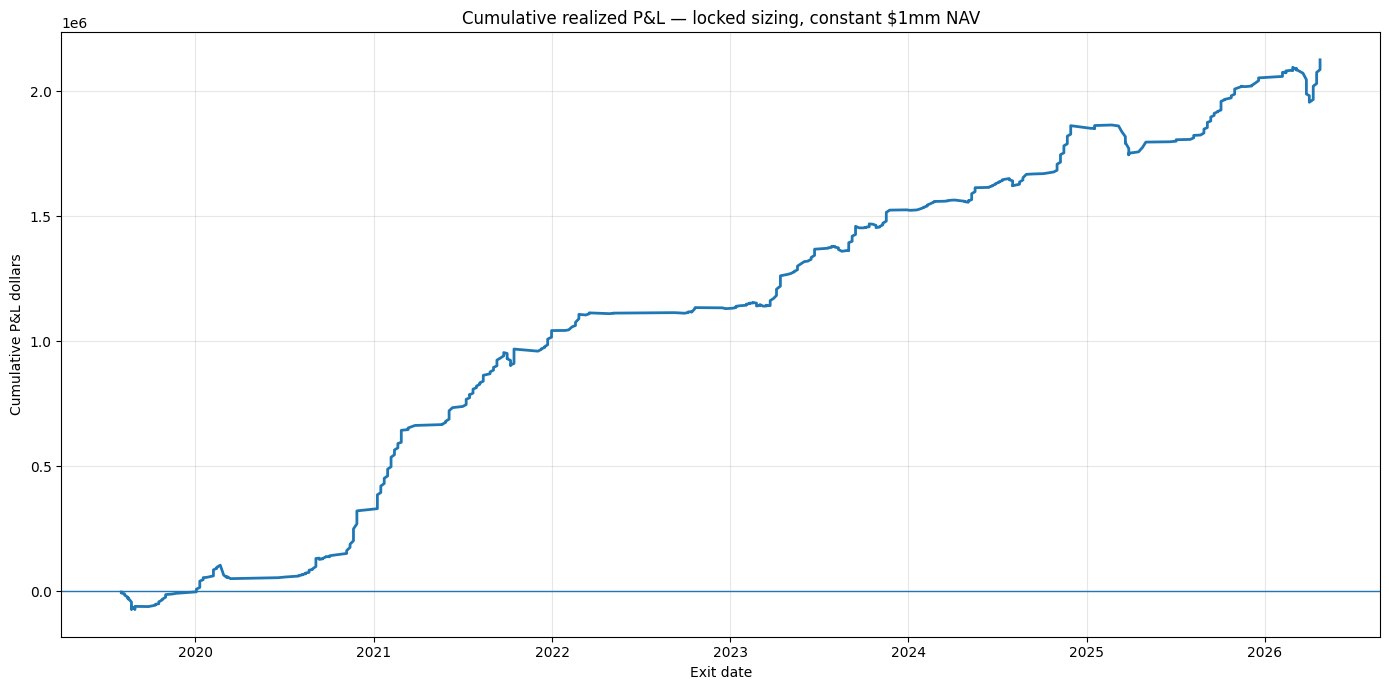


Saved outputs:
C:\Users\patri\vrp_project\data\audit\locked_2621_constant_1mm_nav_cumulative_pnl_realized_curve_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_constant_1mm_nav_cumulative_pnl_trade_level_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_constant_1mm_nav_cumulative_pnl_summary_v0_1.csv
C:\Users\patri\vrp_project\data\audit\locked_2621_constant_1mm_nav_cumulative_pnl_cumulative_pnl_v0_1.png

Plot cell complete.


In [29]:
# Final plot — cumulative P&L with constant $1mm sizing base
#
# Purpose:
#   Plot cumulative realized P&L over history using the locked per-trade sizing.
#
# Important:
#   This does NOT compound.
#   Every trade is sized as if NAV is always exactly $1,000,000.
#
# Locked per-trade sizing:
#   Core_back          5.00%
#   Core_middle        4.85%
#   Core_front         1.75%
#   Secondary_back     4.50%
#   Secondary_middle   3.25%
#   Secondary_front    1.75%

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------

CONSTANT_NAV = 1_000_000.0

if "UNIT_MAX_RISK_DOLLARS" not in globals():
    UNIT_MAX_RISK_DOLLARS = 100_000.0

LOCKED_FINAL_RISK_FRACTION_MAP = {
    "Core_back": 0.0500,
    "Core_middle": 0.0485,
    "Core_front": 0.0175,

    "Secondary_back": 0.0450,
    "Secondary_middle": 0.0325,
    "Secondary_front": 0.0175,
}

PLOT_LABEL = "locked_2621_constant_1mm_nav_cumulative_pnl"

print("Plot label:", PLOT_LABEL)
print("Constant NAV sizing base:", CONSTANT_NAV)
print("Unit max-risk dollars:", UNIT_MAX_RISK_DOLLARS)
print("Locked final risk map:")
print(LOCKED_FINAL_RISK_FRACTION_MAP)


# ---------------------------------------------------------------------
# Validate input
# ---------------------------------------------------------------------

if "sizing_trades" not in globals():
    raise ValueError("sizing_trades not found. Run the locked sizing cells first.")

plot_trades = sizing_trades.copy()
plot_trades = plot_trades.loc[:, ~plot_trades.columns.duplicated()].copy()

required_cols = [
    "date",
    "exit_date",
    "layer",
    "tenor_group",
    "selected_tenor",
    "actual_dte",
    "win",
    "normalized_pnl_dollars",
]

missing_cols = [c for c in required_cols if c not in plot_trades.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

plot_trades["date"] = pd.to_datetime(plot_trades["date"])
plot_trades["exit_date"] = pd.to_datetime(plot_trades["exit_date"])


# ---------------------------------------------------------------------
# Build final sizing group
# ---------------------------------------------------------------------

def get_final_sizing_group(row):
    layer = str(row["layer"])
    tenor_group = str(row["tenor_group"])

    return f"{layer}_{tenor_group}"


plot_trades["final_sizing_group"] = plot_trades.apply(get_final_sizing_group, axis=1)

unknown_groups = sorted(
    set(plot_trades["final_sizing_group"]) - set(LOCKED_FINAL_RISK_FRACTION_MAP.keys())
)

if unknown_groups:
    raise ValueError(f"Unexpected final_sizing_group values: {unknown_groups}")

plot_trades["final_risk_fraction"] = plot_trades["final_sizing_group"].map(
    LOCKED_FINAL_RISK_FRACTION_MAP
)

plot_trades["constant_nav_trade_max_risk_dollars"] = (
    CONSTANT_NAV * plot_trades["final_risk_fraction"]
)

plot_trades["constant_nav_unit_count"] = (
    plot_trades["constant_nav_trade_max_risk_dollars"] / UNIT_MAX_RISK_DOLLARS
)

plot_trades["constant_nav_sized_pnl_dollars"] = (
    plot_trades["constant_nav_unit_count"]
    * plot_trades["normalized_pnl_dollars"].astype(float)
)

plot_trades["constant_nav_return_on_nav"] = (
    plot_trades["constant_nav_sized_pnl_dollars"] / CONSTANT_NAV
)


# ---------------------------------------------------------------------
# Realized P&L curve by close / exit date
# ---------------------------------------------------------------------

realized_curve = (
    plot_trades
    .sort_values(["exit_date", "date", "selected_tenor"])
    .reset_index(drop=True)
    .copy()
)

realized_curve["trade_number"] = np.arange(1, len(realized_curve) + 1)
realized_curve["cumulative_pnl_dollars"] = realized_curve["constant_nav_sized_pnl_dollars"].cumsum()
realized_curve["cumulative_return_on_nav"] = realized_curve["cumulative_pnl_dollars"] / CONSTANT_NAV

realized_curve["running_peak_pnl"] = realized_curve["cumulative_pnl_dollars"].cummax()
realized_curve["drawdown_dollars"] = (
    realized_curve["cumulative_pnl_dollars"] - realized_curve["running_peak_pnl"]
)
realized_curve["drawdown_pct_of_nav"] = realized_curve["drawdown_dollars"] / CONSTANT_NAV

summary = {
    "trades": int(len(realized_curve)),
    "start_entry_date": plot_trades["date"].min(),
    "last_entry_date": plot_trades["date"].max(),
    "first_exit_date": realized_curve["exit_date"].min(),
    "last_exit_date": realized_curve["exit_date"].max(),

    "constant_nav": CONSTANT_NAV,

    "total_pnl_dollars": float(realized_curve["cumulative_pnl_dollars"].iloc[-1]),
    "total_return_on_constant_nav": float(realized_curve["cumulative_return_on_nav"].iloc[-1]),

    "win_rate": float((plot_trades["constant_nav_sized_pnl_dollars"] > 0).mean()),
    "avg_trade_pnl_dollars": float(plot_trades["constant_nav_sized_pnl_dollars"].mean()),
    "median_trade_pnl_dollars": float(plot_trades["constant_nav_sized_pnl_dollars"].median()),
    "worst_trade_pnl_dollars": float(plot_trades["constant_nav_sized_pnl_dollars"].min()),
    "best_trade_pnl_dollars": float(plot_trades["constant_nav_sized_pnl_dollars"].max()),

    "max_drawdown_dollars": float(realized_curve["drawdown_dollars"].min()),
    "max_drawdown_pct_of_nav": float(realized_curve["drawdown_pct_of_nav"].min()),

    "worst_20_trade_sum_dollars": float(
        realized_curve["constant_nav_sized_pnl_dollars"].rolling(20).sum().min()
    ),
}

summary_df = pd.DataFrame([summary])

print("\nConstant $1mm NAV summary:")
display(summary_df)


print("\nP&L by final sizing group:")
display(
    plot_trades
    .groupby("final_sizing_group", as_index=False)
    .agg(
        trades=("date", "count"),
        risk_fraction=("final_risk_fraction", "first"),
        total_max_risk_dollars=("constant_nav_trade_max_risk_dollars", "sum"),
        total_pnl_dollars=("constant_nav_sized_pnl_dollars", "sum"),
        avg_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "mean"),
        median_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "median"),
        win_rate=("constant_nav_sized_pnl_dollars", lambda x: float((x > 0).mean())),
        worst_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "min"),
        best_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "max"),
    )
    .sort_values("total_pnl_dollars", ascending=False)
)


print("\nP&L by year:")
display(
    plot_trades
    .assign(year=lambda x: x["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        trades=("date", "count"),
        total_pnl_dollars=("constant_nav_sized_pnl_dollars", "sum"),
        avg_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "mean"),
        win_rate=("constant_nav_sized_pnl_dollars", lambda x: float((x > 0).mean())),
        worst_trade_pnl_dollars=("constant_nav_sized_pnl_dollars", "min"),
    )
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    realized_curve["exit_date"],
    realized_curve["cumulative_pnl_dollars"],
    linewidth=2,
)

ax.axhline(0, linewidth=1)

ax.set_title("Cumulative realized P&L — locked sizing, constant $1mm NAV")
ax.set_xlabel("Exit date")
ax.set_ylabel("Cumulative P&L dollars")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Optional: save outputs
# ---------------------------------------------------------------------

if "AUDIT_DIR" not in globals():
    AUDIT_DIR = Path("data/audit")
else:
    AUDIT_DIR = Path(AUDIT_DIR)

AUDIT_DIR.mkdir(parents=True, exist_ok=True)

REALIZED_CURVE_PATH = AUDIT_DIR / f"{PLOT_LABEL}_realized_curve_v0_1.csv"
TRADE_LEVEL_PATH = AUDIT_DIR / f"{PLOT_LABEL}_trade_level_v0_1.csv"
SUMMARY_PATH = AUDIT_DIR / f"{PLOT_LABEL}_summary_v0_1.csv"
PNG_PATH = AUDIT_DIR / f"{PLOT_LABEL}_cumulative_pnl_v0_1.png"

realized_curve.to_csv(REALIZED_CURVE_PATH, index=False)
plot_trades.to_csv(TRADE_LEVEL_PATH, index=False)
summary_df.to_csv(SUMMARY_PATH, index=False)

fig.savefig(PNG_PATH, dpi=150, bbox_inches="tight")

print("\nSaved outputs:")
print(REALIZED_CURVE_PATH)
print(TRADE_LEVEL_PATH)
print(SUMMARY_PATH)
print(PNG_PATH)

print("\nPlot cell complete.")